# Проект №3: Непрерывное обучение для детектирования дефектов дорожного полотна

## Введение

В данном проекте вам предстоит разработать систему машинного зрения с элементами непрерывного обучения (Continual Learning) с помощью библиотеки Avalanche. Необходимо реализовать систему для детектирования дефектов дорожного полотна с помощью классификатора, детектора и семантической сегментационной модели.

## Материалы

### Датасеты:

•   [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html)
•   [Crowdsensing-based Road Damage Detection Challenge (CRDDC'2022)](https://ieee-dataport.org/competitions/crowdsensing-based-road-damage-detection-challenge-crddc2022)

### Архитектуры нейронных сетей:

•   Классификатор, с которым вы работали ранее в осеннем семестре:
    •   LeNet-5
    •   AlexNet

### Дополнительные ресурсы:

•   [Официальная документация Avalanche](https://avalanche.continualai.org/)
•   [GitHub репозиторий](https://github.com/ContinualAI/avalanche)
•   [Сообщество на Discord](https://discord.gg/6WpG2NjV6e)
•   [Официальный курс по CL](https://avalanche.continualai.org/course/)

## Задание №1

Необходимо создать систему непрерывного обучения, которая будет последовательно обучаться на подмножествах данных CIFAR-10, используя различные стратегии обучения и оценивая их эффективность.

In [ ]:
!pip install avalanche-lib

In [109]:
import os
import json
import random
import re
from glob import glob
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import SGD, Adam
from torch.nn import CrossEntropyLoss
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, transforms
from torchvision.datasets import CIFAR10
from torchvision.models import resnet18
from torchvision.utils import make_grid

from sklearn.metrics import confusion_matrix

import avalanche
from avalanche.benchmarks.classic import SplitMNIST, PermutedMNIST, SplitCIFAR10
from avalanche.models import SimpleMLP, SimpleCNN
from avalanche.training.supervised import Naive, Cumulative, EWC
from avalanche.training.plugins import EvaluationPlugin
from avalanche.logging import InteractiveLogger, TextLogger
from avalanche.evaluation.metrics import (
    accuracy_metrics, loss_metrics, forgetting_metrics, timing_metrics,
    confusion_matrix_metrics, cpu_usage_metrics
)

import xml.etree.ElementTree as ET

from tabulate import tabulate

In [110]:
print(avalanche.__version__)

0.6.0


In [111]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# EDA

In [236]:
sns.set(style='whitegrid')
device = 'cuda' if torch.cuda.is_available() else 'cpu'

## CIFAR10

In [237]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

In [238]:
transform = transforms.ToTensor()
trainset = CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

100%|██████████| 170M/170M [00:13<00:00, 12.3MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


In [239]:
print(f"Размер обучающей выборки: {len(trainset)}")
print(f"Размер тестовой выборки: {len(testset)}")
print("Форма одного изображения:", trainset[0][0].shape)  # (C, H, W)

Размер обучающей выборки: 50000
Размер тестовой выборки: 10000
Форма одного изображения: torch.Size([3, 32, 32])


### Примеры изображений

In [240]:
def plot_one_per_class(dataset, class_names, n_classes=10):
    shown = set()
    images = []
    labels = []

    for img, label in dataset:
        if label not in shown:
            images.append(img)
            labels.append(label)
            shown.add(label)
        if len(shown) == n_classes:
            break

    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    axes = axes.flatten()
    for i in range(n_classes):
        img = images[i].permute(1, 2, 0).numpy()
        axes[i].imshow(img)
        axes[i].set_title(class_names[labels[i]], fontsize=10)
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

Files already downloaded and verified


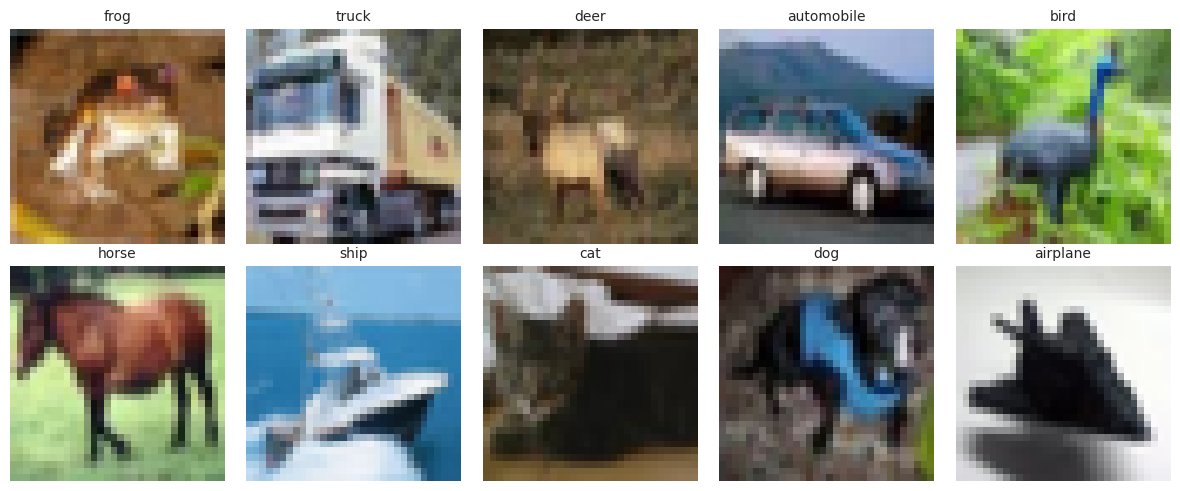

In [241]:
transform = transforms.ToTensor()
cifar_train = CIFAR10(root='./data', train=True, download=True, transform=transform)
class_names = cifar_train.classes

plot_one_per_class(cifar_train, class_names)

### Распределение классов

In [ ]:
train_labels = [label for _, label in trainset]
class_counts = Counter(train_labels)
class_names = [classes[i] for i in class_counts.keys()]
class_values = list(class_counts.values())

<ipython-input-33-fc2b2760f4c3>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=class_names, y=class_values, palette='viridis')


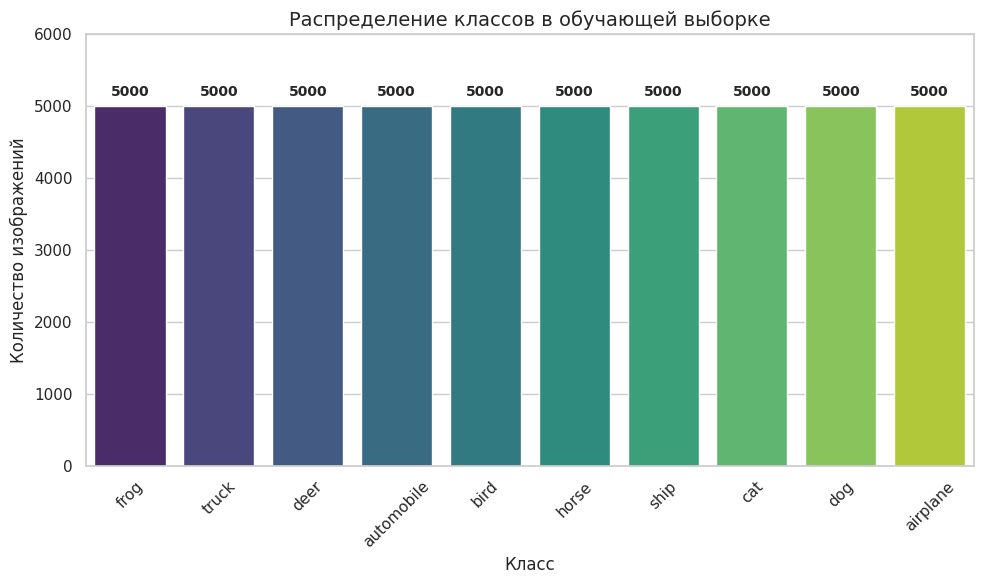

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=class_names, y=class_values, palette='viridis')

for i, val in enumerate(class_values):
    ax.text(i, val + 100, str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title("Распределение классов в обучающей выборке", fontsize=14)
plt.ylabel("Количество изображений", fontsize=12)
plt.xlabel("Класс", fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, max(class_values) + 1000)

plt.tight_layout()
plt.show()

Классы сбалансированы, все по ~5000 изображений.
Значит не нужен взыешенный семплер или другие подходы балансировки при обучении.


### Средние и стандартные отклонения по каналам

In [ ]:
def get_mean_std(dataset):
    loader = torch.utils.data.DataLoader(dataset, batch_size=5000, shuffle=False)
    mean = 0.
    std = 0.
    for images, _ in loader:
        batch_samples = images.size(0)
        images = images.view(batch_samples, images.size(1), -1)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)

    mean /= len(dataset)
    std /= len(dataset)
    return mean, std

mean, std = get_mean_std(trainset)
print("Средние значения по каналам:", mean)
print("Стандартные отклонения:", std)

Средние значения по каналам: tensor([0.4914, 0.4822, 0.4465])
Стандартные отклонения: tensor([0.2023, 0.1994, 0.2010])


###  Гистограммы значений пикселей

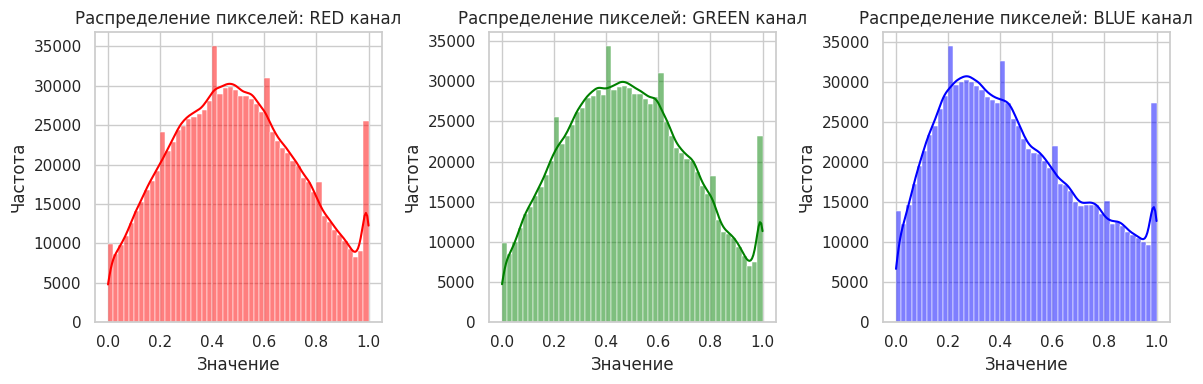

In [ ]:
def plot_pixel_distribution(dataset, num_images=1000):
    loader = torch.utils.data.DataLoader(dataset, batch_size=num_images, shuffle=False)
    images, _ = next(iter(loader))
    images = images.view(images.shape[0], 3, -1)

    colors = ['red', 'green', 'blue']
    plt.figure(figsize=(12, 4))
    for i, color in enumerate(colors):
        plt.subplot(1, 3, i+1)
        sns.histplot(images[:, i, :].flatten().numpy(), bins=50, kde=True, color=color)
        plt.title(f"Распределение пикселей: {color.upper()} канал")
        plt.xlabel("Значение")
        plt.ylabel("Частота")
    plt.tight_layout()
    plt.show()

plot_pixel_distribution(trainset)

Каждый канал имеет колоколообразное распределение, чуть смещённое влево (т.е. преобладают тёмные пиксели). В целом это ожидаемо


## Permuted MNIST

Генерируем перестановку

In [ ]:
perm = torch.randperm(28 * 28)

In [ ]:
def permute_image(img):
    img = img.view(-1)[perm]
    return img.view(1, 28, 28)

In [ ]:
permute_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(permute_image)
])

In [ ]:
original_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
pmnist_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=permute_transform)

### Примеры изображений

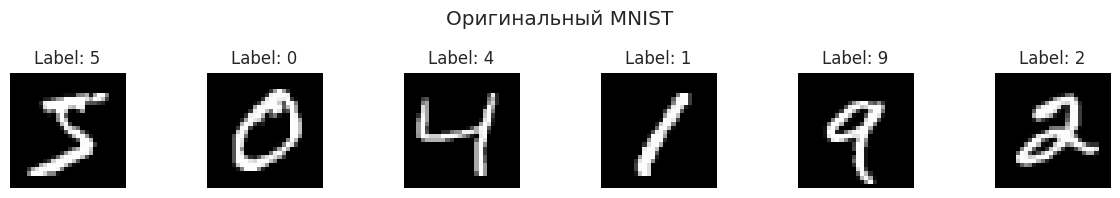

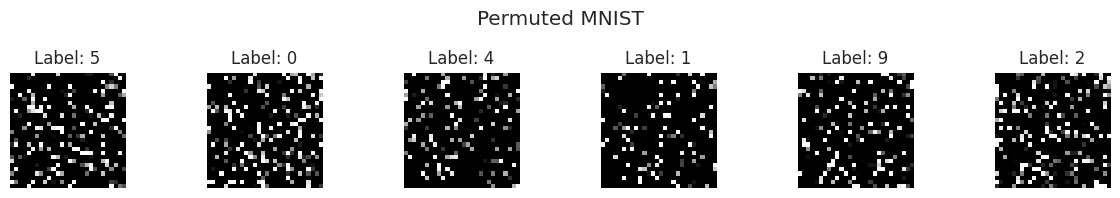

In [ ]:
def show_samples(dataset, title, n=6):
    plt.figure(figsize=(12, 2))
    for i in range(n):
        img, label = dataset[i]
        plt.subplot(1, n, i+1)
        plt.imshow(img.squeeze(), cmap='gray')
        plt.title(f"Label: {label}")
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_samples(original_dataset, "Оригинальный MNIST")
show_samples(pmnist_dataset, "Permuted MNIST")

 Перестановка пикселей ломает spatial structure — цифры становятся неузнаваемыми - как раз протестируем наши подходы на устойчивость

### Распределение классов

In [ ]:
labels = [label for _, label in pmnist_dataset]

<ipython-input-42-fdf49dd1a824>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=labels, palette="Set2")


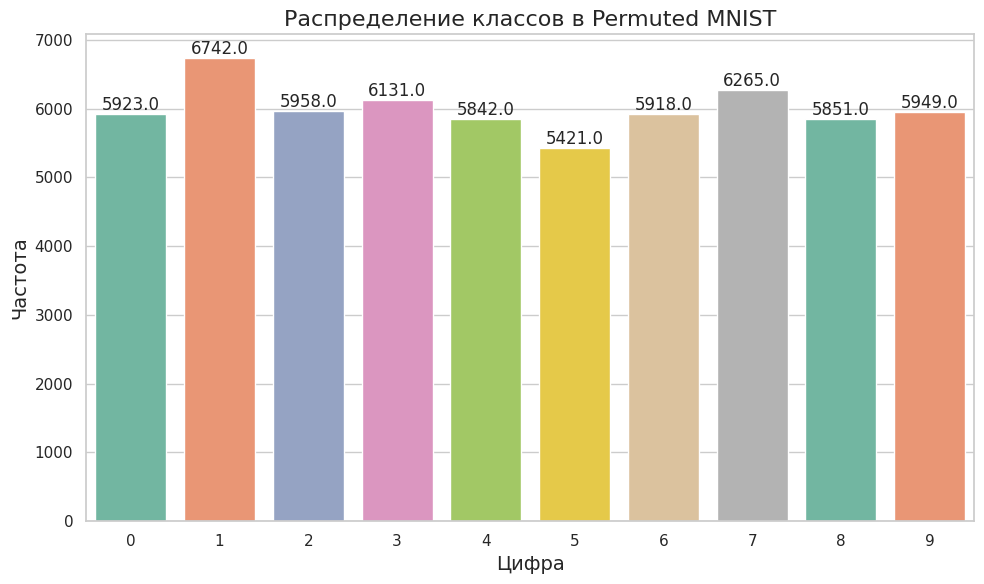

In [ ]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(x=labels, palette="Set2")
plt.title("Распределение классов в Permuted MNIST", fontsize=16)
plt.xlabel("Цифра", fontsize=14)
plt.ylabel("Частота", fontsize=14)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

Распределение довольно равномерное (как и в обычном MNIST)
Значит, модель не будет сталкиваться с классовым дисбалансом даже после перемешивания

### Анализ перестановки

In [ ]:
original_img = original_dataset[0][0].view(-1).numpy()
permuted_img = pmnist_dataset[0][0].view(-1).numpy()

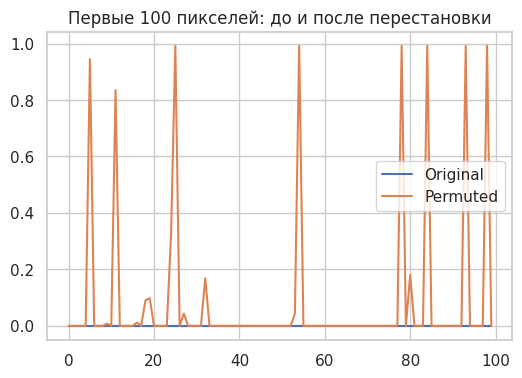

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(original_img[:100], label="Original")
plt.plot(permuted_img[:100], label="Permuted")
plt.legend()
plt.title("Первые 100 пикселей: до и после перестановки")
plt.show()

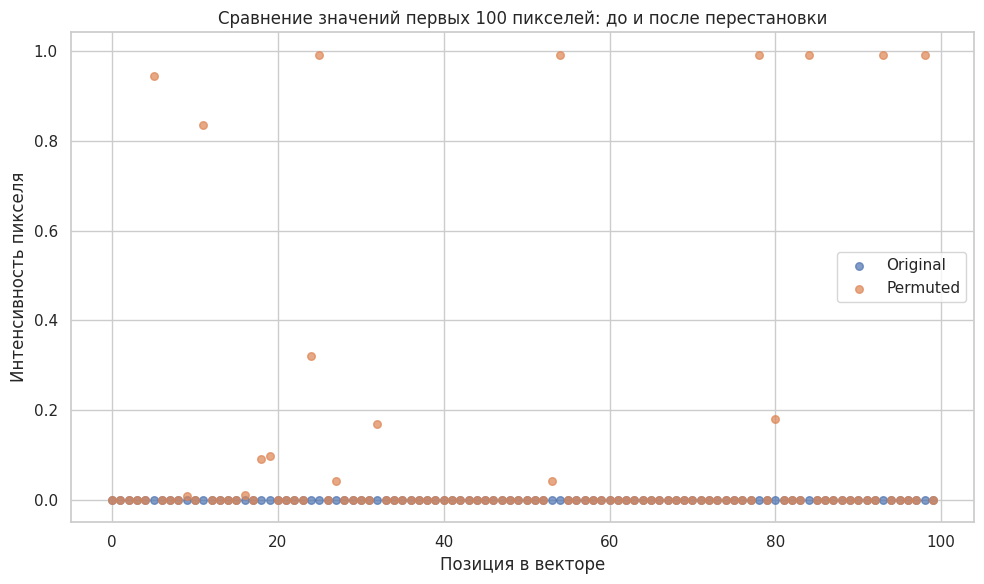

In [ ]:
orig = original_dataset[0][0].view(-1).numpy()
perm = pmnist_dataset[0][0].view(-1).numpy()

plt.figure(figsize=(10, 6))
plt.scatter(range(100), orig[:100], label="Original", alpha=0.7, s=30)
plt.scatter(range(100), perm[:100], label="Permuted", alpha=0.7, s=30)
plt.title("Сравнение значений первых 100 пикселей: до и после перестановки")
plt.xlabel("Позиция в векторе")
plt.ylabel("Интенсивность пикселя")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Видим, как нарушена пространственная когерентность — форма разрушена.

### Распределения интенсивностей пикселей

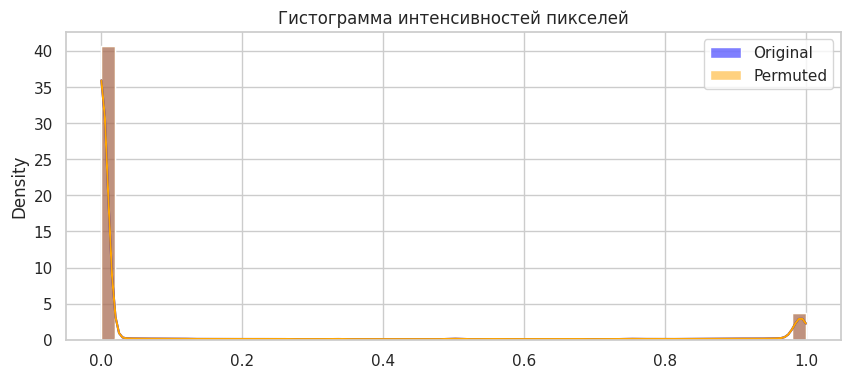

In [ ]:
orig_pixels = torch.cat([img.view(-1) for img, _ in original_dataset], dim=0)
perm_pixels = torch.cat([img.view(-1) for img, _ in pmnist_dataset], dim=0)

plt.figure(figsize=(10, 4))
sns.histplot(orig_pixels.numpy(), bins=50, label="Original", color="blue", stat="density", kde=True)
sns.histplot(perm_pixels.numpy(), bins=50, label="Permuted", color="orange", stat="density", kde=True)
plt.title("Гистограмма интенсивностей пикселей")
plt.legend()
plt.show()

Почти совпадают! (ожидаемо: значения пикселей те же, просто  порядок изменён)

Гистограмма осталась прежней, но spatial-паттерны уничтожены — значит, модель должна адаптироваться к новым признакам


Experience 0 классы: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


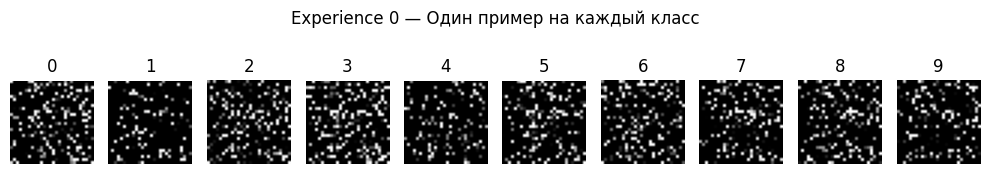

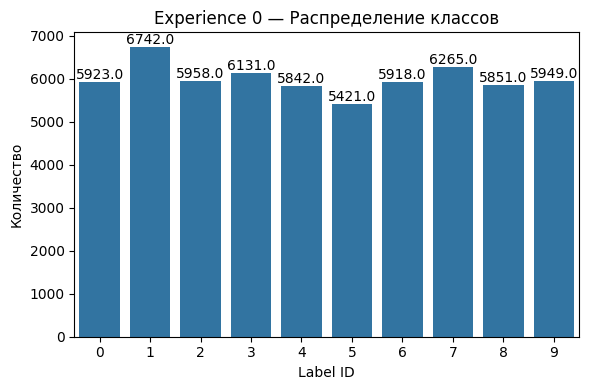


Experience 1 классы: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


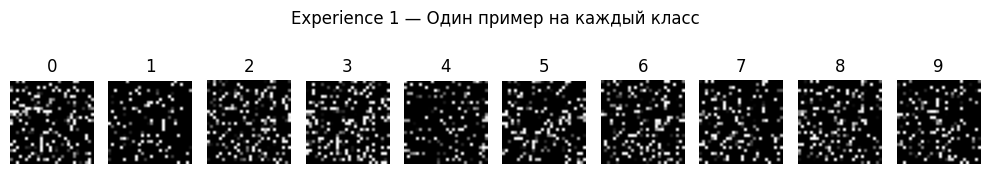

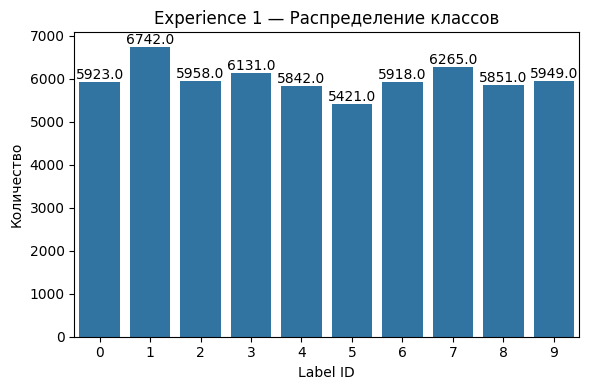


Experience 2 классы: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


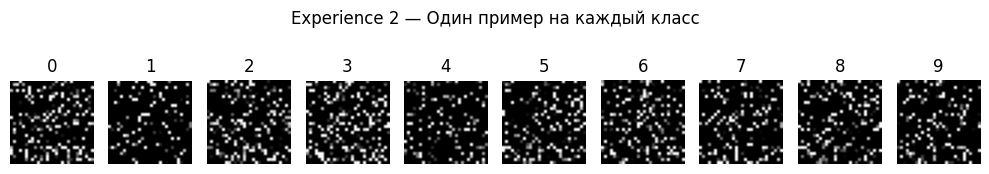

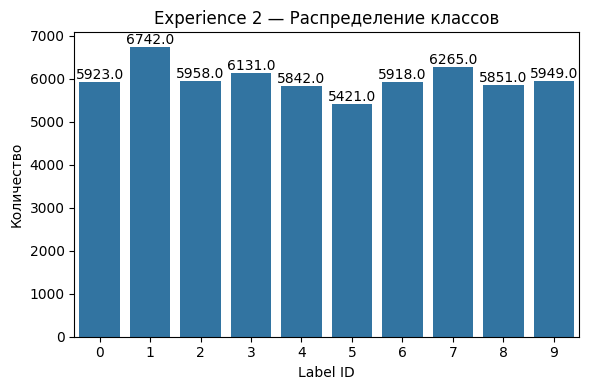

In [18]:
benchmark = PermutedMNIST(n_experiences=3)

for exp_id, exp in enumerate(benchmark.train_stream):
    dataset = exp.dataset
    labels = [int(label) for _, label, *_ in dataset]
    label_count = Counter(labels)
    class_labels = sorted(label_count.keys())

    print(f"\nExperience {exp_id} классы: {class_labels}")

    plt.figure(figsize=(10, 2))
    shown = set()
    count = 0
    for i in range(len(dataset)):
        img, label, *_ = dataset[i]
        if label not in shown:
            plt.subplot(1, len(class_labels), count + 1)
            plt.imshow(img.squeeze(), cmap="gray")
            plt.title(f"{label}")
            plt.axis("off")
            shown.add(label)
            count += 1
        if count == len(class_labels):
            break
    plt.suptitle(f"Experience {exp_id} — Один пример на каждый класс")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    ax = sns.countplot(x=labels)
    for p in ax.patches:
        h = p.get_height()
        ax.annotate(f'{h}', (p.get_x() + p.get_width() / 2., h),
                    ha='center', va='bottom', fontsize=10)
    plt.title(f"Experience {exp_id} — Распределение классов")
    plt.xlabel("Label ID")
    plt.ylabel("Количество")
    plt.tight_layout()
    plt.show()

## SplitMNIST (дополнительно)


Experience 0 классы: ['2', '7']


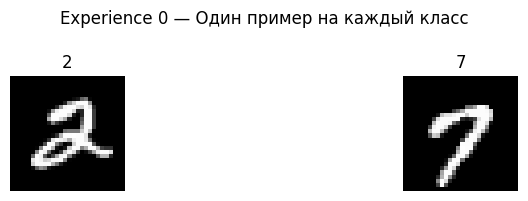

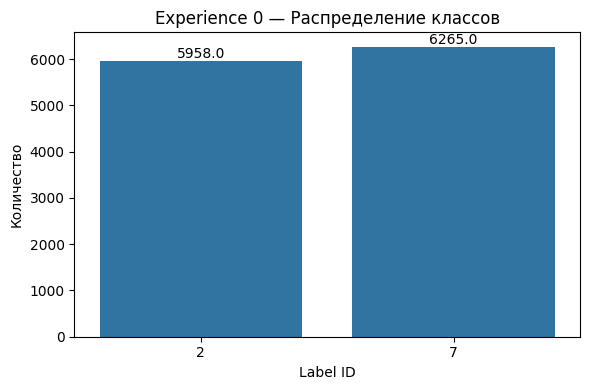


Experience 1 классы: ['8', '3']


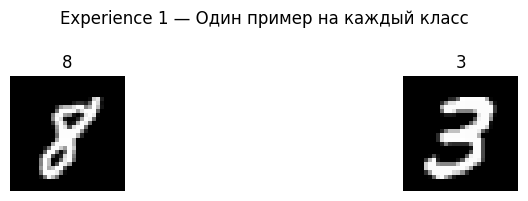

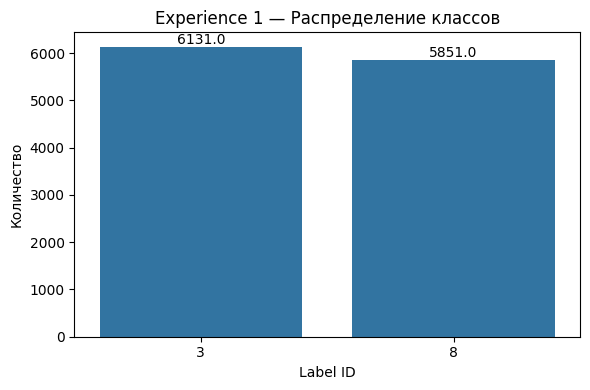


Experience 2 классы: ['0', '9']


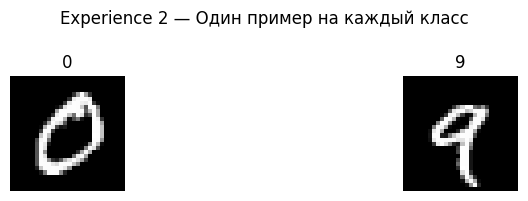

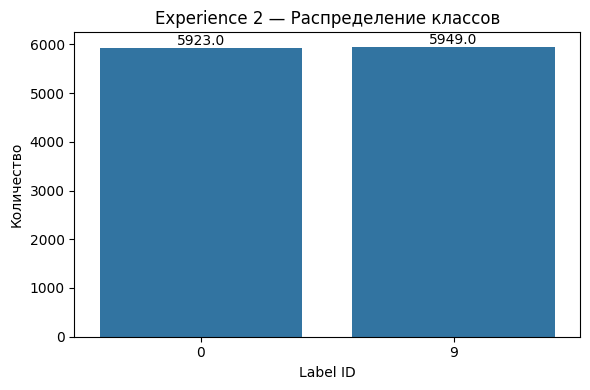


Experience 3 классы: ['4', '6']


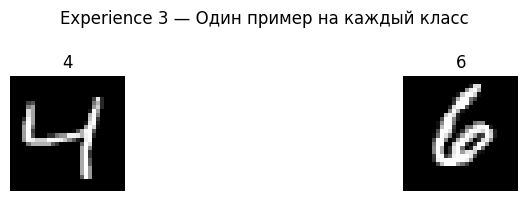

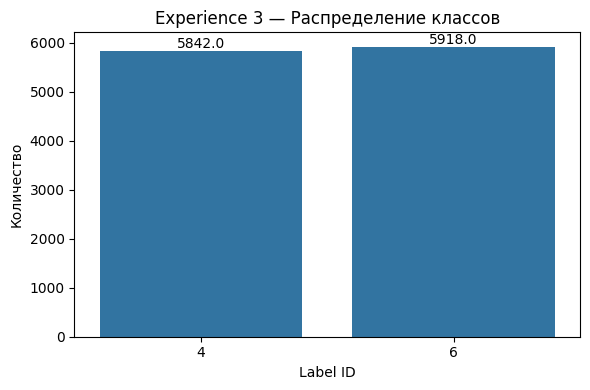


Experience 4 классы: ['1', '5']


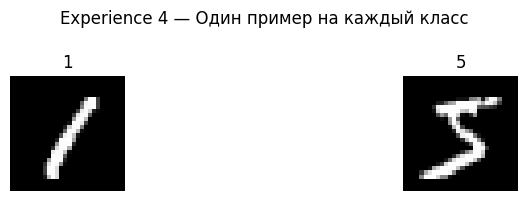

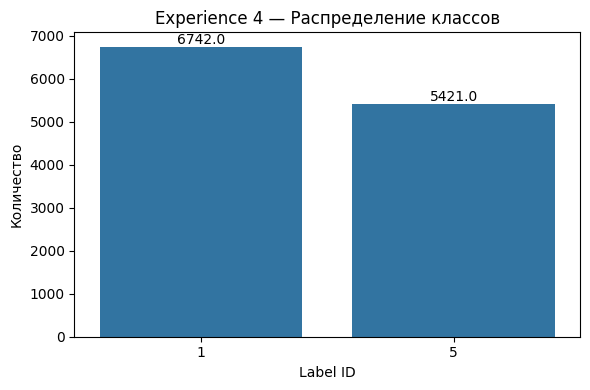

In [17]:
benchmark = SplitMNIST(n_experiences=5)
class_names = [str(i) for i in range(10)]

for exp_id, exp in enumerate(benchmark.train_stream):
    dataset = exp.dataset
    y = [int(x[1]) for x in dataset]
    label_count = Counter(y)
    class_labels = list(label_count.keys())
    class_names_exp = [class_names[i] for i in class_labels]

    print(f"\nExperience {exp_id} классы: {class_names_exp}")

    plt.figure(figsize=(10, 2))
    shown_labels = set()
    count = 0
    for i in range(len(dataset)):
        x = dataset[i]
        img, label = x[:2]
        if label not in shown_labels:
            plt.subplot(1, len(class_labels), count + 1)
            plt.imshow(img.squeeze(), cmap='gray')
            plt.title(f"{label}")
            plt.axis('off')
            shown_labels.add(label)
            count += 1
        if count == len(class_labels):
            break
    plt.suptitle(f"Experience {exp_id} — Один пример на каждый класс")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    ax = sns.countplot(x=y)
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10)
    plt.title(f"Experience {exp_id} — Распределение классов")
    plt.xlabel("Label ID")
    plt.ylabel("Количество")
    plt.tight_layout()
    plt.show()

#CRDD

In [ ]:
class ClassificationDataSet:
    def __init__(self, ds_path):
        self.dataset_path = ds_path
        self.data = []
        ann_dir = os.path.join(self.dataset_path, "annotations/xmls")
        for xml_file in os.listdir(ann_dir):
            tree = ET.parse(os.path.join(ann_dir, xml_file))
            root = tree.getroot()

            for obj in root.findall('object'):
                label = obj.find('name').text
                bndbox = obj.find('bndbox')
                xmin = int(bndbox.find('xmin').text)
                ymin = int(bndbox.find('ymin').text)
                xmax = int(bndbox.find('xmax').text)
                ymax = int(bndbox.find('ymax').text)

                self.data.append((xml_file, (xmin, ymin, xmax, ymax), label))

    def __getitem__(self, idx):
        img_dir = os.path.join(self.dataset_path, "images")
        xml_file, (xmin, ymin, xmax, ymax), label = self.data[idx]
        file_name = xml_file.replace(".xml", ".jpg")
        img_path = Path(img_dir) / file_name
        image = cv2.imread(str(img_path))
        if image is None:
            return None, label
        return image[ymin:ymax, xmin:xmax], label

    def __len__(self):
        return len(self.data)

In [ ]:
current_directory = os.getcwd()
print(f"Текущая рабочая директория: {current_directory}")

Текущая рабочая директория: /content


In [15]:
start_path = "/content/drive/MyDrive"

In [ ]:
ds_china = ClassificationDataSet(start_path+"/Colab Notebooks/Task1/China_MotorBike/train")

### China_MotorBike

#### Распределение классов

In [ ]:
labels = [label for _, _, label in ds_china.data]
label_counts = Counter(labels)

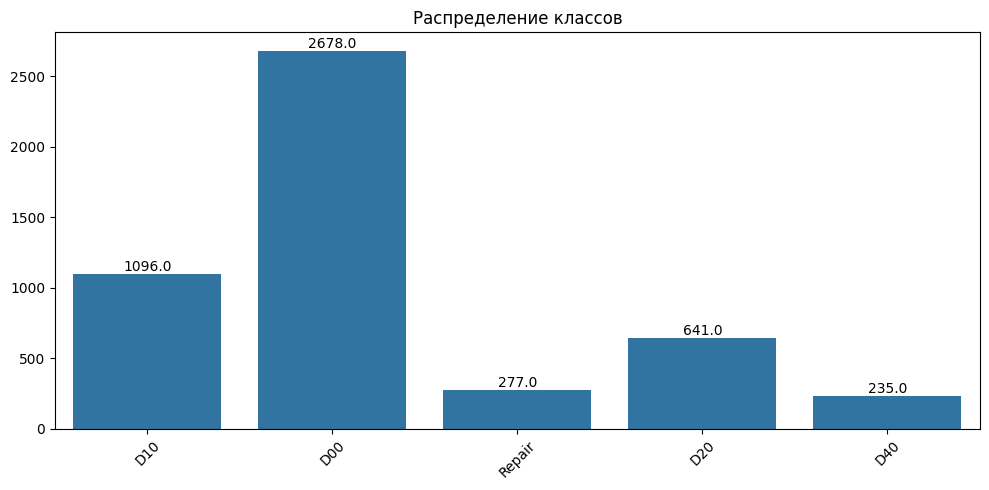

In [ ]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=list(label_counts.keys()), y=list(label_counts.values()))
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width()/2, height), ha='center', va='bottom')
plt.title("Распределение классов")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Наблюдается дисбаланс — например, классы типа D00 встречаются в разы чаще, чем D40 и др.
Значит нужно будет учесть это или использовать методы балансировки.

#### Примеры изображений по 1 на каждый класс

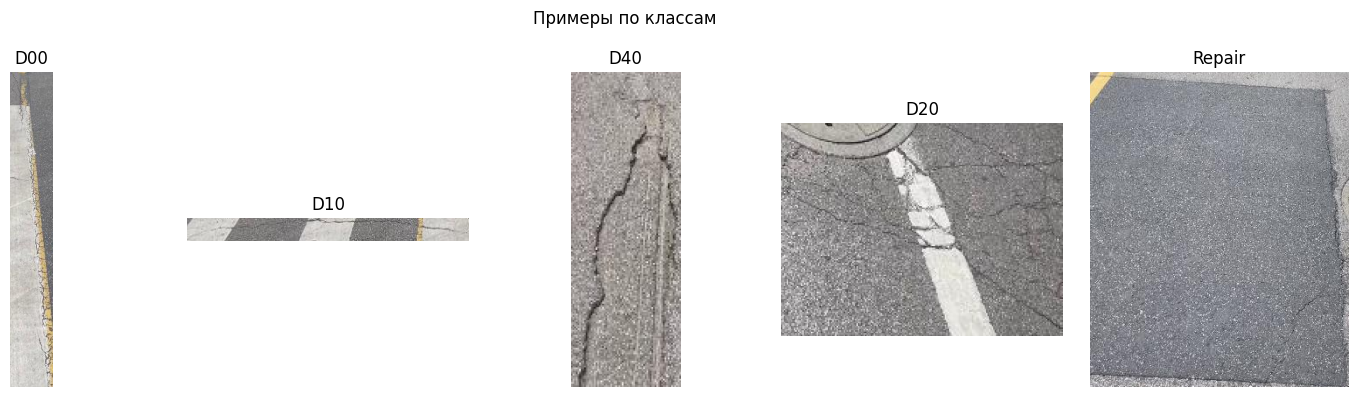

In [ ]:
shown = set()
plt.figure(figsize=(15, 4))
i = 1
for img, label in ds_china:
    if img is None or label in shown:
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, len(label_counts), i)
    plt.imshow(img_rgb)
    plt.title(label)
    plt.axis('off')
    shown.add(label)
    i += 1
    if len(shown) == len(label_counts): break
plt.suptitle("Примеры по классам")
plt.tight_layout()
plt.show()

#### Размеры боксов

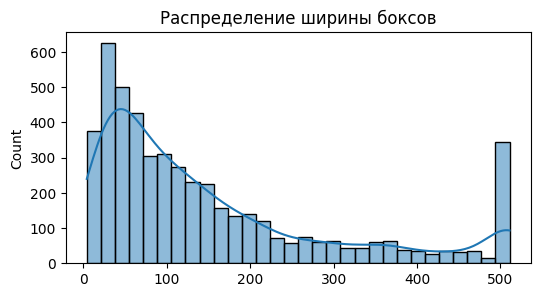

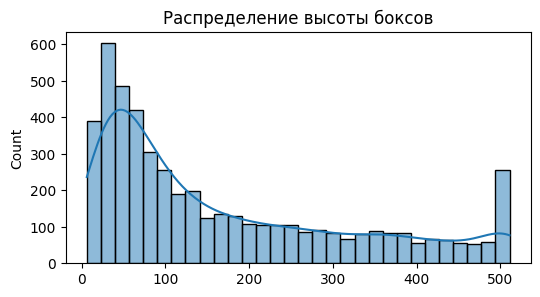

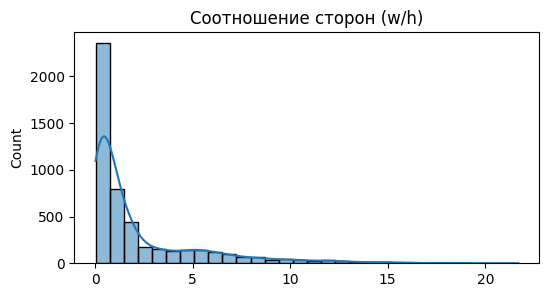

In [ ]:
widths = []
heights = []
ratios = []
for _, (xmin, ymin, xmax, ymax), _ in ds_china.data:
    w = xmax - xmin
    h = ymax - ymin
    widths.append(w)
    heights.append(h)
    ratios.append(w / h)

plt.figure(figsize=(6, 3))
sns.histplot(widths, bins=30, kde=True)
plt.title("Распределение ширины боксов")
plt.show()

plt.figure(figsize=(6, 3))
sns.histplot(heights, bins=30, kde=True)
plt.title("Распределение высоты боксов")
plt.show()

plt.figure(figsize=(6, 3))
sns.histplot(ratios, bins=30, kde=True)
plt.title("Соотношение сторон (w/h)")
plt.show()

Соотношение сторон (w/h): можно видеть, например, что большинство объектов вытянуты в ширину

#### Цветовая гистограмма

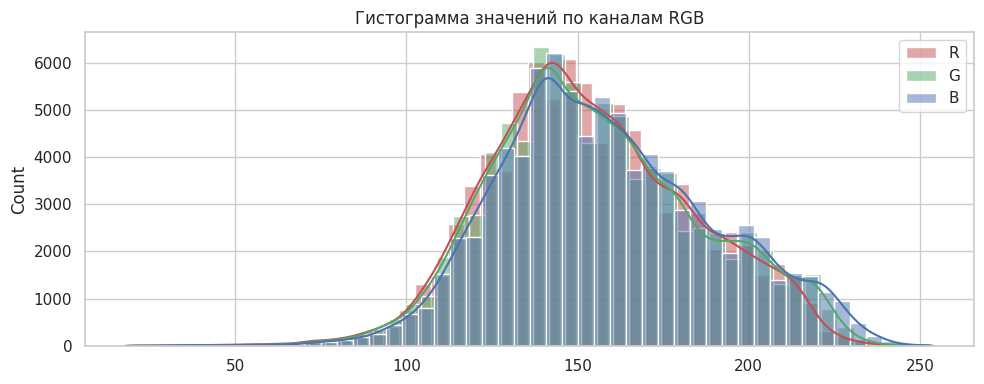

In [ ]:
indices = random.sample(range(len(ds_china)), k=100)

sample_imgs = []
for idx in indices:
    img, _ = ds_china[idx]
    if img is not None:
        resized = cv2.resize(img, (32, 32))
        sample_imgs.append(resized)

pixels = np.concatenate([img.reshape(-1, 3) for img in sample_imgs], axis=0)

plt.figure(figsize=(10, 4))
for i, color in enumerate(['r', 'g', 'b']):
    sns.histplot(pixels[:, i], bins=50, kde=True, color=color, label=color.upper())
plt.title("Гистограмма значений по каналам RGB")
plt.legend()
plt.tight_layout()
plt.show()

Почти нормальные распределения с доминированием тёмных цветов.
Много асфальта, тени, и мало насыщенных цветов.
Можем использовать это при предобработке (яркость/контраст).


### Japan

In [ ]:

ds_japan = ClassificationDataSet(start_path+"/Colab Notebooks/Task1/Japan/train")

#### Распределение классов

In [ ]:
labels = [label for _, _, label in ds_japan.data]
label_counts = Counter(labels)

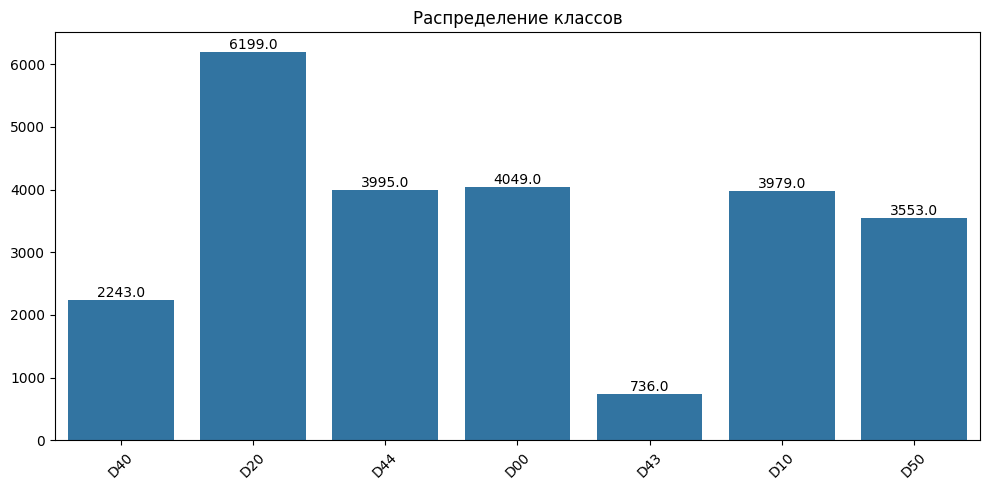

In [ ]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=list(label_counts.keys()), y=list(label_counts.values()))
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width()/2, height), ha='center', va='bottom')
plt.title("Распределение классов")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Опять видим дисбаланс: класс типа D20 встречается значительно чаще, D43, D40 могут быть в десятки раз реже.
Нужна БАЛАНСИРОВКА!

#### Примеры изображений по 1 на каждый класс

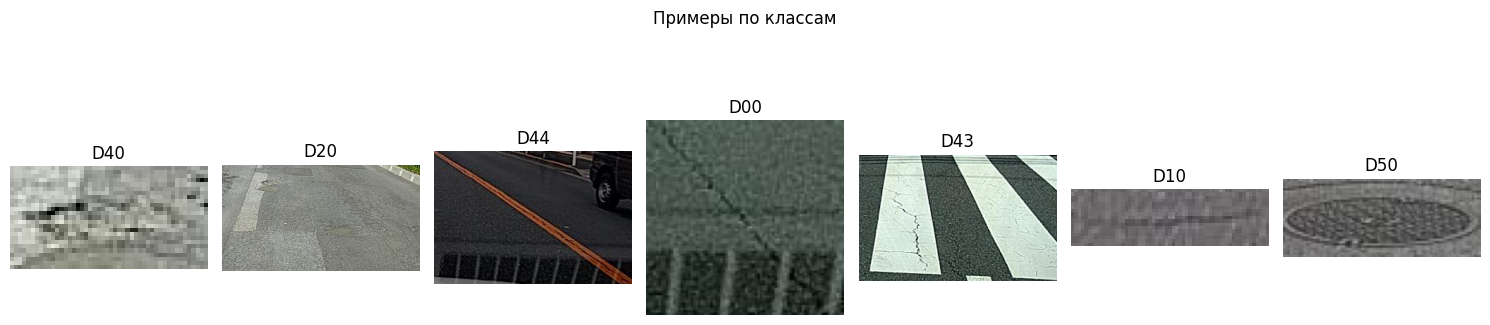

In [ ]:
shown = set()
plt.figure(figsize=(15, 4))
i = 1
for img, label in ds_japan:
    if img is None or label in shown:
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, len(label_counts), i)
    plt.imshow(img_rgb)
    plt.title(label)
    plt.axis('off')
    shown.add(label)
    i += 1
    if len(shown) == len(label_counts): break
plt.suptitle("Примеры по классам")
plt.tight_layout()
plt.show()

Некоторые классы визуально очень похожи (D00 vs D10)
Может быть высокая межклассовая путаница


#### Размеры боксов

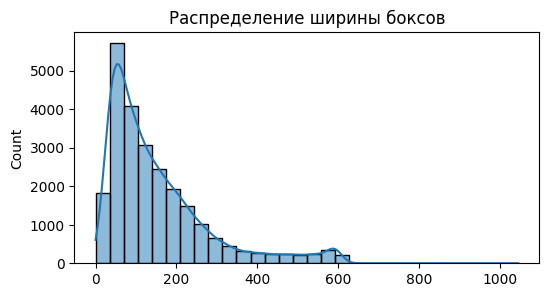

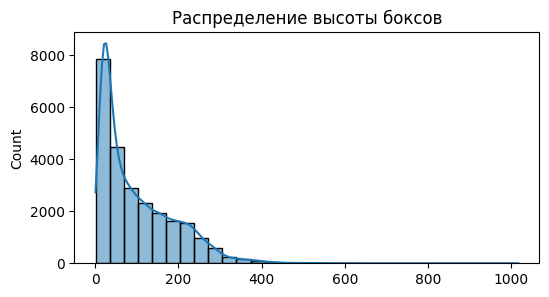

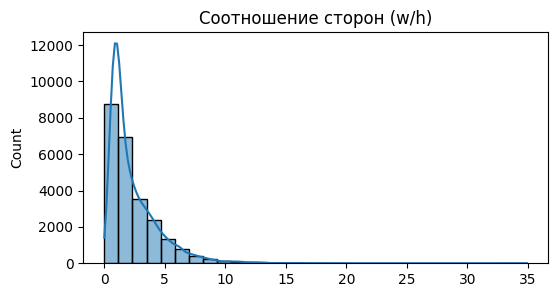

In [ ]:
widths = []
heights = []
ratios = []
for _, (xmin, ymin, xmax, ymax), _ in ds_japan.data:
    w = xmax - xmin
    h = ymax - ymin
    widths.append(w)
    heights.append(h)
    ratios.append(w / h)

plt.figure(figsize=(6, 3))
sns.histplot(widths, bins=30, kde=True)
plt.title("Распределение ширины боксов")
plt.show()

plt.figure(figsize=(6, 3))
sns.histplot(heights, bins=30, kde=True)
plt.title("Распределение высоты боксов")
plt.show()

plt.figure(figsize=(6, 3))
sns.histplot(ratios, bins=30, kde=True)
plt.title("Соотношение сторон (w/h)")
plt.show()

#### Цветовая гистограмма

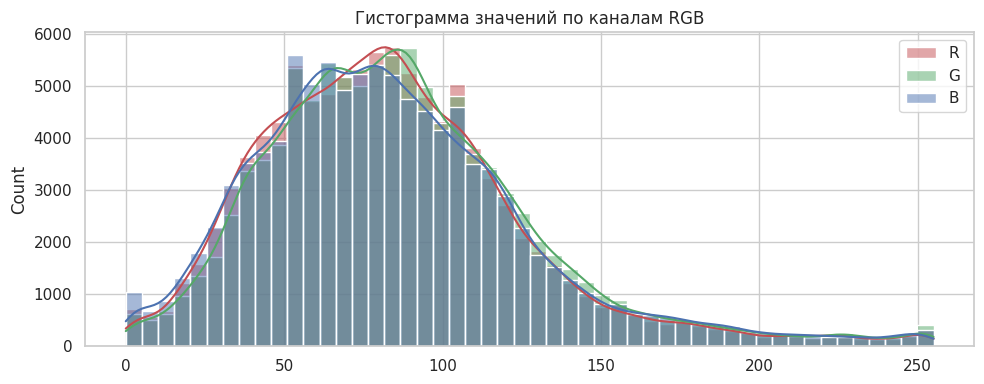

In [ ]:
indices = random.sample(range(len(ds_japan)), k=100)

sample_imgs = []
for idx in indices:
    img, _ = ds_japan[idx]
    if img is not None:
        resized = cv2.resize(img, (32, 32))
        sample_imgs.append(resized)

pixels = np.concatenate([img.reshape(-1, 3) for img in sample_imgs], axis=0)

plt.figure(figsize=(10, 4))
for i, color in enumerate(['r', 'g', 'b']):
    sns.histplot(pixels[:, i], bins=50, kde=True, color=color, label=color.upper())
plt.title("Гистограмма значений по каналам RGB")
plt.legend()
plt.tight_layout()
plt.show()

### SplitCIFAR10

In [ ]:
benchmark = SplitCIFAR10(n_experiences=5, return_task_id=True)


class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

100%|██████████| 170M/170M [00:01<00:00, 102MB/s]


In [ ]:
def denormalize(tensor, mean, std):
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor


Experience 0 классы: ['automobile', 'frog']


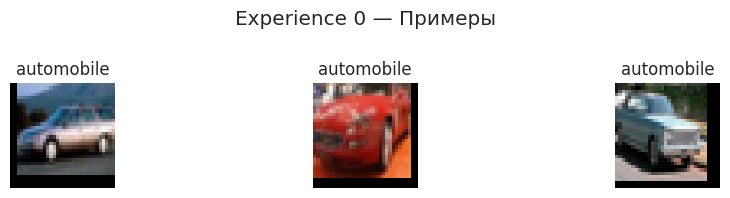

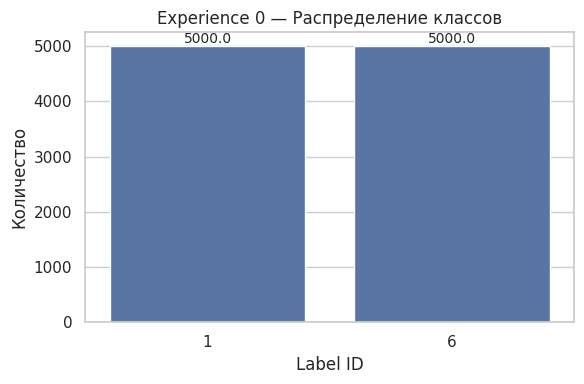


Experience 1 классы: ['ship', 'airplane']


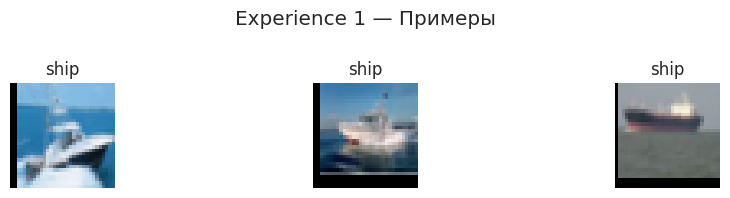

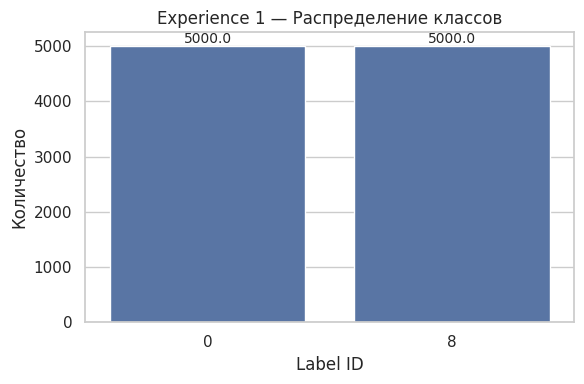


Experience 2 классы: ['deer', 'dog']


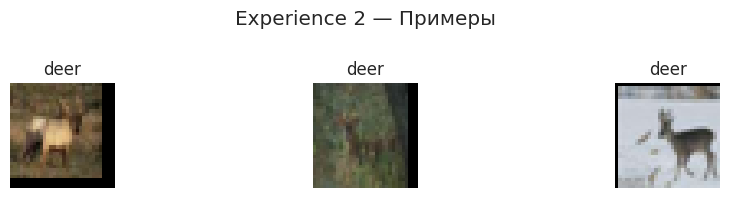

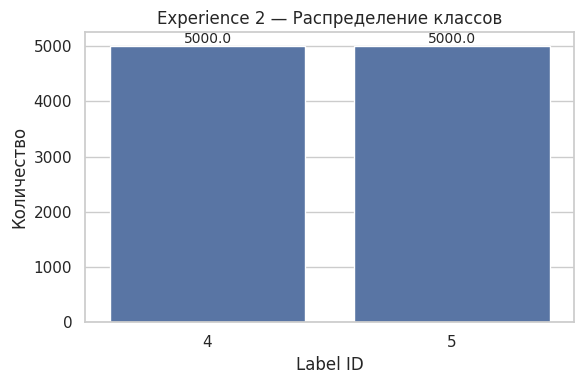


Experience 3 классы: ['cat', 'horse']


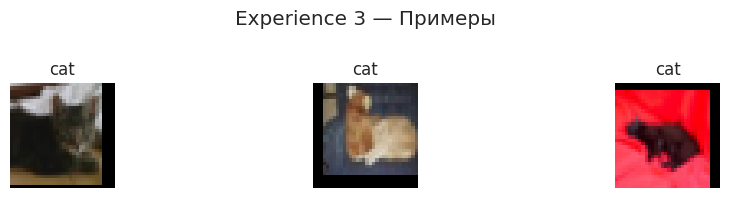

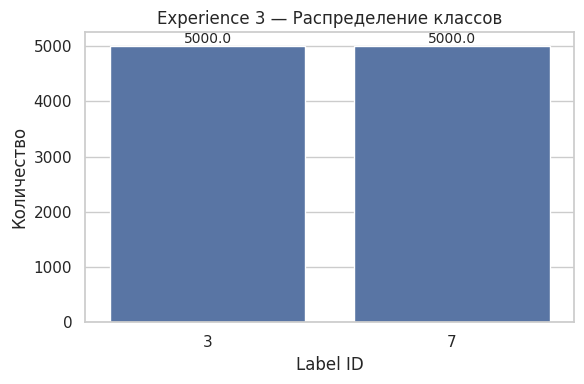


Experience 4 классы: ['truck', 'bird']


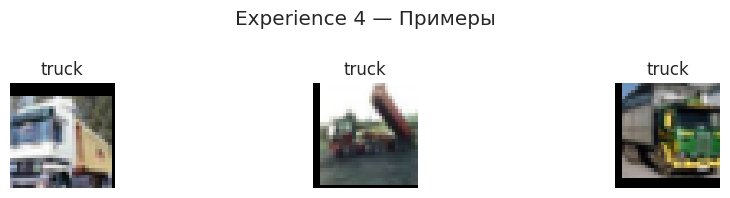

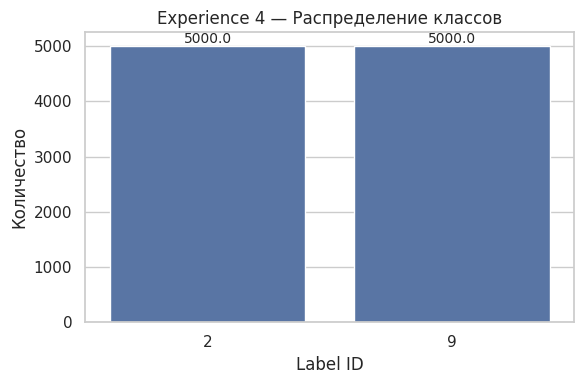

In [ ]:
for exp_id, exp in enumerate(benchmark.train_stream):
    dataset = exp.dataset
    y = [int(label) for _, label, *_ in dataset]
    label_count = Counter(y)
    class_labels = list(label_count.keys())
    class_names_exp = [class_names[i] for i in class_labels]


    print(f"\nExperience {exp_id} классы: {class_names_exp}")

    plt.figure(figsize=(10, 2))
    count = 0
    for i in range(len(dataset)):
        img, label, *_ = dataset[i]
        if sum([label == x for x in class_labels]) and count < 3:
            plt.subplot(1, 3, count + 1)
            img = denormalize(img.clone(), [0.4914, 0.4822, 0.4465], [0.2023, 0.1994, 0.2010])
            img = torch.clamp(img, 0, 1)
            plt.imshow(img.permute(1, 2, 0).numpy())
            plt.imshow(img.permute(1, 2, 0).numpy())
            plt.title(f"{class_names[label]}")
            plt.axis('off')
            count += 1
        if count == 3:
            break
    plt.suptitle(f"Experience {exp_id} — Примеры")
    plt.tight_layout()
    plt.show()


    plt.figure(figsize=(6, 4))
    ax = sns.countplot(x=y)
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10)
    plt.title(f"Experience {exp_id} — Распределение классов")
    plt.xlabel("Label ID")
    plt.ylabel("Количество")
    plt.tight_layout()
    plt.show()

# Обучение

# Структурированный пайплайн

In [6]:
start_path = "/content/drive/MyDrive"
base_dir = start_path+"/Colab Notebooks/Task3/results"

In [7]:
strategies = ["naive", "ewc", "cumulative"]
train_epochs = 5

In [8]:
model_tasks = {
    "lenet_splitcifar10": SplitCIFAR10(n_experiences=5, return_task_id=True),
    "lenet_pmnist": PermutedMNIST(n_experiences=3),
    "simplecnn_pmnist": PermutedMNIST(n_experiences=3),
    "resnet_splitcifar10": SplitCIFAR10(n_experiences=5, return_task_id=True),
}
for name in model_tasks:
    os.makedirs(os.path.join(base_dir, name), exist_ok=True)

100%|██████████| 170M/170M [00:18<00:00, 9.08MB/s]


Extracting /root/.avalanche/data/cifar10/cifar-10-python.tar.gz to /root/.avalanche/data/cifar10
Files already downloaded and verified
Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:11<00:00, 893kB/s] 


Extracting /root/.avalanche/data/mnist/MNIST/raw/train-images-idx3-ubyte.gz to /root/.avalanche/data/mnist/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]


Extracting /root/.avalanche/data/mnist/MNIST/raw/train-labels-idx1-ubyte.gz to /root/.avalanche/data/mnist/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:06<00:00, 247kB/s]


Extracting /root/.avalanche/data/mnist/MNIST/raw/t10k-images-idx3-ubyte.gz to /root/.avalanche/data/mnist/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 5.96MB/s]


Extracting /root/.avalanche/data/mnist/MNIST/raw/t10k-labels-idx1-ubyte.gz to /root/.avalanche/data/mnist/MNIST/raw

Files already downloaded and verified
Files already downloaded and verified


In [9]:
class LeNetCIFAR(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

In [10]:
class LeNetMNIST(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

In [11]:
class SimpleCNN_MNIST(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5, padding=2)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5, padding=2)
        self.fc1 = nn.Linear(64 * 7 * 7, 256)
        self.fc2 = nn.Linear(256, num_classes)
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

In [12]:
class ResNetCIFAR(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.model = resnet18(pretrained=False)
        self.model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.model.maxpool = nn.Identity()
        self.model.fc = nn.Linear(512, num_classes)
    def forward(self, x):
        return self.model(x)

In [13]:
def get_eval_plugin(log_path):
    return EvaluationPlugin(
        accuracy_metrics(epoch=True, experience=True, stream=True),
        loss_metrics(epoch=True, experience=True, stream=True),
        forgetting_metrics(experience=True, stream=True),
        timing_metrics(epoch=True),
        confusion_matrix_metrics(stream=True),
        cpu_usage_metrics(epoch=True),
        loggers=[InteractiveLogger(), TextLogger(log_path)]
    )

In [14]:
def get_strategy(strategy_name, model, optimizer, criterion, evaluator, train_epochs):
    kwargs = dict(model=model, optimizer=optimizer, criterion=criterion,
                  train_mb_size=32, train_epochs=train_epochs,
                  eval_mb_size=32, evaluator=evaluator, device=device)
    if strategy_name == "naive":
        return Naive(**kwargs)
    elif strategy_name == "ewc":
        return EWC(ewc_lambda=0.4, **kwargs)
    elif strategy_name == "cumulative":
        return Cumulative(**kwargs)
    else:
        raise ValueError("Unknown strategy")


In [15]:
def get_benchmark(key):
    if key == "lenet_splitcifar10" or key == "resnet_splitcifar10":
        return SplitCIFAR10(n_experiences=5, return_task_id=True)
    elif key == "lenet_pmnist" or key == "simplecnn_pmnist":
        return PermutedMNIST(n_experiences=3)
    else:
        raise ValueError(f"Unknown key for benchmark: {key}")


def get_latest_checkpoint(path_dir, pattern="model_*.pth"):
    import glob
    ckpts = glob.glob(os.path.join(path_dir, pattern))
    if not ckpts:
        return None
    return max(ckpts, key=os.path.getctime)


def train_and_eval(model_name, dataset_name, strategy_name="naive", epochs=5, lr=0.001, resume=False):
    key = f"{model_name}_{dataset_name}"
    benchmark = get_benchmark(key)

    print(f"\n{key.upper()} / Strategy: {strategy_name.upper()} / Epochs: {epochs} / LR: {lr}")

    if key == "lenet_splitcifar10":
        model = LeNetCIFAR()
    elif key == "lenet_pmnist":
        model = LeNetMNIST()
    elif key == "simplecnn_pmnist":
        model = SimpleCNN_MNIST()
    elif key == "resnet_splitcifar10":
        model = ResNetCIFAR()
    else:
        raise ValueError(f"Unknown model-task key: {key}")

    path_dir = os.path.join(base_dir, key)
    os.makedirs(path_dir, exist_ok=True)

    if resume:
        ckpt = get_latest_checkpoint(path_dir, f"model_{strategy_name}_ep{epochs}_lr{lr}_*.pth")
        if ckpt:
            print(f"Resuming from checkpoint: {ckpt}")
            model.load_state_dict(torch.load(ckpt))

    model = model.to(device)
    optimizer = Adam(model.parameters(), lr=lr)
    criterion = CrossEntropyLoss()

    log_path = os.path.join(path_dir, f"log_{strategy_name}_ep{epochs}_lr{lr}.txt")
    json_path = os.path.join(path_dir, f"results_{strategy_name}_ep{epochs}_lr{lr}.json")

    with open(log_path, "a") as log_file:
        eval_plugin = get_eval_plugin(log_file)

        strategy = get_strategy(
            strategy_name,
            model,
            optimizer,
            criterion,
            eval_plugin,
            train_epochs=epochs
        )

        results = []
        for exp in benchmark.train_stream:
            print(f">>> Training on Exp {exp.current_experience}")
            strategy.train(exp)

            model_path = os.path.join(
                path_dir, f"model_{strategy_name}_ep{epochs}_lr{lr}_exp{exp.current_experience}.pth"
            )
            torch.save(model.state_dict(), model_path)
            print(f"Saved model to {model_path}")

            res = strategy.eval(benchmark.test_stream)
            results.append(res)

    serializable_results = []
    for result in results:
        flat = {}
        for k, v in result.items():
            try:
                flat[k] = float(v)
            except:
                flat[k] = str(v)
        serializable_results.append(flat)

    with open(json_path, "w") as f:
        json.dump(serializable_results, f, indent=2)

    print(f"Results saved to {json_path}")

In [16]:
def extract_metrics(json_path, prefix, scale=1.0):
    if not os.path.exists(json_path): return []
    with open(json_path) as f:
        data = json.load(f)
    vals = []
    for i, exp in enumerate(data):
        for k, v in exp.items():
            if k.startswith(prefix + str(i)):
                vals.append(v * scale)
                break
        else:
            vals.append(None)
    return vals

In [17]:
def plot_and_print_metrics(model_name, dataset_name, strategy, epochs, lr):
    import matplotlib.pyplot as plt
    import pandas as pd
    import os
    import json

    key = f"{model_name}_{dataset_name}"
    title = f"{model_name.capitalize()} + {dataset_name.upper()} — {strategy.upper()}"
    fname = f"results_{strategy}_ep{epochs}_lr{lr}.json"
    path = os.path.join(base_dir, key, fname)

    if not os.path.exists(path):
        print("No such file:", path)
        return

    with open(path) as f:
        data = json.load(f)

    accs, losses, forgets = [], [], []
    for i, exp in enumerate(data):
        exp_id = f"/Exp00{i}"
        acc = next((v for k, v in exp.items() if "Top1_Acc_Exp" in k and exp_id in k), None)
        loss = next((v for k, v in exp.items() if "Loss_Exp" in k and exp_id in k), None)
        forget = exp.get("StreamForgetting/eval_phase/test_stream", None)  # одна на всё
        accs.append(acc * 100 if acc is not None else None)
        losses.append(loss)
        forgets.append(forget * 100 if forget is not None else None)

    fig, axs = plt.subplots(3, 1, figsize=(10, 9))
    axs[0].plot(accs, marker='o'); axs[0].set_title("Accuracy")
    axs[1].plot(losses, marker='o'); axs[1].set_title("Loss")
    axs[2].plot(forgets, marker='o'); axs[2].set_title("Forgetting (Stream)")
    for ax in axs:
        ax.set_xlabel("Experience")
        ax.grid(True)

    plt.suptitle(title)
    plt.tight_layout()

    save_path = os.path.join(base_dir, key, f"metrics_{strategy}_ep{epochs}_lr{lr}.png")
    plt.savefig(save_path)
    print(f"Saved plot: {save_path}")
    plt.show()

    df = pd.DataFrame({
        "Experience": list(range(len(accs))),
        "Accuracy (%)": accs,
        "Loss": losses,
        "Stream Forgetting (%)": forgets
    })
    print(df.to_markdown(index=False))

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# LeNet + Permuted Mnist

## Naive

Naive 5 epochs


LENET_PMNIST / Strategy: NAIVE / Epochs: 5 / LR: 0.001
>>> Training on Exp 0
-- >> Start of training phase << --
100%|██████████| 1875/1875 [00:24<00:00, 76.19it/s]
Epoch 0 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 91.8918
	Loss_Epoch/train_phase/train_stream/Task000 = 0.4990
	Time_Epoch/train_phase/train_stream/Task000 = 24.6055
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.8375
100%|██████████| 1875/1875 [00:21<00:00, 86.55it/s]
Epoch 1 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 97.0330
	Loss_Epoch/train_phase/train_stream/Task000 = 0.2222
	Time_Epoch/train_phase/train_stream/Task000 = 21.6634
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.9297
100%|██████████| 1875/1875 [00:22<00:00, 81.70it/s]
Epoch 2 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 92.8622
	Loss_Epoch/train_phase/train_stream/Task000 = 0.1744
	Time_Epoch/train_phase/train_stream/Task000 = 22.9372
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.9451
100%|██

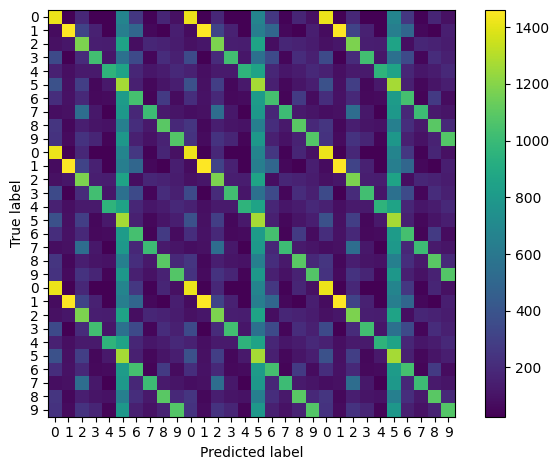

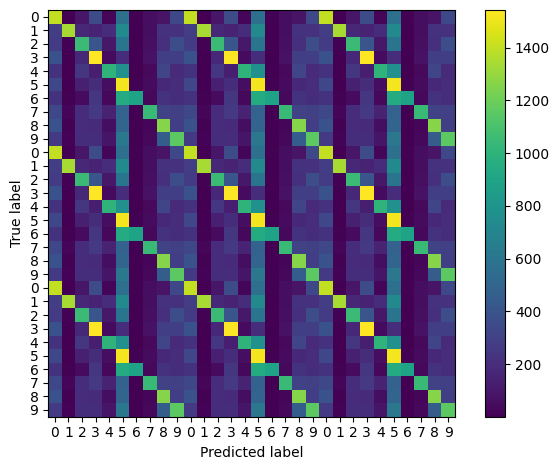

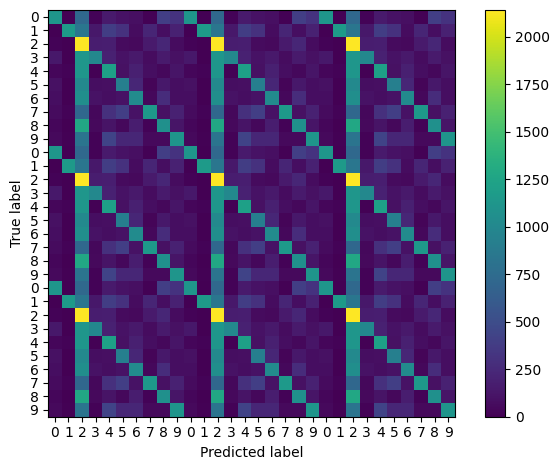

In [32]:
train_and_eval("lenet", "pmnist", strategy_name="naive", epochs=5, lr=0.001)

Saved plot: /content/drive/MyDrive/Colab Notebooks/Task3/results/lenet_pmnist/metrics_naive_ep5_lr0.001.png


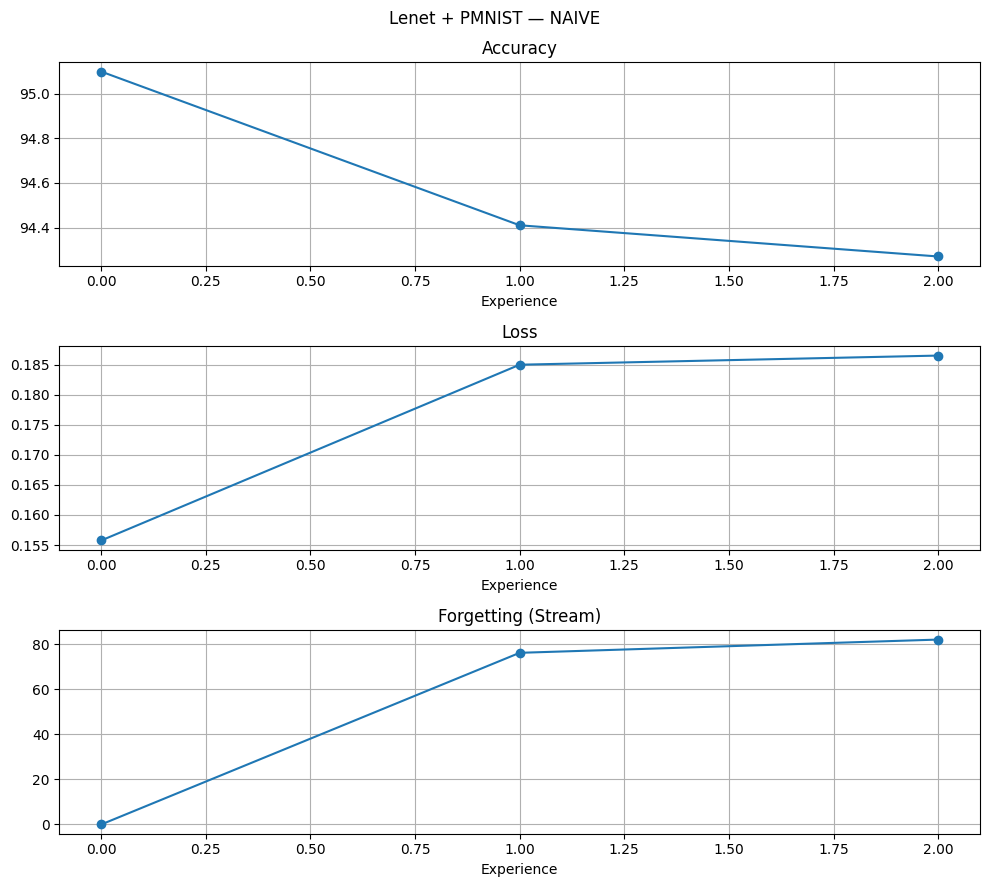

|   Experience |   Accuracy (%) |     Loss |   Stream Forgetting (%) |
|-------------:|---------------:|---------:|------------------------:|
|            0 |          95.1  | 0.155758 |                    0    |
|            1 |          94.41 | 0.184975 |                   76.23 |
|            2 |          94.27 | 0.186493 |                   82.11 |


In [33]:
plot_and_print_metrics(
    model_name="lenet",
    dataset_name="pmnist",
    strategy="naive",
    epochs=5,
    lr=0.001
)

Naive 10 epochs


LENET_PMNIST / Strategy: NAIVE / Epochs: 10 / LR: 0.001
>>> Training on Exp 0
-- >> Start of training phase << --
100%|██████████| 1875/1875 [00:23<00:00, 79.64it/s]
Epoch 0 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 93.7957
	Loss_Epoch/train_phase/train_stream/Task000 = 0.4871
	Time_Epoch/train_phase/train_stream/Task000 = 23.5516
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.8419
100%|██████████| 1875/1875 [00:32<00:00, 58.33it/s]
Epoch 1 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 75.2695
	Loss_Epoch/train_phase/train_stream/Task000 = 0.2180
	Time_Epoch/train_phase/train_stream/Task000 = 32.1385
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.9317
100%|██████████| 1875/1875 [00:31<00:00, 60.00it/s]
Epoch 2 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 77.2980
	Loss_Epoch/train_phase/train_stream/Task000 = 0.1732
	Time_Epoch/train_phase/train_stream/Task000 = 31.2432
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.9454
100%|█

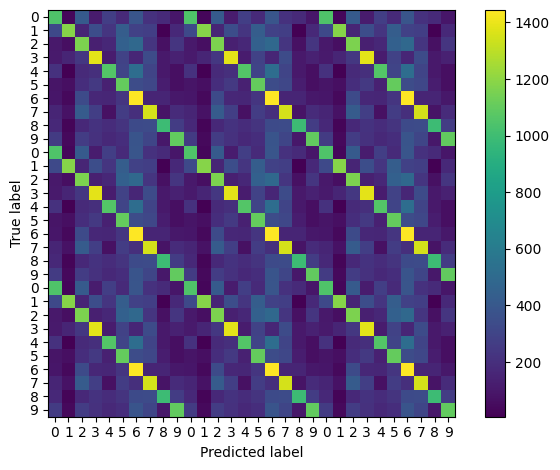

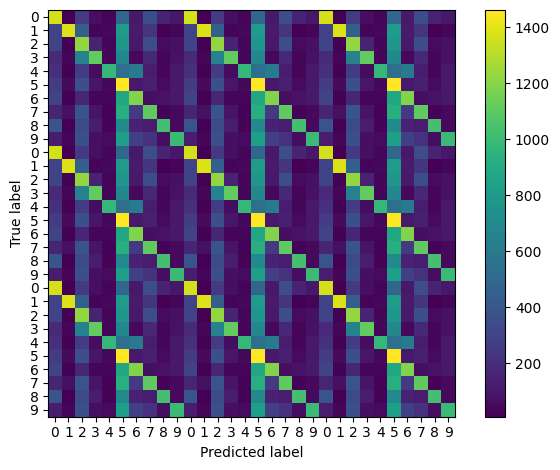

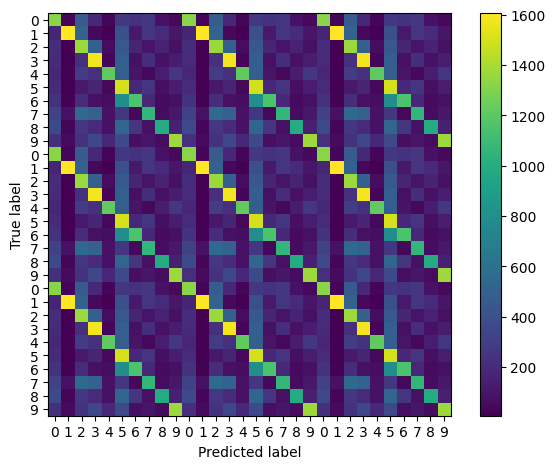

In [34]:
train_and_eval("lenet", "pmnist", strategy_name="naive", epochs=10, lr=0.001)

Saved plot: /content/drive/MyDrive/Colab Notebooks/Task3/results/lenet_pmnist/metrics_naive_ep10_lr0.001.png


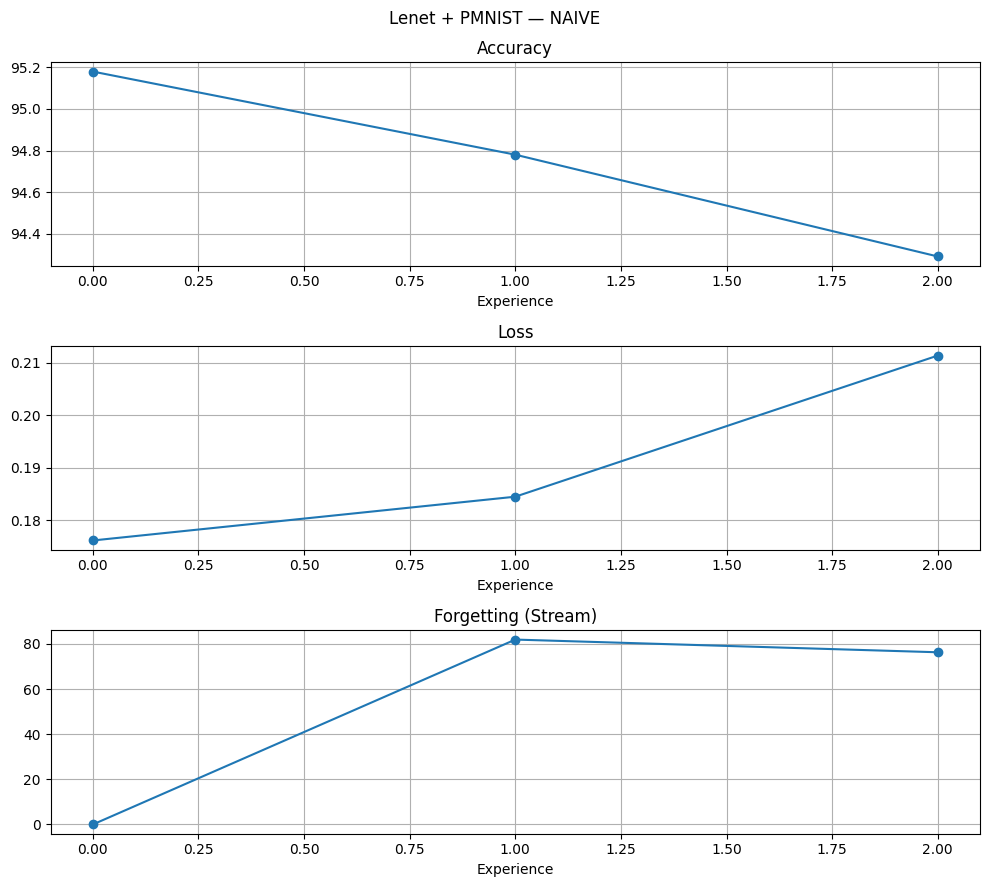

|   Experience |   Accuracy (%) |     Loss |   Stream Forgetting (%) |
|-------------:|---------------:|---------:|------------------------:|
|            0 |          95.18 | 0.176126 |                   0     |
|            1 |          94.78 | 0.184469 |                  81.94  |
|            2 |          94.29 | 0.21136  |                  76.315 |


In [35]:
plot_and_print_metrics(
    model_name="lenet",
    dataset_name="pmnist",
    strategy="naive",
    epochs=10,
    lr=0.001
)

## EWC

EWC 5 epochs


LENET_PMNIST / Strategy: EWC / Epochs: 5 / LR: 0.001
>>> Training on Exp 0
-- >> Start of training phase << --
100%|██████████| 1875/1875 [00:26<00:00, 71.80it/s]
Epoch 0 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 88.5011
	Loss_Epoch/train_phase/train_stream/Task000 = 0.5126
	Time_Epoch/train_phase/train_stream/Task000 = 26.1129
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.8351
100%|██████████| 1875/1875 [00:25<00:00, 74.70it/s]
Epoch 1 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 89.7298
	Loss_Epoch/train_phase/train_stream/Task000 = 0.2345
	Time_Epoch/train_phase/train_stream/Task000 = 25.0980
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.9274
100%|██████████| 1875/1875 [00:24<00:00, 76.14it/s]
Epoch 2 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 91.0214
	Loss_Epoch/train_phase/train_stream/Task000 = 0.1858
	Time_Epoch/train_phase/train_stream/Task000 = 24.6207
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.9411
100%|████

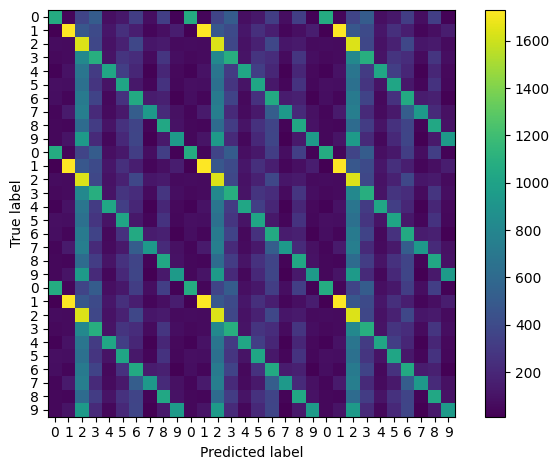

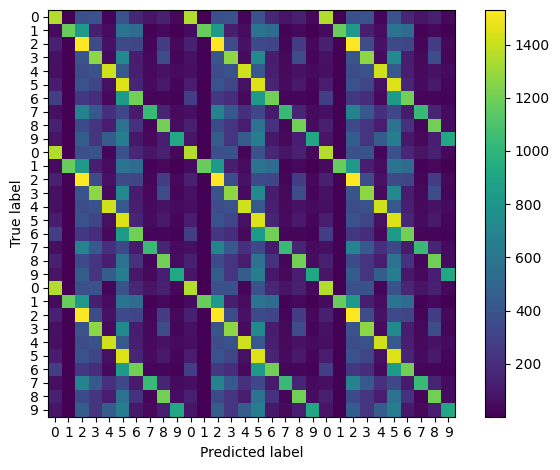

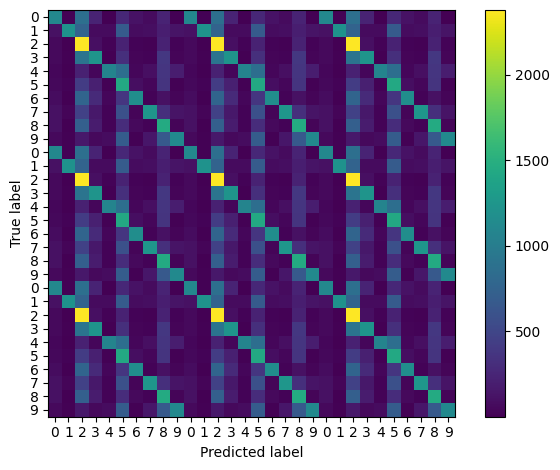

In [37]:
train_and_eval("lenet", "pmnist", strategy_name="ewc", epochs=5, lr=0.001)

Saved plot: /content/drive/MyDrive/Colab Notebooks/Task3/results/lenet_pmnist/metrics_ewc_ep5_lr0.001.png


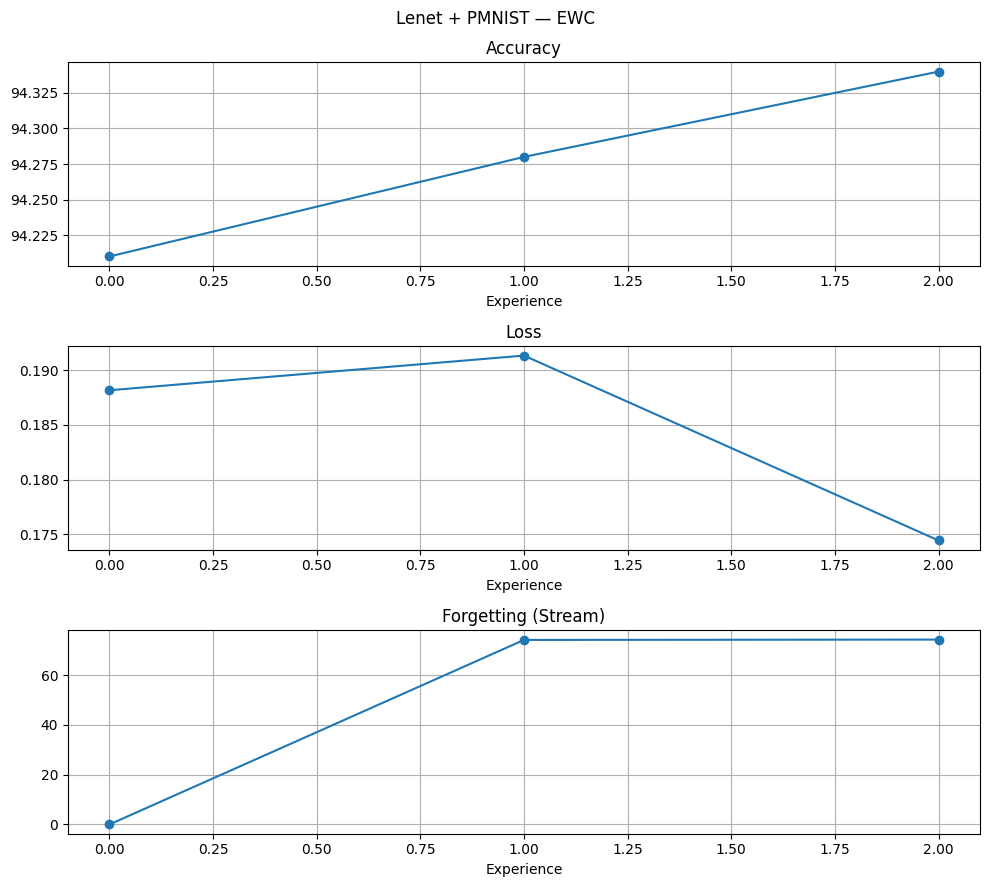

|   Experience |   Accuracy (%) |     Loss |   Stream Forgetting (%) |
|-------------:|---------------:|---------:|------------------------:|
|            0 |          94.21 | 0.188165 |                    0    |
|            1 |          94.28 | 0.191336 |                   74.12 |
|            2 |          94.34 | 0.174425 |                   74.26 |


In [38]:
plot_and_print_metrics(
    model_name="lenet",
    dataset_name="pmnist",
    strategy="ewc",
    epochs=5,
    lr=0.001
)

EWC 10 epochs


LENET_PMNIST / Strategy: EWC / Epochs: 10 / LR: 0.001
>>> Training on Exp 0
-- >> Start of training phase << --
100%|██████████| 1875/1875 [00:22<00:00, 84.58it/s]
Epoch 0 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 96.9059
	Loss_Epoch/train_phase/train_stream/Task000 = 0.4765
	Time_Epoch/train_phase/train_stream/Task000 = 22.1658
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.8472
100%|██████████| 1875/1875 [00:23<00:00, 80.64it/s]
Epoch 1 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 97.1884
	Loss_Epoch/train_phase/train_stream/Task000 = 0.2225
	Time_Epoch/train_phase/train_stream/Task000 = 23.2439
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.9304
100%|██████████| 1875/1875 [00:22<00:00, 85.17it/s]
Epoch 2 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 97.7109
	Loss_Epoch/train_phase/train_stream/Task000 = 0.1777
	Time_Epoch/train_phase/train_stream/Task000 = 22.0142
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.9441
100%|███

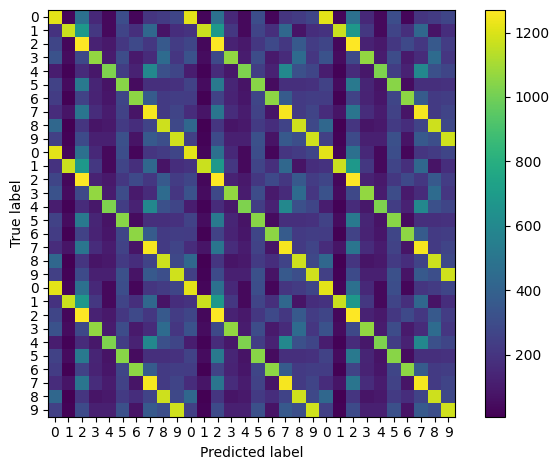

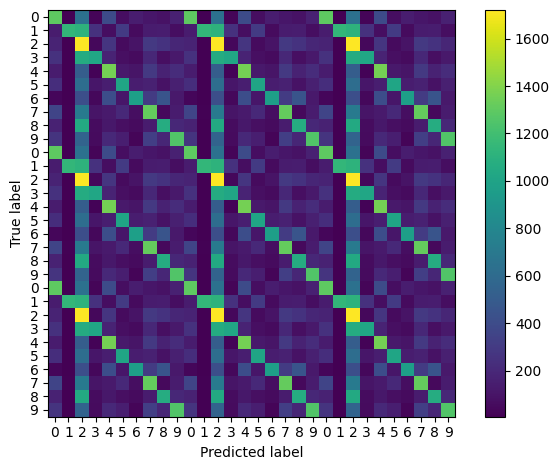

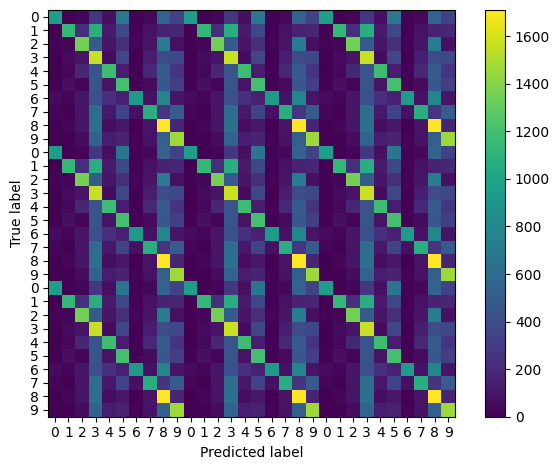

In [39]:
train_and_eval("lenet", "pmnist", strategy_name="ewc", epochs=10, lr=0.001)

Saved plot: /content/drive/MyDrive/Colab Notebooks/Task3/results/lenet_pmnist/metrics_ewc_ep10_lr0.001.png


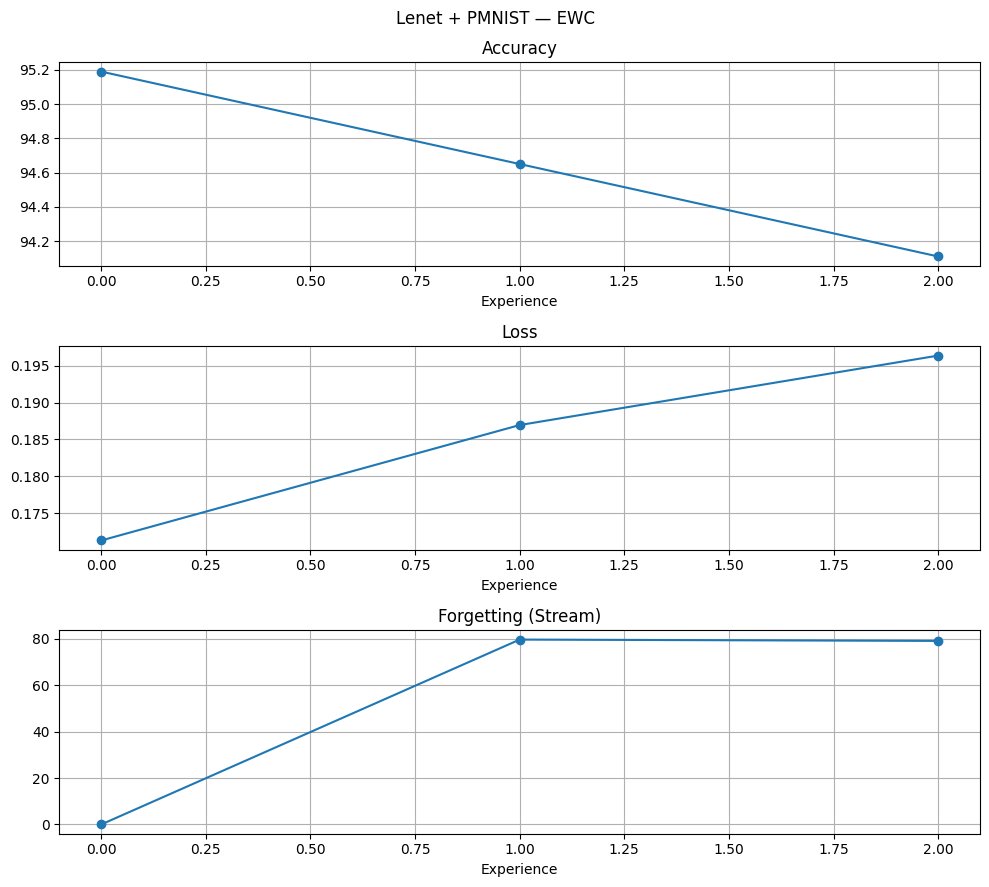

|   Experience |   Accuracy (%) |     Loss |   Stream Forgetting (%) |
|-------------:|---------------:|---------:|------------------------:|
|            0 |          95.19 | 0.171312 |                    0    |
|            1 |          94.65 | 0.186953 |                   79.7  |
|            2 |          94.11 | 0.196369 |                   79.12 |


In [40]:
plot_and_print_metrics(
    model_name="lenet",
    dataset_name="pmnist",
    strategy="ewc",
    epochs=10,
    lr=0.001
)

## Cumulative

Cumulative 5 epochs


LENET_PMNIST / Strategy: CUMULATIVE / Epochs: 5 / LR: 0.001
>>> Training on Exp 0
-- >> Start of training phase << --
100%|██████████| 1875/1875 [00:21<00:00, 86.36it/s]
Epoch 0 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 96.9173
	Loss_Epoch/train_phase/train_stream/Task000 = 0.4935
	Time_Epoch/train_phase/train_stream/Task000 = 21.7093
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.8410
100%|██████████| 1875/1875 [00:20<00:00, 91.24it/s]
Epoch 1 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 98.0197
	Loss_Epoch/train_phase/train_stream/Task000 = 0.2271
	Time_Epoch/train_phase/train_stream/Task000 = 20.5472
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.9284
100%|██████████| 1875/1875 [00:21<00:00, 86.89it/s]
Epoch 2 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 97.1459
	Loss_Epoch/train_phase/train_stream/Task000 = 0.1825
	Time_Epoch/train_phase/train_stream/Task000 = 21.5764
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.9423
10

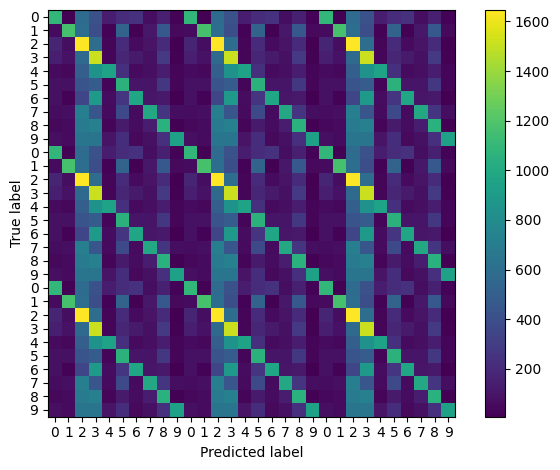

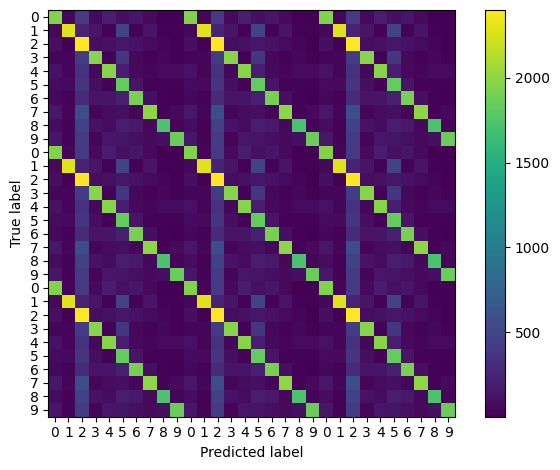

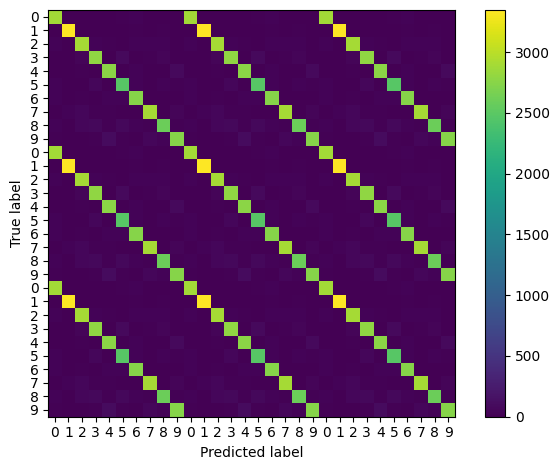

In [41]:
train_and_eval("lenet", "pmnist", strategy_name="cumulative", epochs=5, lr=0.001)

Saved plot: /content/drive/MyDrive/Colab Notebooks/Task3/results/lenet_pmnist/metrics_cumulative_ep5_lr0.001.png


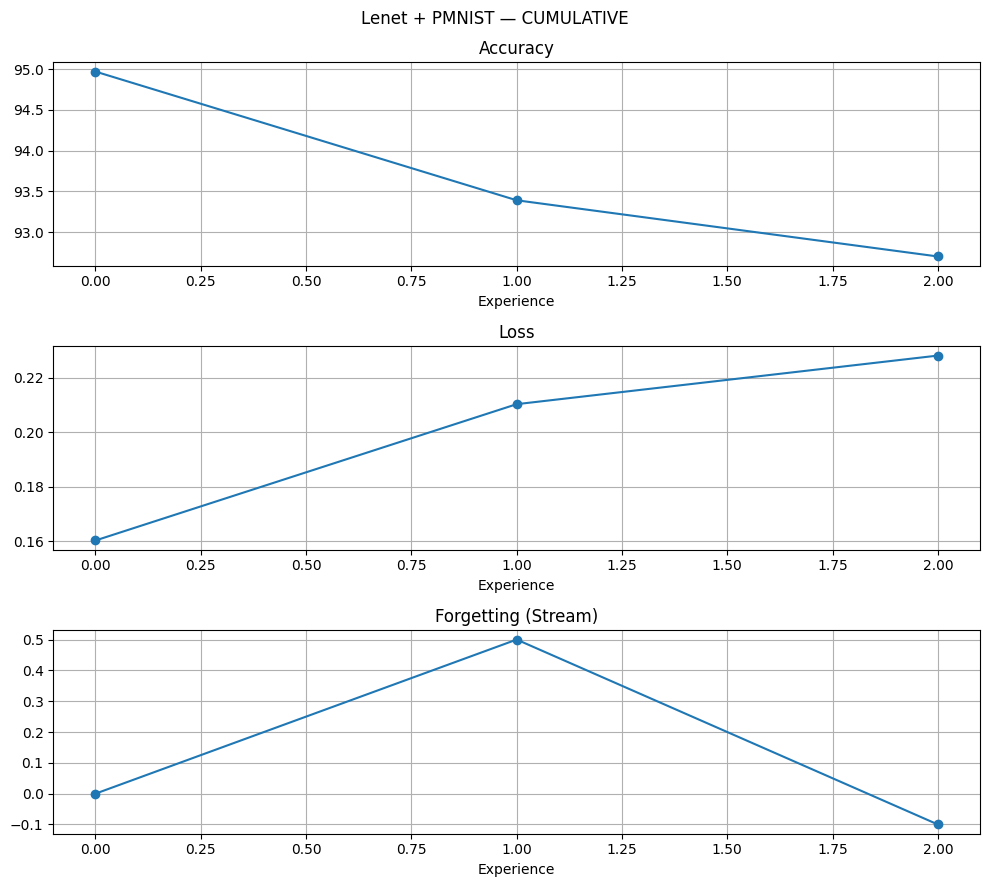

|   Experience |   Accuracy (%) |     Loss |   Stream Forgetting (%) |
|-------------:|---------------:|---------:|------------------------:|
|            0 |          94.97 | 0.160236 |                     0   |
|            1 |          93.39 | 0.210241 |                     0.5 |
|            2 |          92.7  | 0.228068 |                    -0.1 |


In [42]:
plot_and_print_metrics(
    model_name="lenet",
    dataset_name="pmnist",
    strategy="cumulative",
    epochs=5,
    lr=0.001
)

Cumulative 10 epochs


LENET_PMNIST / Strategy: CUMULATIVE / Epochs: 10 / LR: 0.001
>>> Training on Exp 0
-- >> Start of training phase << --
100%|██████████| 1875/1875 [00:21<00:00, 86.05it/s]
Epoch 0 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 96.9889
	Loss_Epoch/train_phase/train_stream/Task000 = 0.4992
	Time_Epoch/train_phase/train_stream/Task000 = 21.7862
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.8393
100%|██████████| 1875/1875 [00:20<00:00, 90.17it/s]
Epoch 1 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 98.4102
	Loss_Epoch/train_phase/train_stream/Task000 = 0.2277
	Time_Epoch/train_phase/train_stream/Task000 = 20.7912
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.9275
100%|██████████| 1875/1875 [00:21<00:00, 87.14it/s]
Epoch 2 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 97.1401
	Loss_Epoch/train_phase/train_stream/Task000 = 0.1792
	Time_Epoch/train_phase/train_stream/Task000 = 21.5157
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.9434
1

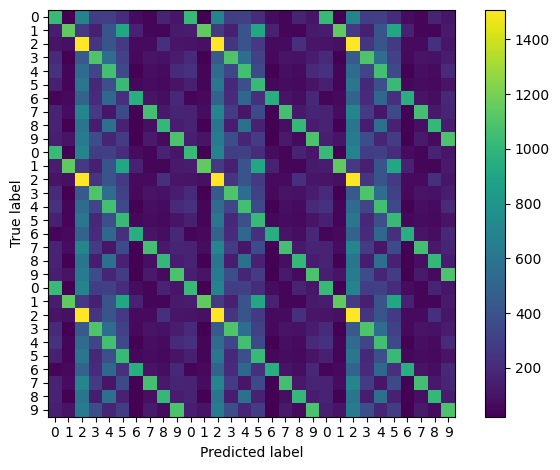

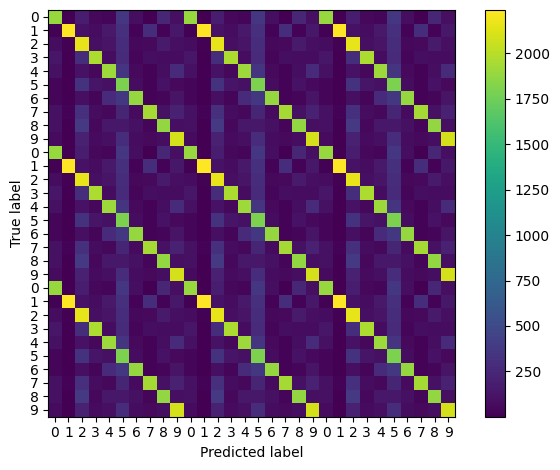

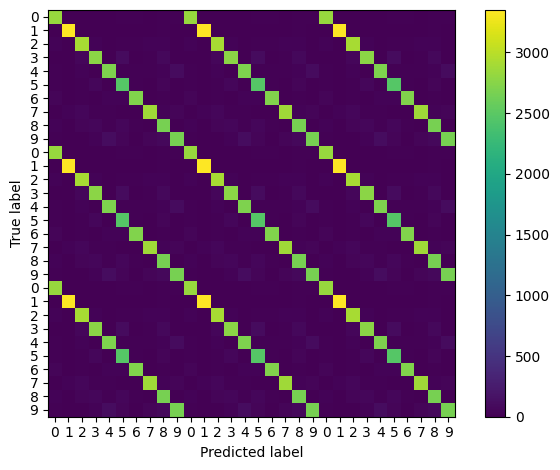

In [43]:
train_and_eval("lenet", "pmnist", strategy_name="cumulative", epochs=10, lr=0.001)

Saved plot: /content/drive/MyDrive/Colab Notebooks/Task3/results/lenet_pmnist/metrics_cumulative_ep10_lr0.001.png


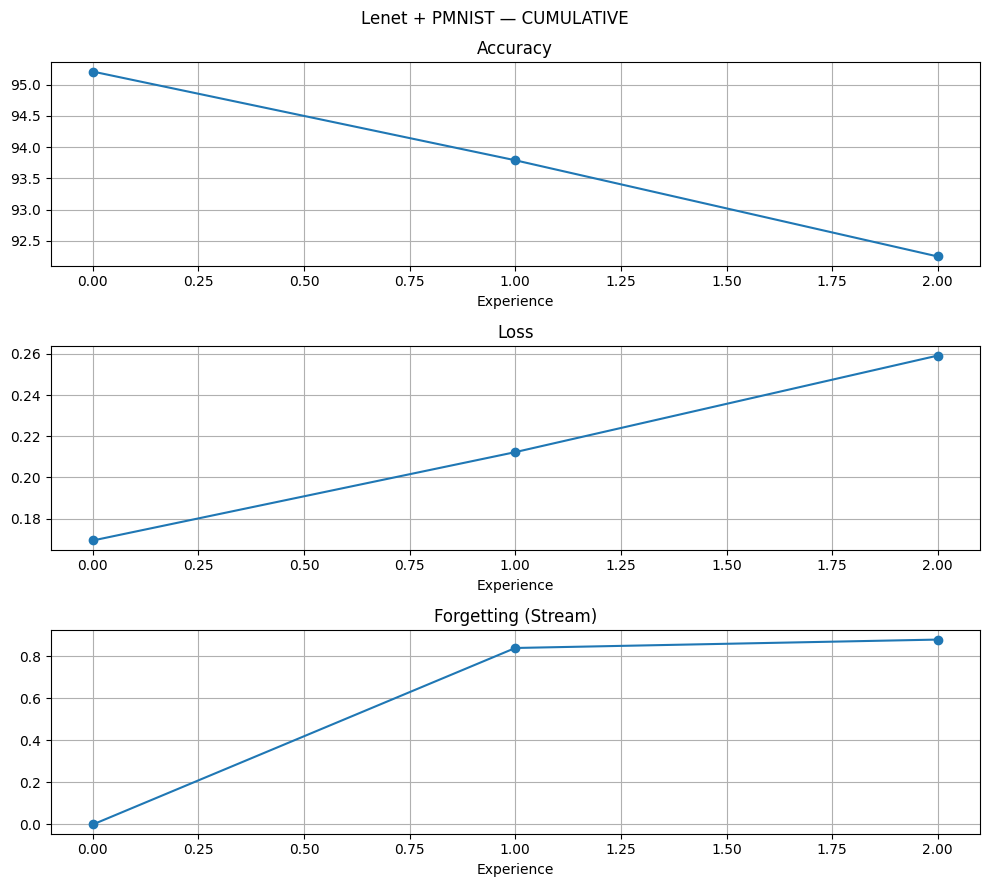

|   Experience |   Accuracy (%) |     Loss |   Stream Forgetting (%) |
|-------------:|---------------:|---------:|------------------------:|
|            0 |          95.21 | 0.169324 |                    0    |
|            1 |          93.79 | 0.212267 |                    0.84 |
|            2 |          92.25 | 0.259186 |                    0.88 |


In [44]:
plot_and_print_metrics(
    model_name="lenet",
    dataset_name="pmnist",
    strategy="cumulative",
    epochs=10,
    lr=0.001
)

# SCNN + Permuted Mnist

## Naive

Naive 3 epochs


SIMPLECNN_PMNIST / Strategy: NAIVE / Epochs: 3 / LR: 0.001
>>> Training on Exp 0
-- >> Start of training phase << --
100%|██████████| 1875/1875 [00:31<00:00, 58.80it/s]
Epoch 0 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 77.1468
	Loss_Epoch/train_phase/train_stream/Task000 = 0.3631
	Time_Epoch/train_phase/train_stream/Task000 = 31.8877
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.8850
100%|██████████| 1875/1875 [00:23<00:00, 78.35it/s]
Epoch 1 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 96.5321
	Loss_Epoch/train_phase/train_stream/Task000 = 0.1459
	Time_Epoch/train_phase/train_stream/Task000 = 23.9303
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.9547
100%|██████████| 1875/1875 [00:22<00:00, 81.90it/s]
Epoch 2 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 97.2912
	Loss_Epoch/train_phase/train_stream/Task000 = 0.1008
	Time_Epoch/train_phase/train_stream/Task000 = 22.8906
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.9684
-- 

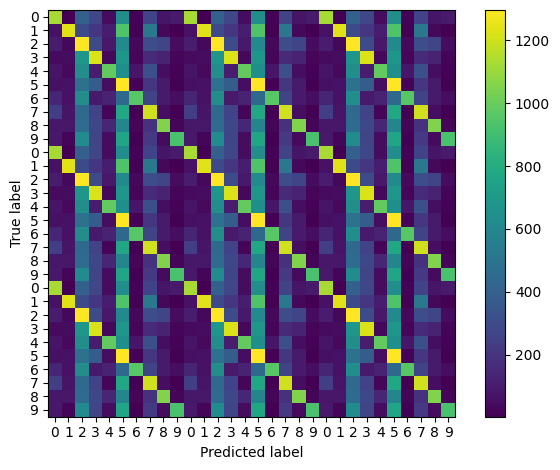

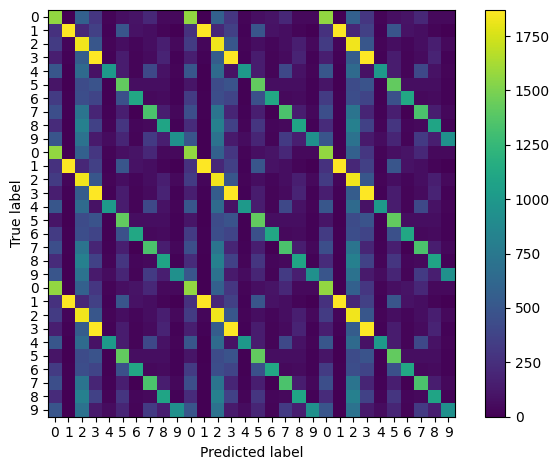

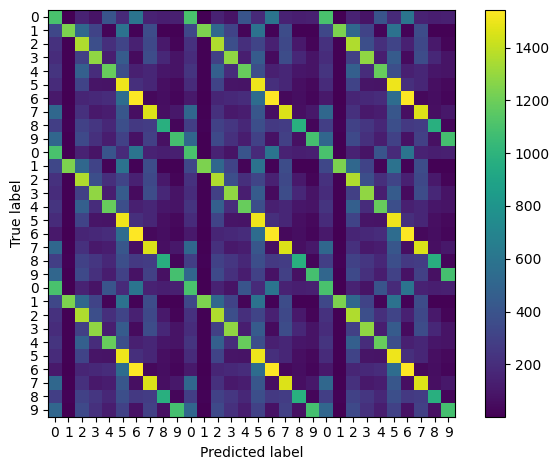

In [20]:
train_and_eval("simplecnn", "pmnist", strategy_name="naive", epochs=3, lr=0.001)

Saved plot: /content/drive/MyDrive/Colab Notebooks/Task3/results/simplecnn_pmnist/metrics_naive_ep3_lr0.001.png


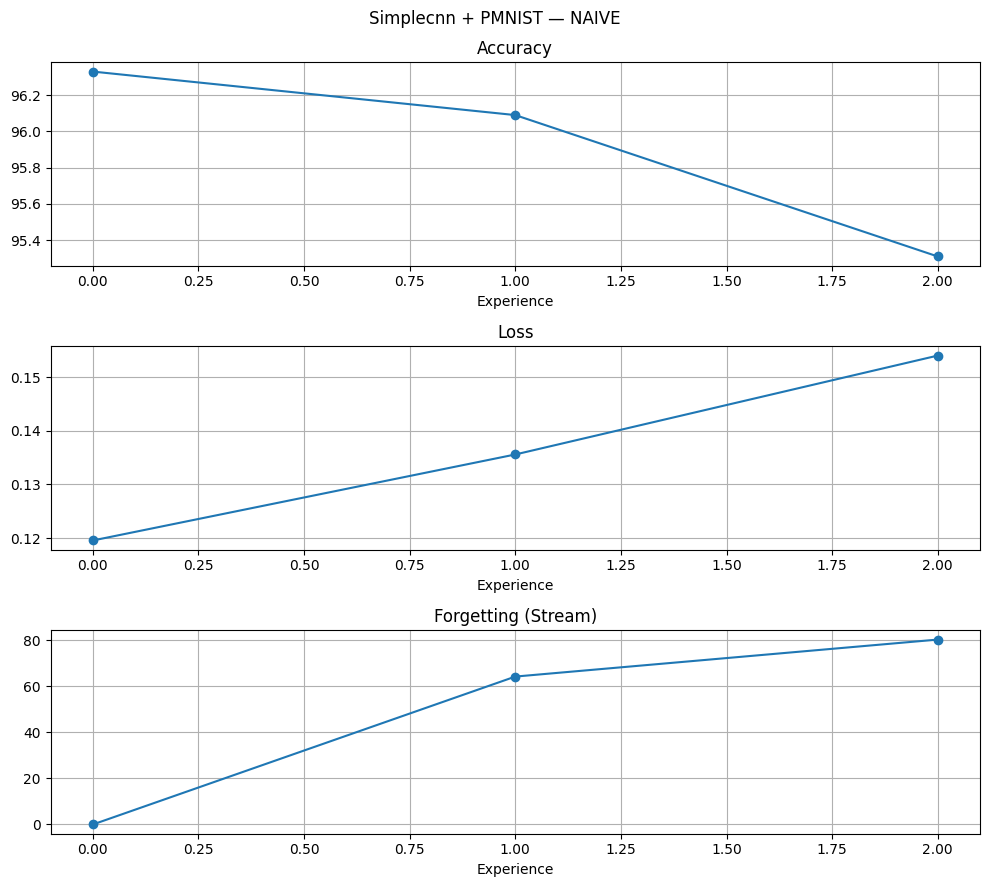

|   Experience |   Accuracy (%) |     Loss |   Stream Forgetting (%) |
|-------------:|---------------:|---------:|------------------------:|
|            0 |          96.33 | 0.119543 |                   0     |
|            1 |          96.09 | 0.135574 |                  64.15  |
|            2 |          95.31 | 0.154009 |                  80.195 |


In [21]:
plot_and_print_metrics("simplecnn", "pmnist", strategy="naive", epochs=3, lr=0.001)

Naive 5 epochs


SIMPLECNN_PMNIST / Strategy: NAIVE / Epochs: 5 / LR: 0.001
>>> Training on Exp 0
-- >> Start of training phase << --
100%|██████████| 1875/1875 [00:23<00:00, 81.32it/s]
Epoch 0 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 96.6397
	Loss_Epoch/train_phase/train_stream/Task000 = 0.3863
	Time_Epoch/train_phase/train_stream/Task000 = 23.0548
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.8768
100%|██████████| 1875/1875 [00:23<00:00, 78.27it/s]
Epoch 1 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 97.0634
	Loss_Epoch/train_phase/train_stream/Task000 = 0.1527
	Time_Epoch/train_phase/train_stream/Task000 = 23.9542
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.9528
100%|██████████| 1875/1875 [00:23<00:00, 78.32it/s]
Epoch 2 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 95.8429
	Loss_Epoch/train_phase/train_stream/Task000 = 0.1101
	Time_Epoch/train_phase/train_stream/Task000 = 23.9351
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.9647
100

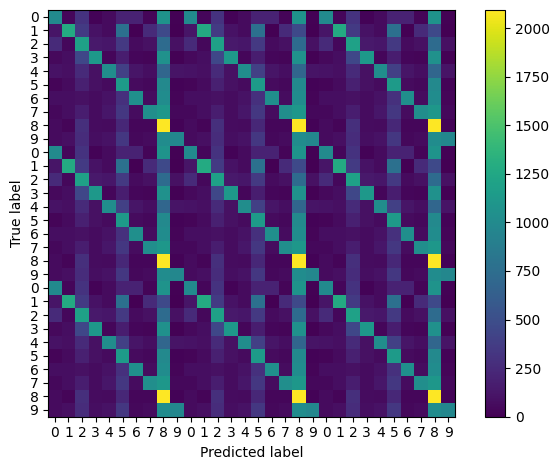

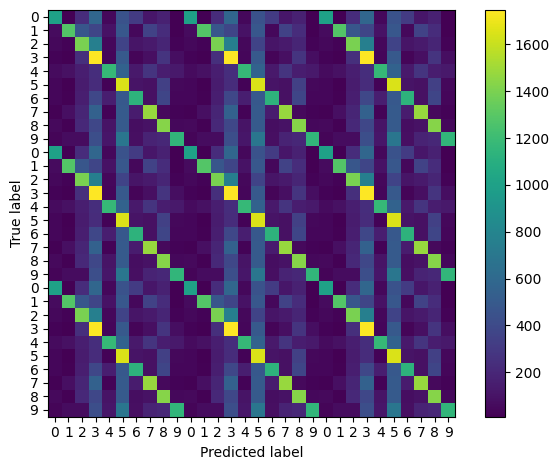

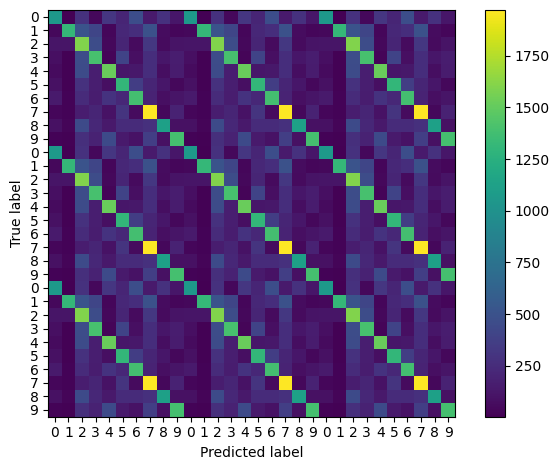

In [22]:
train_and_eval("simplecnn", "pmnist", strategy_name="naive", epochs=5, lr=0.001)

Saved plot: /content/drive/MyDrive/Colab Notebooks/Task3/results/simplecnn_pmnist/metrics_naive_ep5_lr0.001.png


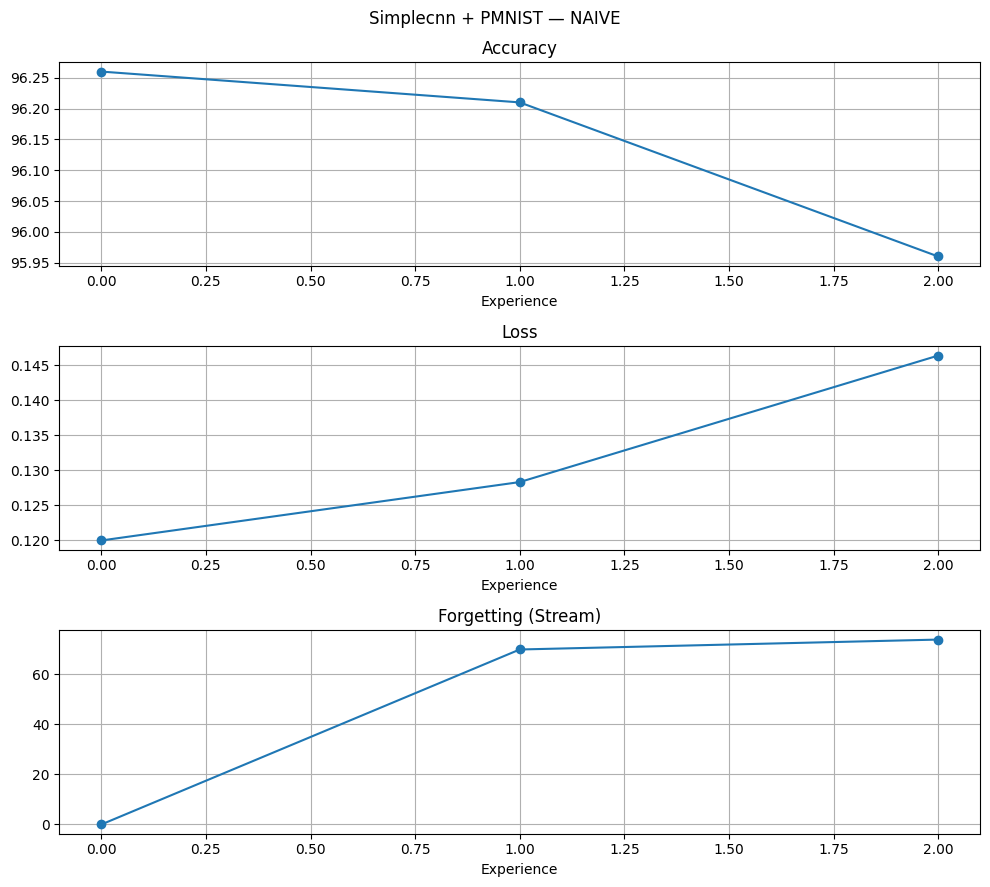

|   Experience |   Accuracy (%) |     Loss |   Stream Forgetting (%) |
|-------------:|---------------:|---------:|------------------------:|
|            0 |          96.26 | 0.119953 |                    0    |
|            1 |          96.21 | 0.128304 |                   69.87 |
|            2 |          95.96 | 0.146391 |                   73.83 |


In [23]:
plot_and_print_metrics("simplecnn", "pmnist", strategy="naive", epochs=5, lr=0.001)

## EWC

EWC 5 epochs lr=0.001


SIMPLECNN_PMNIST / Strategy: EWC / Epochs: 5 / LR: 0.001
>>> Training on Exp 0
-- >> Start of training phase << --
100%|██████████| 1875/1875 [00:23<00:00, 80.55it/s]
Epoch 0 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 97.2276
	Loss_Epoch/train_phase/train_stream/Task000 = 0.3160
	Time_Epoch/train_phase/train_stream/Task000 = 23.2756
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.9015
100%|██████████| 1875/1875 [00:22<00:00, 82.27it/s]
Epoch 1 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 97.1682
	Loss_Epoch/train_phase/train_stream/Task000 = 0.1296
	Time_Epoch/train_phase/train_stream/Task000 = 22.7858
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.9590
100%|██████████| 1875/1875 [00:22<00:00, 81.63it/s]
Epoch 2 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 96.9752
	Loss_Epoch/train_phase/train_stream/Task000 = 0.0888
	Time_Epoch/train_phase/train_stream/Task000 = 22.9646
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.9710
100%|

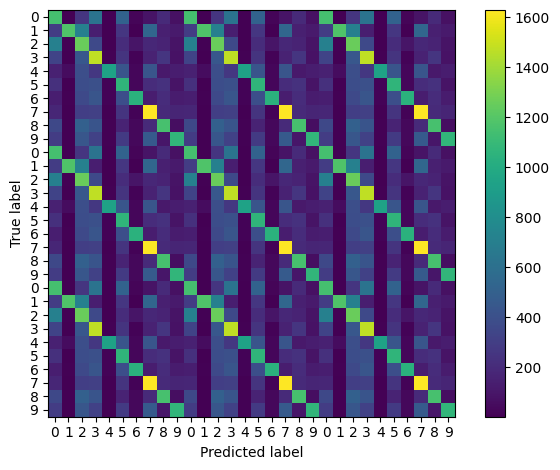

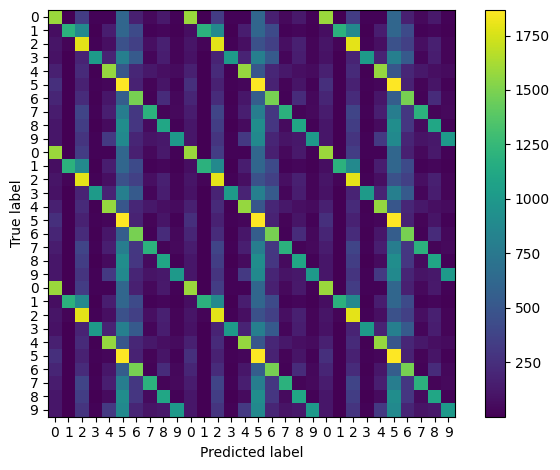

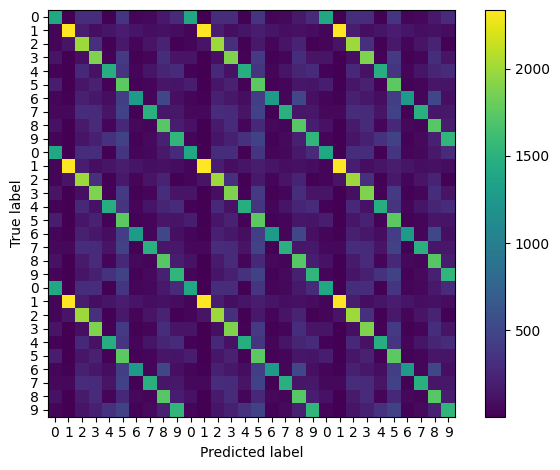

In [24]:
train_and_eval("simplecnn", "pmnist", strategy_name="ewc", epochs=5, lr=0.001)

Saved plot: /content/drive/MyDrive/Colab Notebooks/Task3/results/simplecnn_pmnist/metrics_ewc_ep5_lr0.001.png


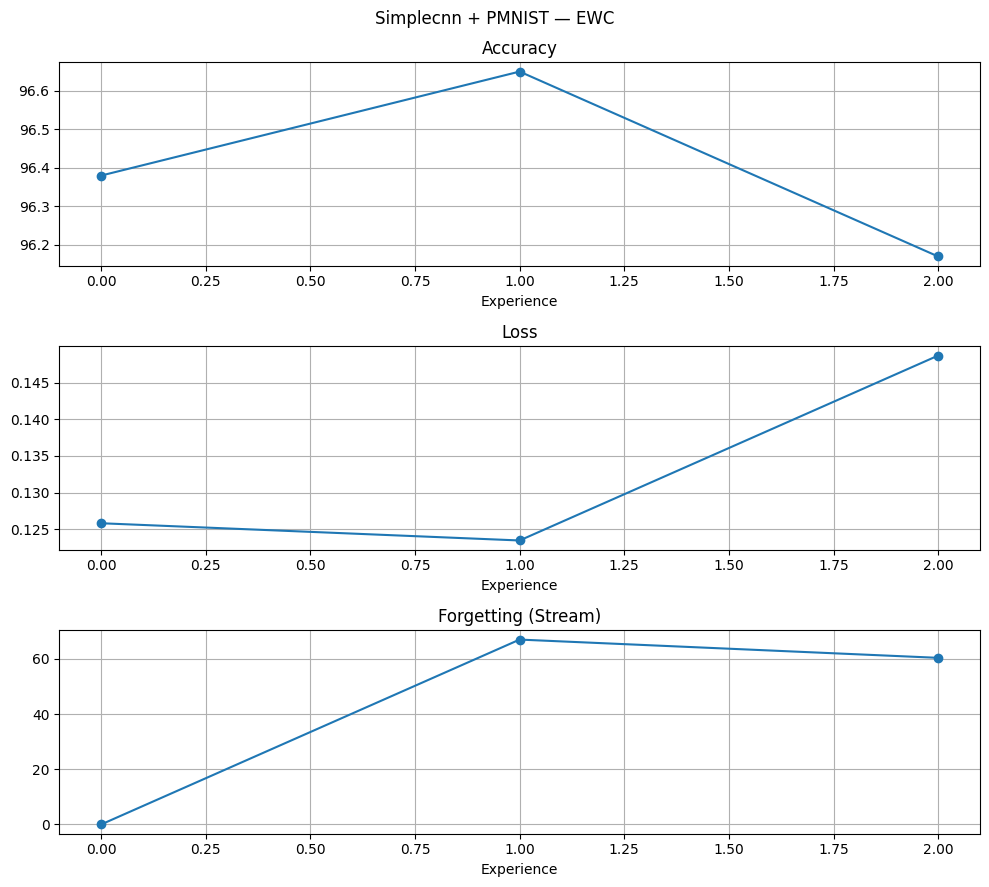

|   Experience |   Accuracy (%) |     Loss |   Stream Forgetting (%) |
|-------------:|---------------:|---------:|------------------------:|
|            0 |          96.38 | 0.125797 |                    0    |
|            1 |          96.65 | 0.123441 |                   67.04 |
|            2 |          96.17 | 0.148719 |                   60.42 |


In [25]:
plot_and_print_metrics("simplecnn", "pmnist", strategy="ewc", epochs=5, lr=0.001)

EWC 5 epochs lr=0.0005


SIMPLECNN_PMNIST / Strategy: EWC / Epochs: 5 / LR: 0.0005
>>> Training on Exp 0
-- >> Start of training phase << --
100%|██████████| 1875/1875 [00:23<00:00, 80.98it/s]
Epoch 0 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 97.7573
	Loss_Epoch/train_phase/train_stream/Task000 = 0.3071
	Time_Epoch/train_phase/train_stream/Task000 = 23.1493
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.9068
100%|██████████| 1875/1875 [00:23<00:00, 78.37it/s]
Epoch 1 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 96.9081
	Loss_Epoch/train_phase/train_stream/Task000 = 0.1191
	Time_Epoch/train_phase/train_stream/Task000 = 23.9197
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.9636
100%|██████████| 1875/1875 [00:22<00:00, 83.45it/s]
Epoch 2 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 97.8479
	Loss_Epoch/train_phase/train_stream/Task000 = 0.0774
	Time_Epoch/train_phase/train_stream/Task000 = 22.4640
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.9754
100%

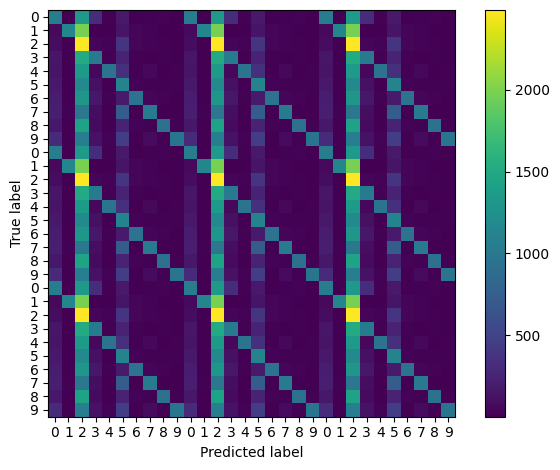

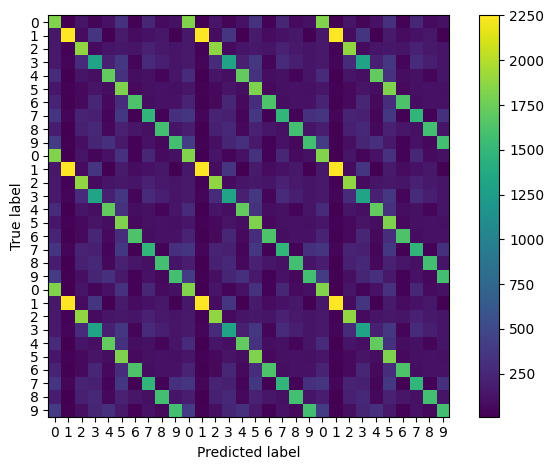

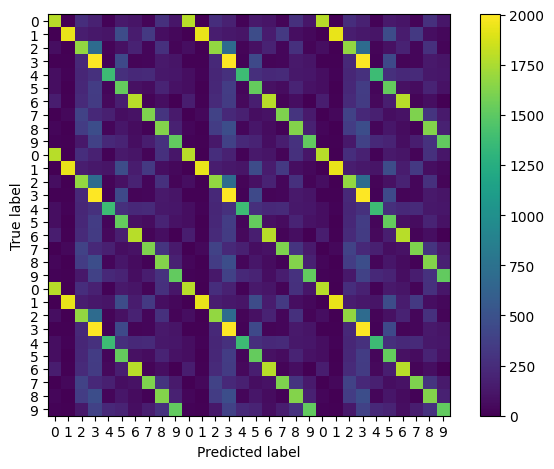

In [26]:
train_and_eval("simplecnn", "pmnist", strategy_name="ewc", epochs=5, lr=0.0005)

Saved plot: /content/drive/MyDrive/Colab Notebooks/Task3/results/simplecnn_pmnist/metrics_ewc_ep5_lr0.0005.png


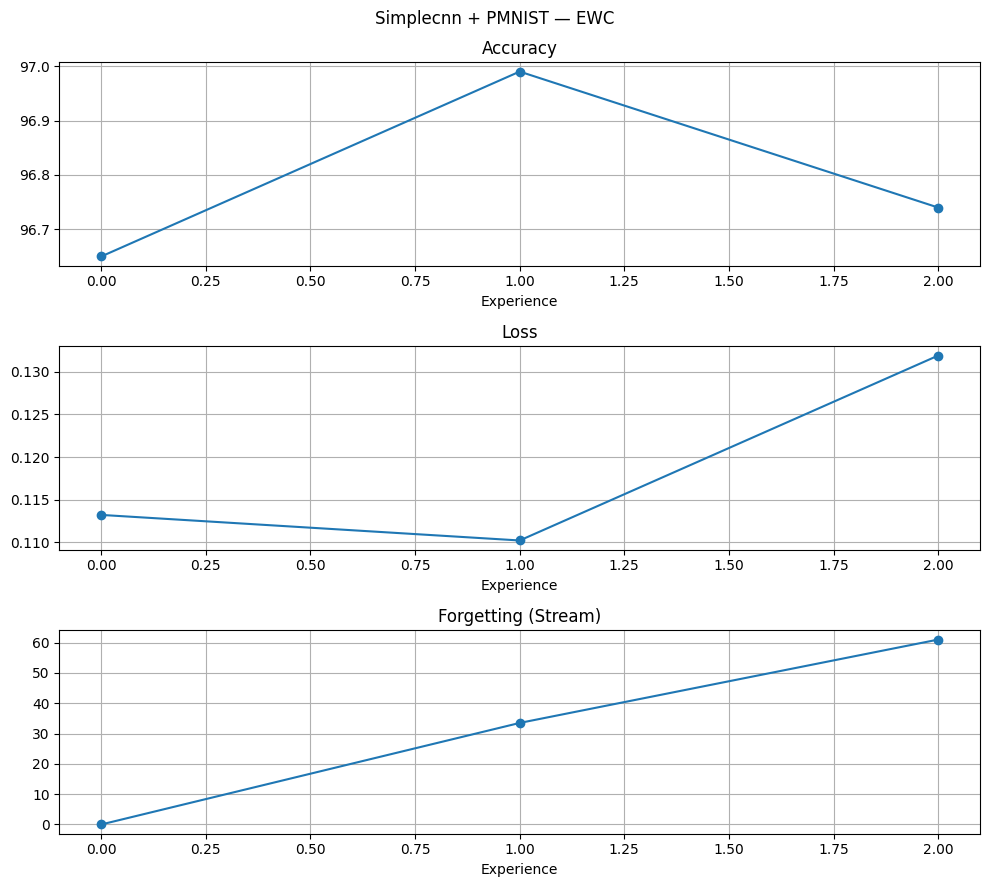

|   Experience |   Accuracy (%) |     Loss |   Stream Forgetting (%) |
|-------------:|---------------:|---------:|------------------------:|
|            0 |          96.65 | 0.113225 |                   0     |
|            1 |          96.99 | 0.11023  |                  33.49  |
|            2 |          96.74 | 0.131888 |                  60.985 |


In [27]:
plot_and_print_metrics("simplecnn", "pmnist", strategy="ewc", epochs=5, lr=0.0005)

EWC 10 epochs lr=0.001


SIMPLECNN_PMNIST / Strategy: EWC / Epochs: 10 / LR: 0.001
>>> Training on Exp 0
-- >> Start of training phase << --
100%|██████████| 1875/1875 [00:23<00:00, 81.43it/s]
Epoch 0 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 96.9363
	Loss_Epoch/train_phase/train_stream/Task000 = 0.3386
	Time_Epoch/train_phase/train_stream/Task000 = 23.0357
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.8944
100%|██████████| 1875/1875 [00:22<00:00, 83.66it/s]
Epoch 1 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 97.6447
	Loss_Epoch/train_phase/train_stream/Task000 = 0.1344
	Time_Epoch/train_phase/train_stream/Task000 = 22.4081
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.9588
100%|██████████| 1875/1875 [00:22<00:00, 81.53it/s]
Epoch 2 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 97.5940
	Loss_Epoch/train_phase/train_stream/Task000 = 0.0923
	Time_Epoch/train_phase/train_stream/Task000 = 22.9930
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.9706
100%

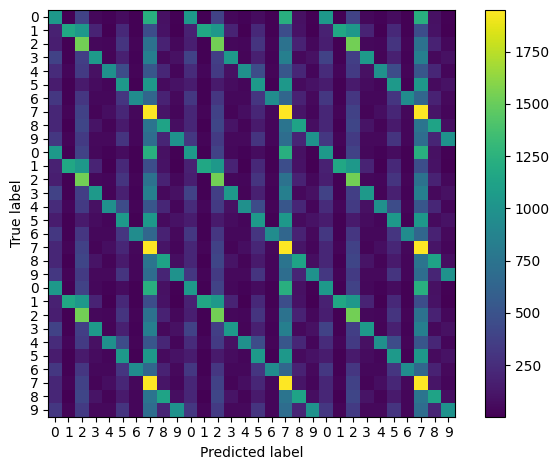

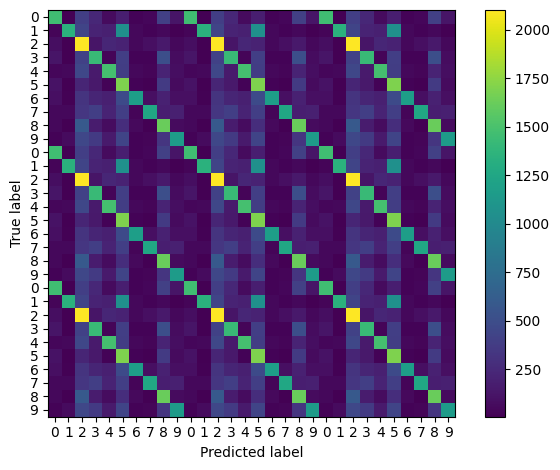

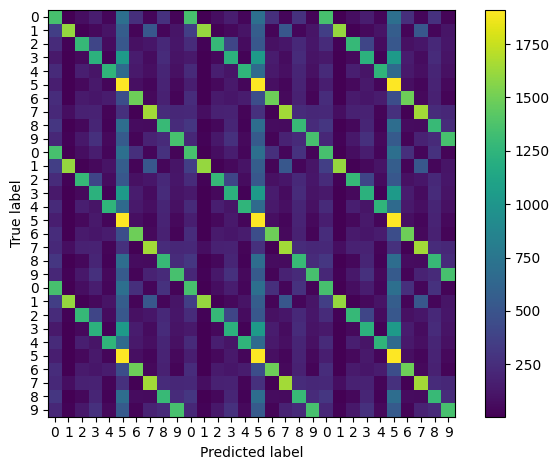

In [28]:
train_and_eval("simplecnn", "pmnist", strategy_name="ewc", epochs=10, lr=0.001)

Saved plot: /content/drive/MyDrive/Colab Notebooks/Task3/results/simplecnn_pmnist/metrics_ewc_ep10_lr0.001.png


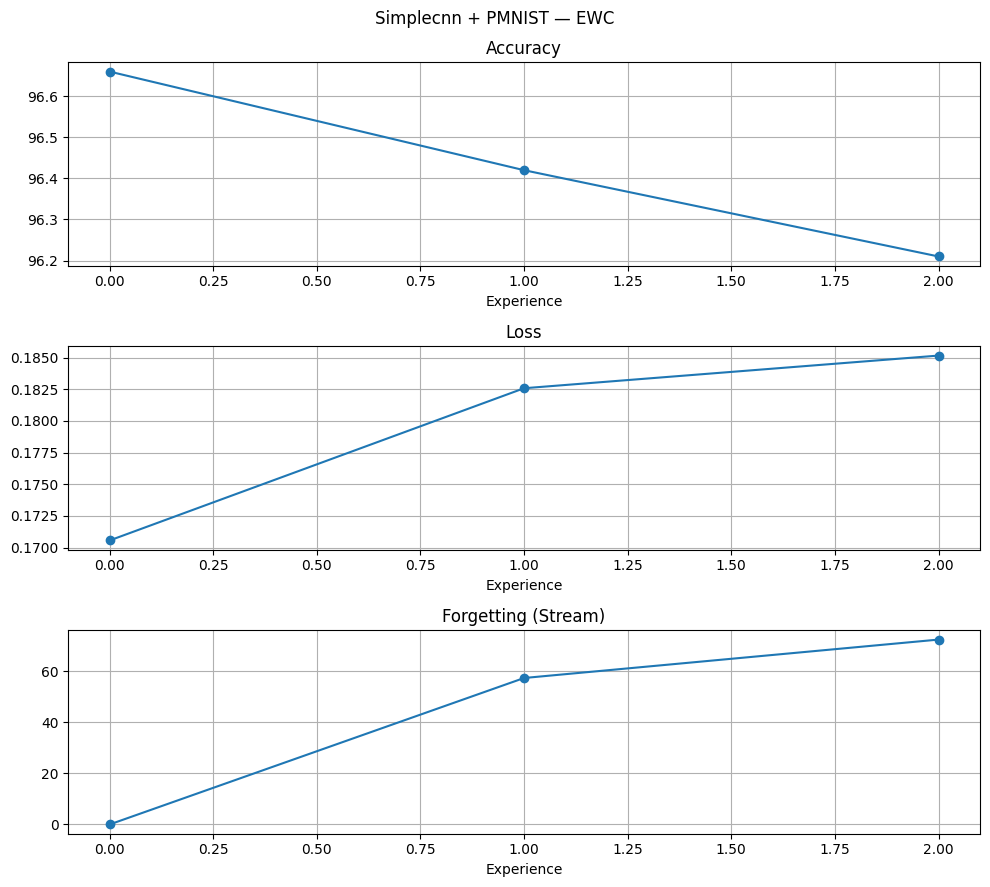

|   Experience |   Accuracy (%) |     Loss |   Stream Forgetting (%) |
|-------------:|---------------:|---------:|------------------------:|
|            0 |          96.66 | 0.170557 |                    0    |
|            1 |          96.42 | 0.182578 |                   57.44 |
|            2 |          96.21 | 0.185157 |                   72.51 |


In [29]:
plot_and_print_metrics("simplecnn", "pmnist", strategy="ewc", epochs=10, lr=0.001)

EWC 10 epochs lr=0.0005


SIMPLECNN_PMNIST / Strategy: EWC / Epochs: 10 / LR: 0.0005
>>> Training on Exp 0
-- >> Start of training phase << --
100%|██████████| 1875/1875 [00:22<00:00, 82.98it/s]
Epoch 0 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 97.1583
	Loss_Epoch/train_phase/train_stream/Task000 = 0.3391
	Time_Epoch/train_phase/train_stream/Task000 = 22.5921
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.8966
100%|██████████| 1875/1875 [00:22<00:00, 82.49it/s]
Epoch 1 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 97.6411
	Loss_Epoch/train_phase/train_stream/Task000 = 0.1232
	Time_Epoch/train_phase/train_stream/Task000 = 22.7264
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.9611
100%|██████████| 1875/1875 [00:22<00:00, 81.59it/s]
Epoch 2 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 96.7811
	Loss_Epoch/train_phase/train_stream/Task000 = 0.0827
	Time_Epoch/train_phase/train_stream/Task000 = 22.9803
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.9733
100

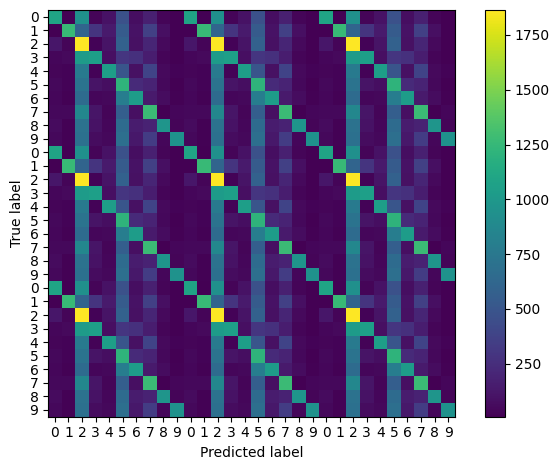

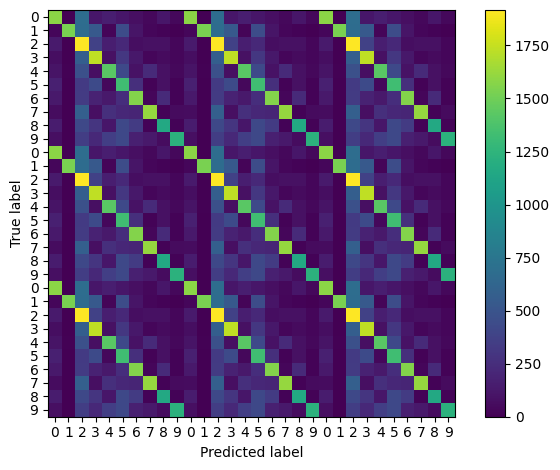

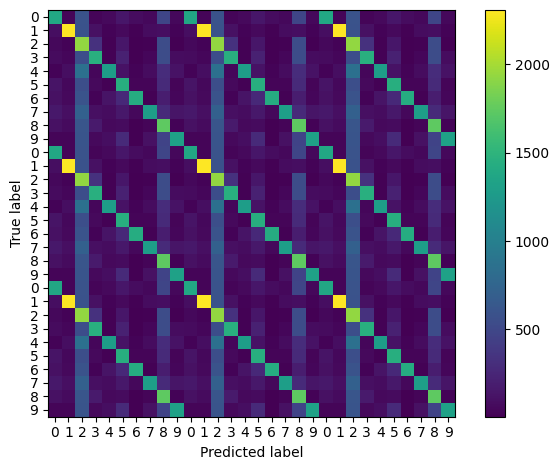

In [30]:
train_and_eval("simplecnn", "pmnist", strategy_name="ewc", epochs=10, lr=0.0005)

Saved plot: /content/drive/MyDrive/Colab Notebooks/Task3/results/simplecnn_pmnist/metrics_ewc_ep10_lr0.0005.png


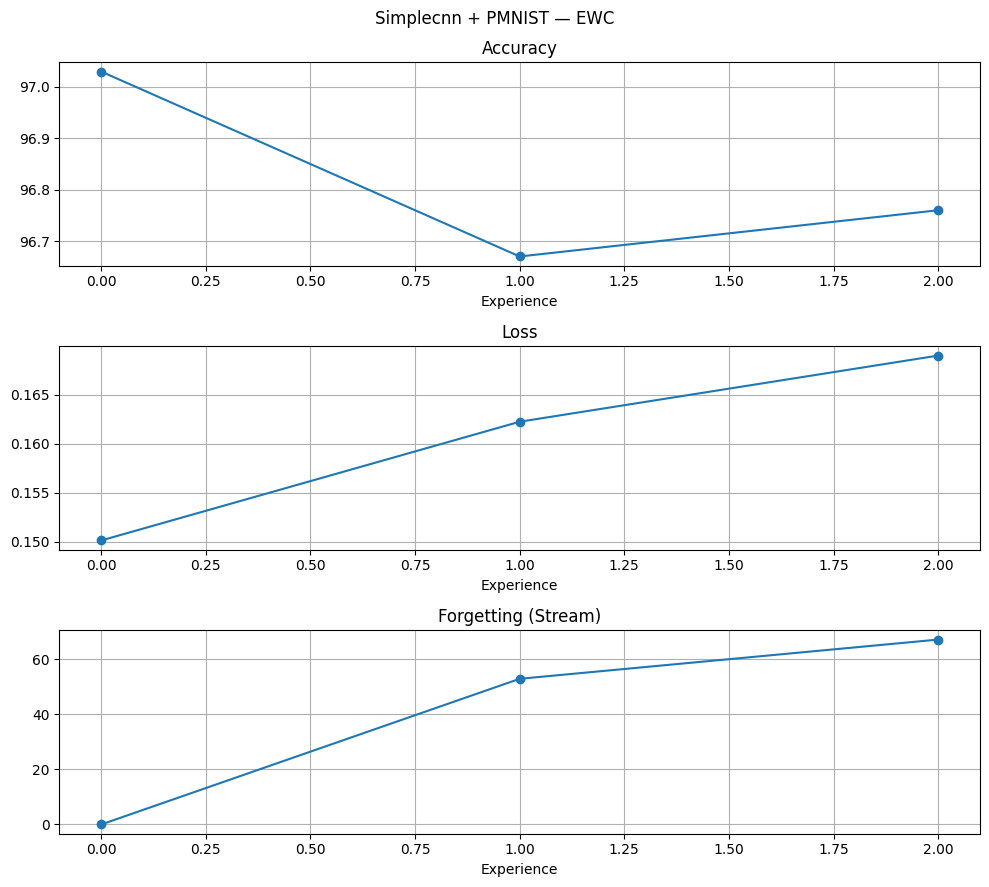

|   Experience |   Accuracy (%) |     Loss |   Stream Forgetting (%) |
|-------------:|---------------:|---------:|------------------------:|
|            0 |          97.03 | 0.150115 |                    0    |
|            1 |          96.67 | 0.162226 |                   52.96 |
|            2 |          96.76 | 0.168974 |                   67.22 |


In [31]:
plot_and_print_metrics("simplecnn", "pmnist", strategy="ewc", epochs=10, lr=0.0005)

## Cumulative

Cumulative 5 epochs


SIMPLECNN_PMNIST / Strategy: CUMULATIVE / Epochs: 5 / LR: 0.001
>>> Training on Exp 0
-- >> Start of training phase << --
100%|██████████| 1875/1875 [00:22<00:00, 82.48it/s]
Epoch 0 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 98.4304
	Loss_Epoch/train_phase/train_stream/Task000 = 0.3261
	Time_Epoch/train_phase/train_stream/Task000 = 22.7267
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.8984
100%|██████████| 1875/1875 [00:22<00:00, 82.59it/s]
Epoch 1 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 97.7164
	Loss_Epoch/train_phase/train_stream/Task000 = 0.1312
	Time_Epoch/train_phase/train_stream/Task000 = 22.6982
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.9587
100%|██████████| 1875/1875 [00:23<00:00, 81.12it/s]
Epoch 2 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 96.8193
	Loss_Epoch/train_phase/train_stream/Task000 = 0.0890
	Time_Epoch/train_phase/train_stream/Task000 = 23.1048
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.971

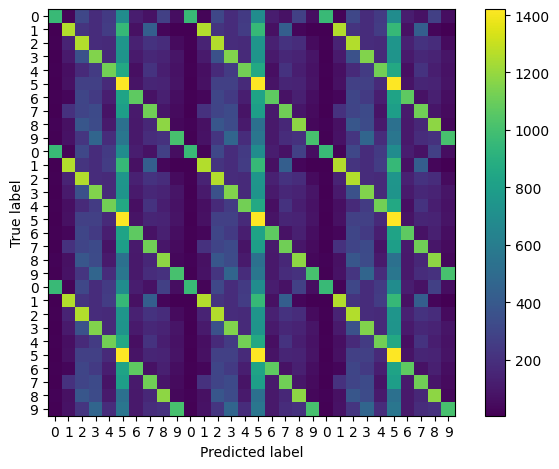

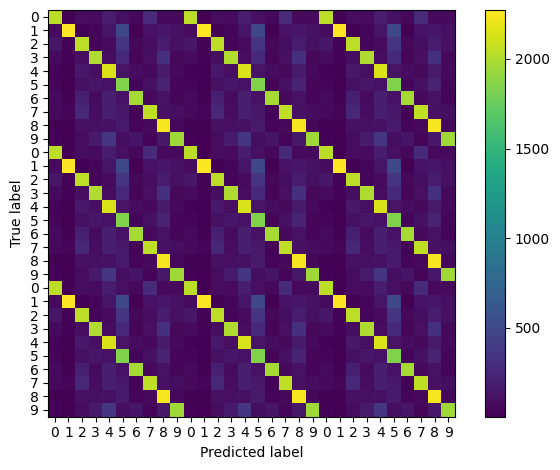

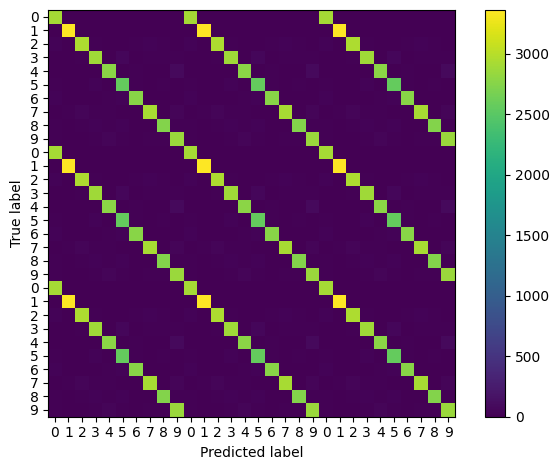

In [32]:
train_and_eval("simplecnn", "pmnist", strategy_name="cumulative", epochs=5, lr=0.001)

Saved plot: /content/drive/MyDrive/Colab Notebooks/Task3/results/simplecnn_pmnist/metrics_cumulative_ep5_lr0.001.png


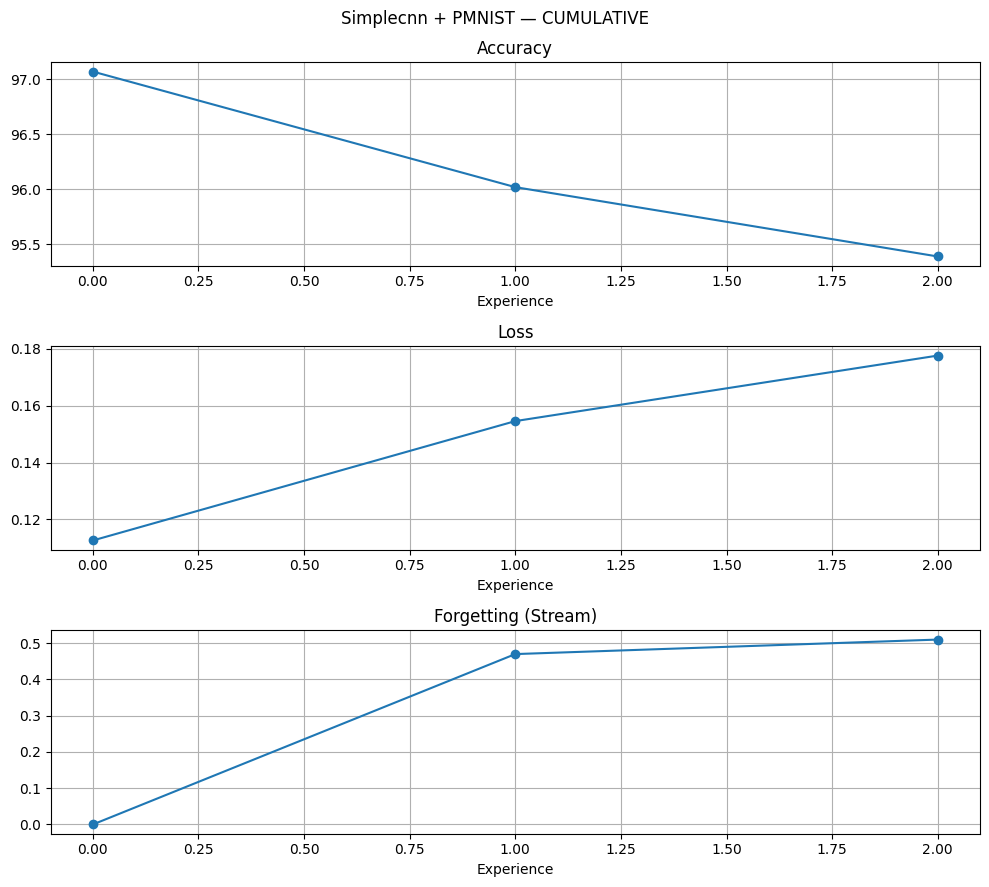

|   Experience |   Accuracy (%) |     Loss |   Stream Forgetting (%) |
|-------------:|---------------:|---------:|------------------------:|
|            0 |          97.07 | 0.112592 |                    0    |
|            1 |          96.02 | 0.154567 |                    0.47 |
|            2 |          95.39 | 0.177605 |                    0.51 |


In [33]:
plot_and_print_metrics(
    model_name="simplecnn",
    dataset_name="pmnist",
    strategy="cumulative",
    epochs=5,
    lr=0.001
)

Cumulative 10 epochs


SIMPLECNN_PMNIST / Strategy: CUMULATIVE / Epochs: 10 / LR: 0.001
>>> Training on Exp 0
-- >> Start of training phase << --
100%|██████████| 1875/1875 [00:22<00:00, 81.72it/s]
Epoch 0 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 97.1118
	Loss_Epoch/train_phase/train_stream/Task000 = 0.3197
	Time_Epoch/train_phase/train_stream/Task000 = 22.9429
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.8992
100%|██████████| 1875/1875 [00:23<00:00, 79.36it/s]
Epoch 1 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 95.6715
	Loss_Epoch/train_phase/train_stream/Task000 = 0.1295
	Time_Epoch/train_phase/train_stream/Task000 = 23.6228
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.9594
100%|██████████| 1875/1875 [00:22<00:00, 81.68it/s]
Epoch 2 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 96.6358
	Loss_Epoch/train_phase/train_stream/Task000 = 0.0867
	Time_Epoch/train_phase/train_stream/Task000 = 22.9537
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.97

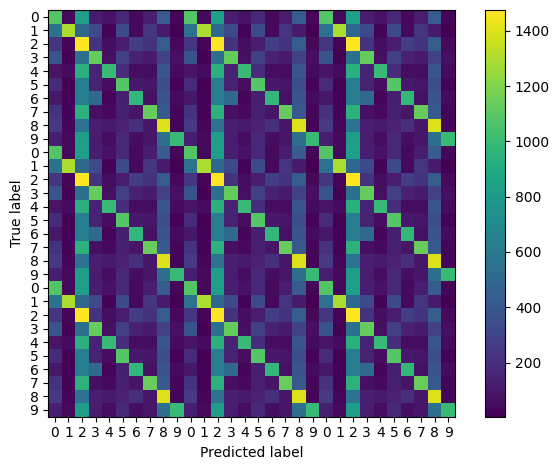

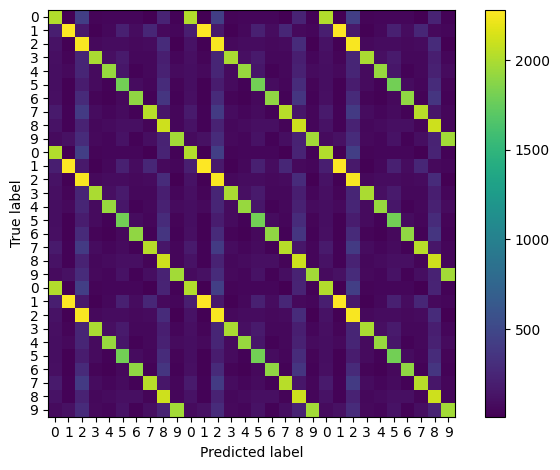

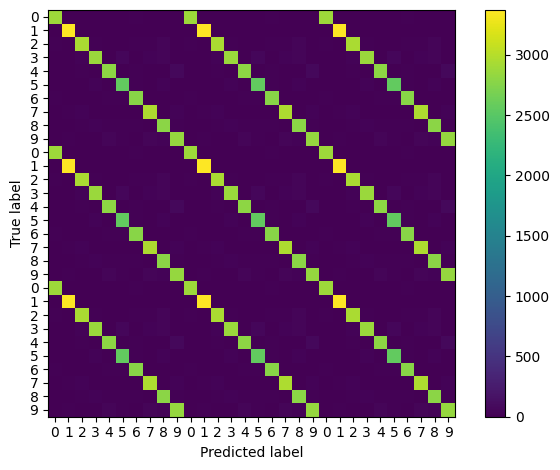

In [34]:
train_and_eval("simplecnn", "pmnist", strategy_name="cumulative", epochs=10, lr=0.001)

Saved plot: /content/drive/MyDrive/Colab Notebooks/Task3/results/simplecnn_pmnist/metrics_cumulative_ep10_lr0.001.png


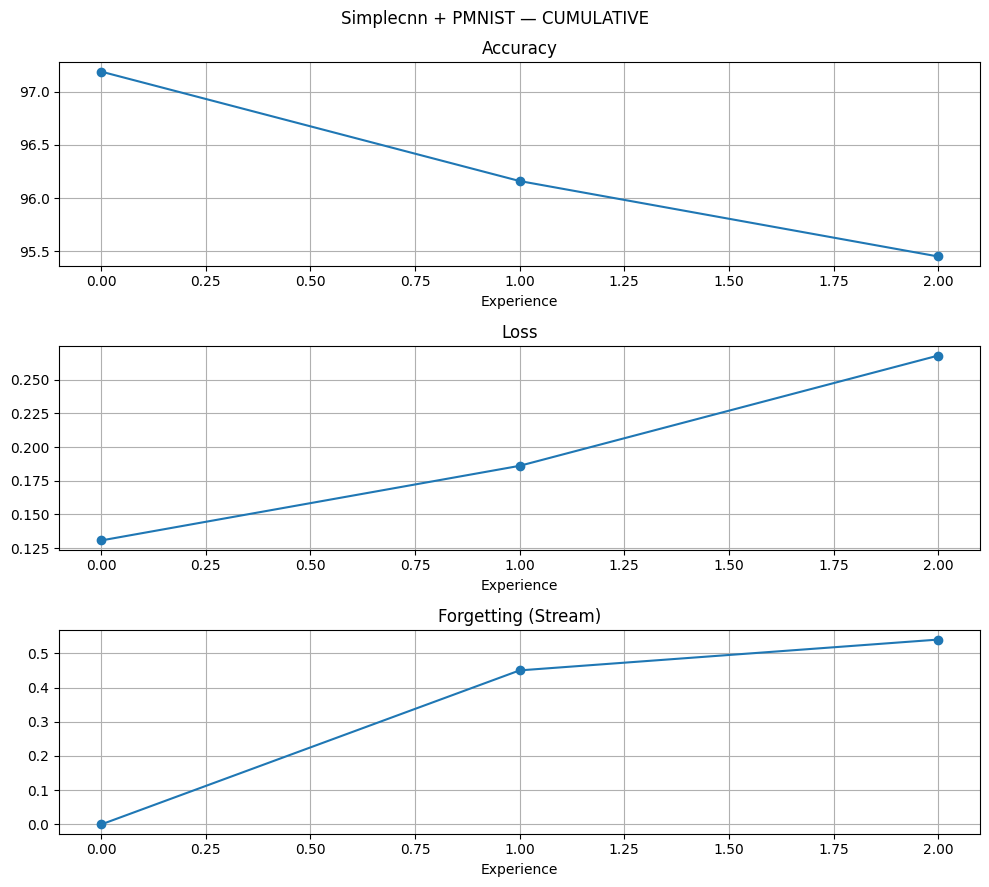

|   Experience |   Accuracy (%) |     Loss |   Stream Forgetting (%) |
|-------------:|---------------:|---------:|------------------------:|
|            0 |          97.19 | 0.130599 |                    0    |
|            1 |          96.16 | 0.186081 |                    0.45 |
|            2 |          95.45 | 0.268015 |                    0.54 |


In [35]:
plot_and_print_metrics(
    model_name="simplecnn",
    dataset_name="pmnist",
    strategy="cumulative",
    epochs=10,
    lr=0.001
)

# LeNet + SplitCIFAR10


## Naive

Naive 5 epochs

Files already downloaded and verified
Files already downloaded and verified

LENET_SPLITCIFAR10 / Strategy: NAIVE / Epochs: 5 / LR: 0.001
>>> Training on Exp 0
-- >> Start of training phase << --
100%|██████████| 313/313 [00:06<00:00, 46.81it/s]
Epoch 0 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 96.5847
	Loss_Epoch/train_phase/train_stream/Task000 = 0.5383
	Time_Epoch/train_phase/train_stream/Task000 = 6.6886
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.7462
100%|██████████| 313/313 [00:05<00:00, 53.80it/s]
Epoch 1 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 99.3253
	Loss_Epoch/train_phase/train_stream/Task000 = 0.3435
	Time_Epoch/train_phase/train_stream/Task000 = 5.8194
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.8506
100%|██████████| 313/313 [00:06<00:00, 47.10it/s]
Epoch 2 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 97.0585
	Loss_Epoch/train_phase/train_stream/Task000 = 0.2697
	Time_Epoch/train_phase/train_stream/Task000 =

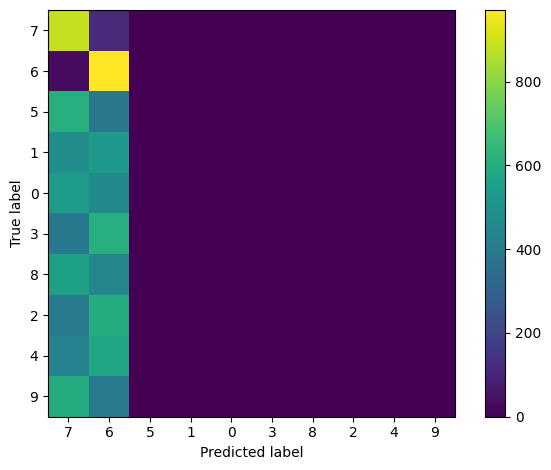

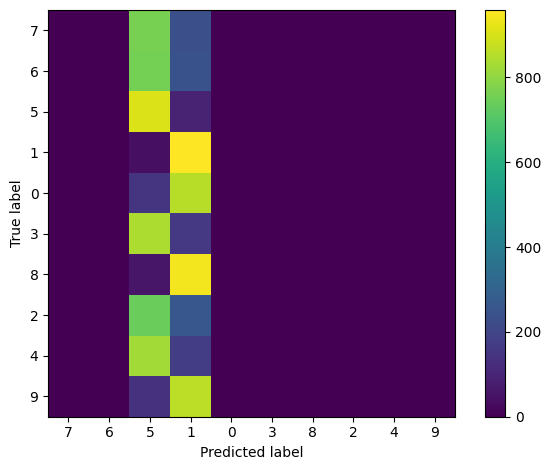

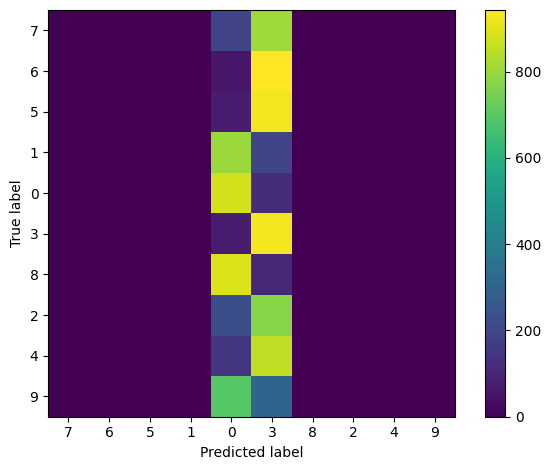

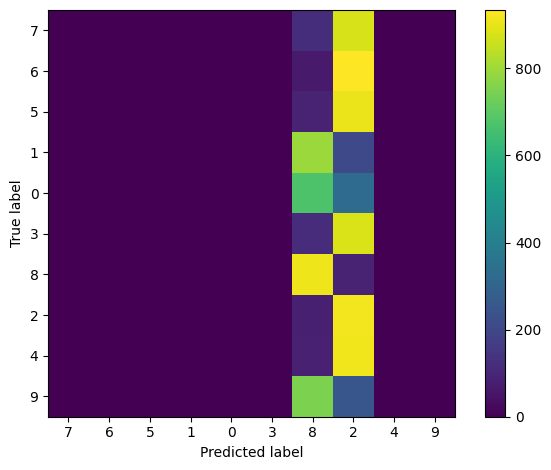

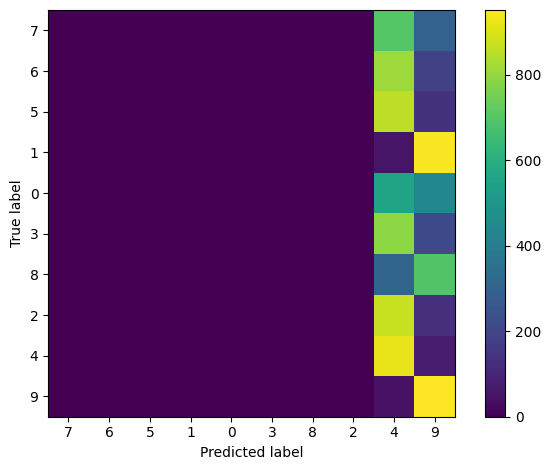

In [36]:
train_and_eval("lenet", "splitcifar10", "naive", epochs=5, lr=0.001)

Saved plot: /content/drive/MyDrive/Colab Notebooks/Task3/results/lenet_splitcifar10/metrics_naive_ep5_lr0.001.png


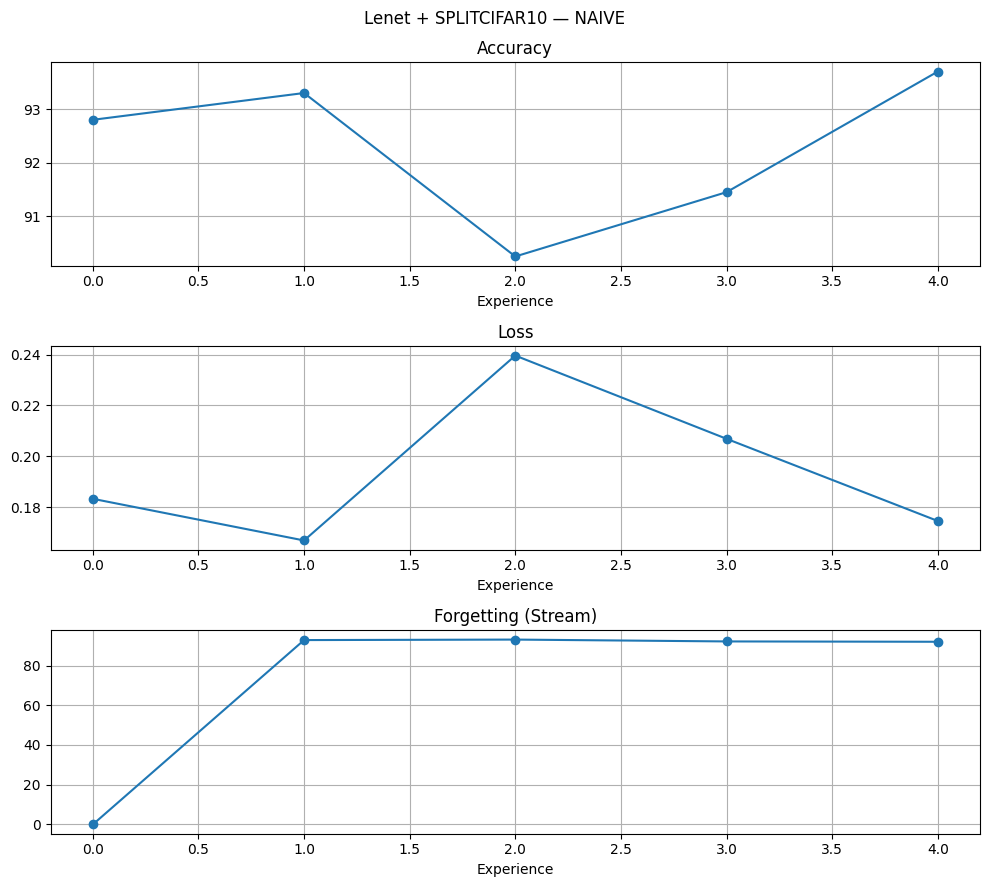

|   Experience |   Accuracy (%) |     Loss |   Stream Forgetting (%) |
|-------------:|---------------:|---------:|------------------------:|
|            0 |          92.8  | 0.183283 |                  0      |
|            1 |          93.3  | 0.166901 |                 92.8    |
|            2 |          90.25 | 0.239601 |                 93.05   |
|            3 |          91.45 | 0.206881 |                 92.1167 |
|            4 |          93.7  | 0.174576 |                 91.95   |


In [37]:
plot_and_print_metrics("lenet", "splitcifar10", "naive", epochs=5, lr=0.001)

Naive 10 epochs

Files already downloaded and verified
Files already downloaded and verified

LENET_SPLITCIFAR10 / Strategy: NAIVE / Epochs: 10 / LR: 0.001
>>> Training on Exp 0
-- >> Start of training phase << --
100%|██████████| 313/313 [00:06<00:00, 51.18it/s]
Epoch 0 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 98.4237
	Loss_Epoch/train_phase/train_stream/Task000 = 0.5724
	Time_Epoch/train_phase/train_stream/Task000 = 6.1163
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.7216
100%|██████████| 313/313 [00:06<00:00, 49.48it/s]
Epoch 1 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 97.5277
	Loss_Epoch/train_phase/train_stream/Task000 = 0.3661
	Time_Epoch/train_phase/train_stream/Task000 = 6.3267
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.8436
100%|██████████| 313/313 [00:06<00:00, 49.83it/s]
Epoch 2 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 98.3646
	Loss_Epoch/train_phase/train_stream/Task000 = 0.3043
	Time_Epoch/train_phase/train_stream/Task000 

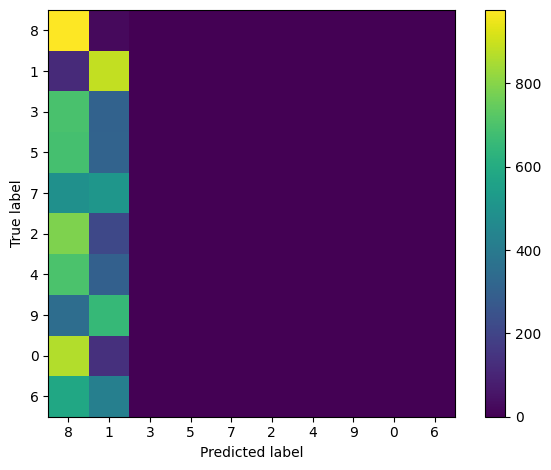

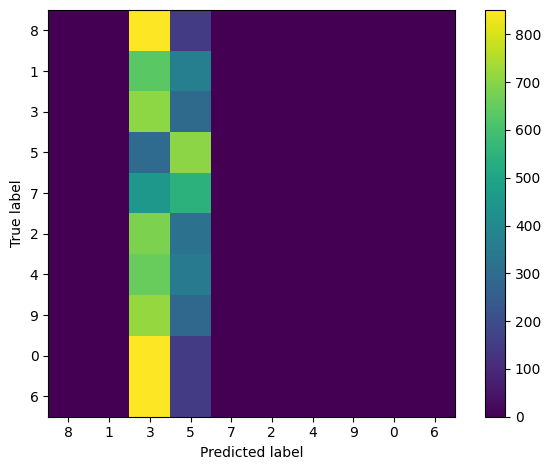

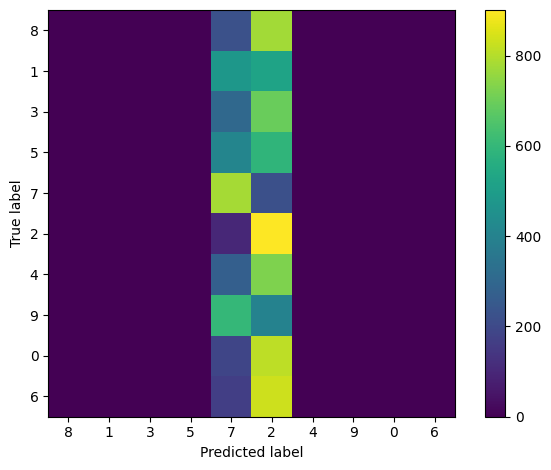

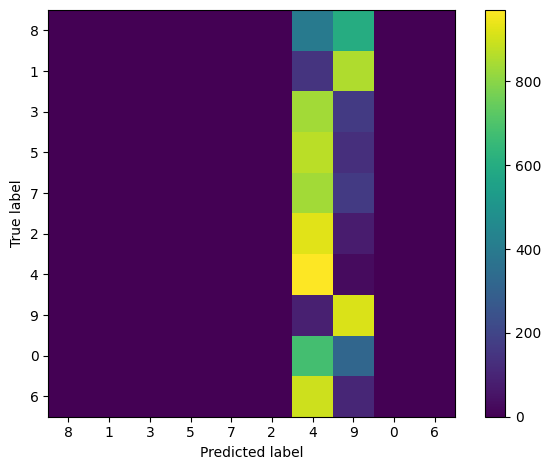

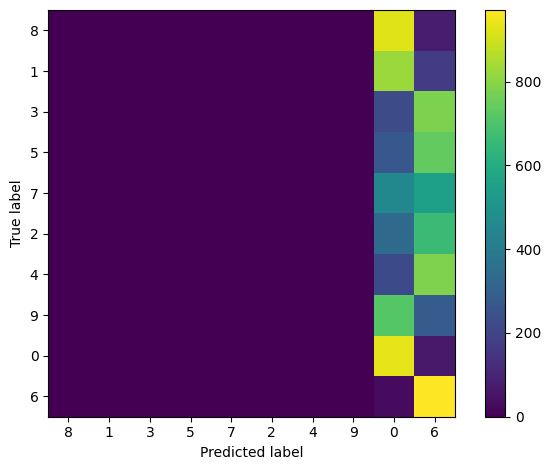

In [38]:
train_and_eval("lenet", "splitcifar10", "naive", epochs=10, lr=0.001)

Saved plot: /content/drive/MyDrive/Colab Notebooks/Task3/results/lenet_splitcifar10/metrics_naive_ep10_lr0.001.png


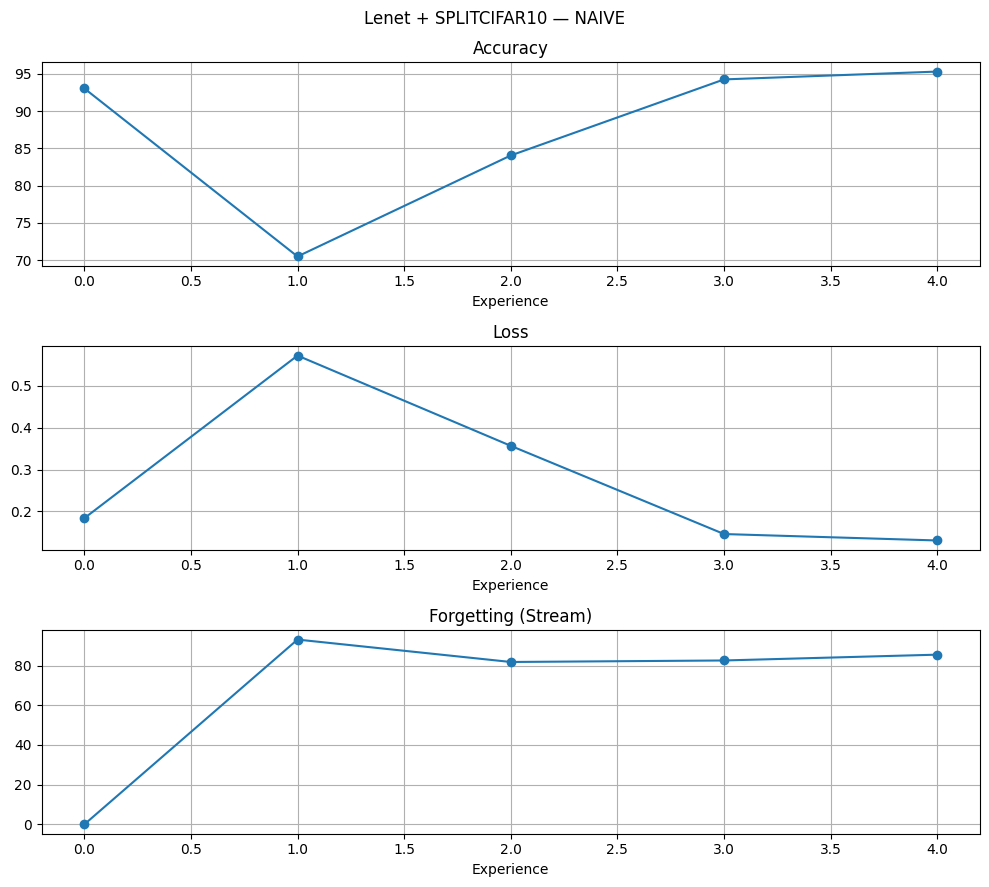

|   Experience |   Accuracy (%) |     Loss |   Stream Forgetting (%) |
|-------------:|---------------:|---------:|------------------------:|
|            0 |          93.05 | 0.183758 |                  0      |
|            1 |          70.5  | 0.572116 |                 93.05   |
|            2 |          84.05 | 0.356652 |                 81.775  |
|            3 |          94.25 | 0.146087 |                 82.5333 |
|            4 |          95.3  | 0.130739 |                 85.4625 |


In [39]:
plot_and_print_metrics("lenet", "splitcifar10", "naive", epochs=10, lr=0.001)

## EWC

EWC 5 epochs lr=0.001

Files already downloaded and verified
Files already downloaded and verified

LENET_SPLITCIFAR10 / Strategy: EWC / Epochs: 5 / LR: 0.001
>>> Training on Exp 0
-- >> Start of training phase << --
100%|██████████| 313/313 [00:06<00:00, 46.50it/s]
Epoch 0 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 95.8003
	Loss_Epoch/train_phase/train_stream/Task000 = 0.5280
	Time_Epoch/train_phase/train_stream/Task000 = 6.7327
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.7521
100%|██████████| 313/313 [00:05<00:00, 53.31it/s]
Epoch 1 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 99.0899
	Loss_Epoch/train_phase/train_stream/Task000 = 0.2859
	Time_Epoch/train_phase/train_stream/Task000 = 5.8736
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.8826
100%|██████████| 313/313 [00:06<00:00, 46.38it/s]
Epoch 2 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 96.1538
	Loss_Epoch/train_phase/train_stream/Task000 = 0.2314
	Time_Epoch/train_phase/train_stream/Task000 = 6

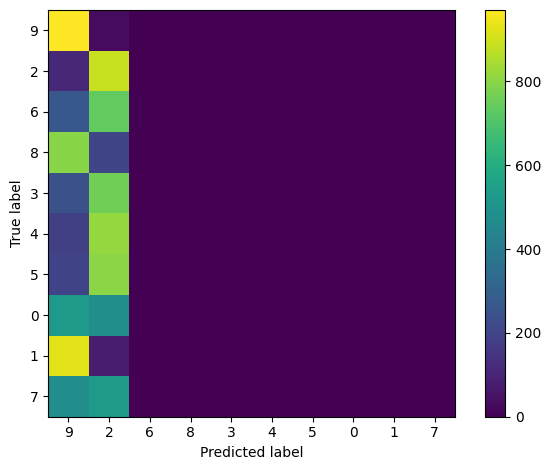

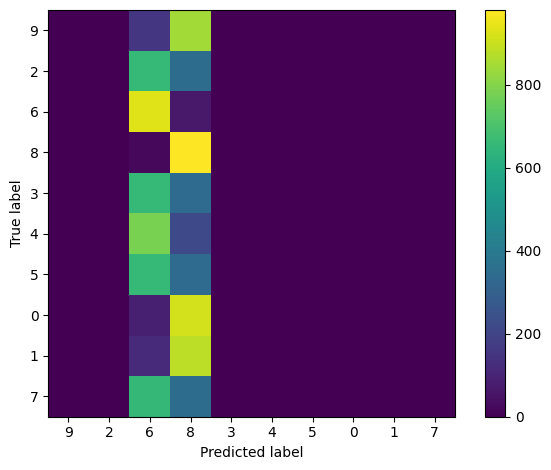

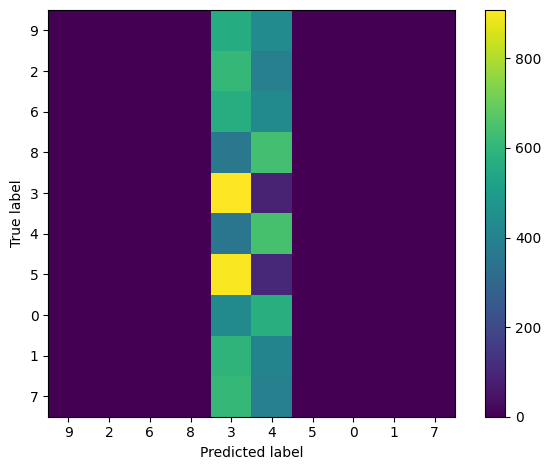

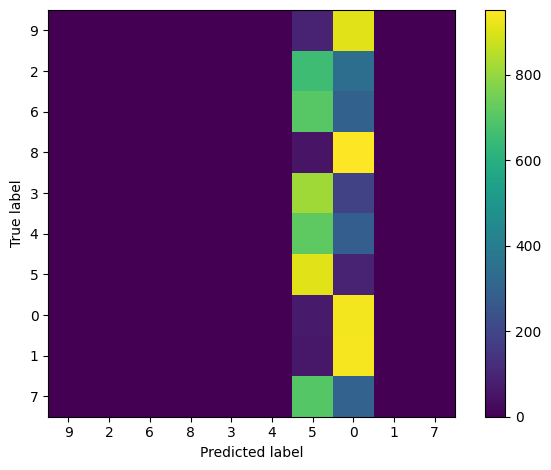

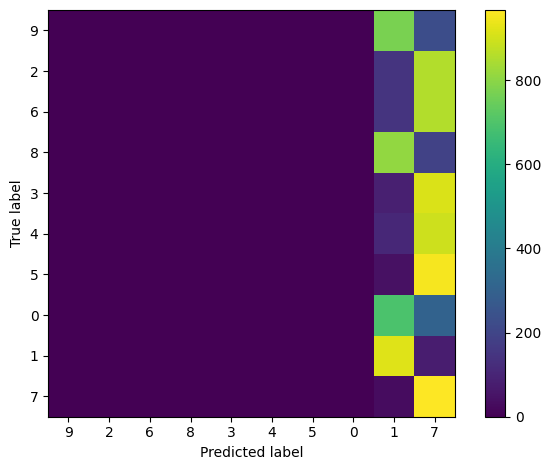

In [40]:
train_and_eval("lenet", "splitcifar10", "ewc", epochs=5, lr=0.001)

Saved plot: /content/drive/MyDrive/Colab Notebooks/Task3/results/lenet_splitcifar10/metrics_ewc_ep5_lr0.001.png


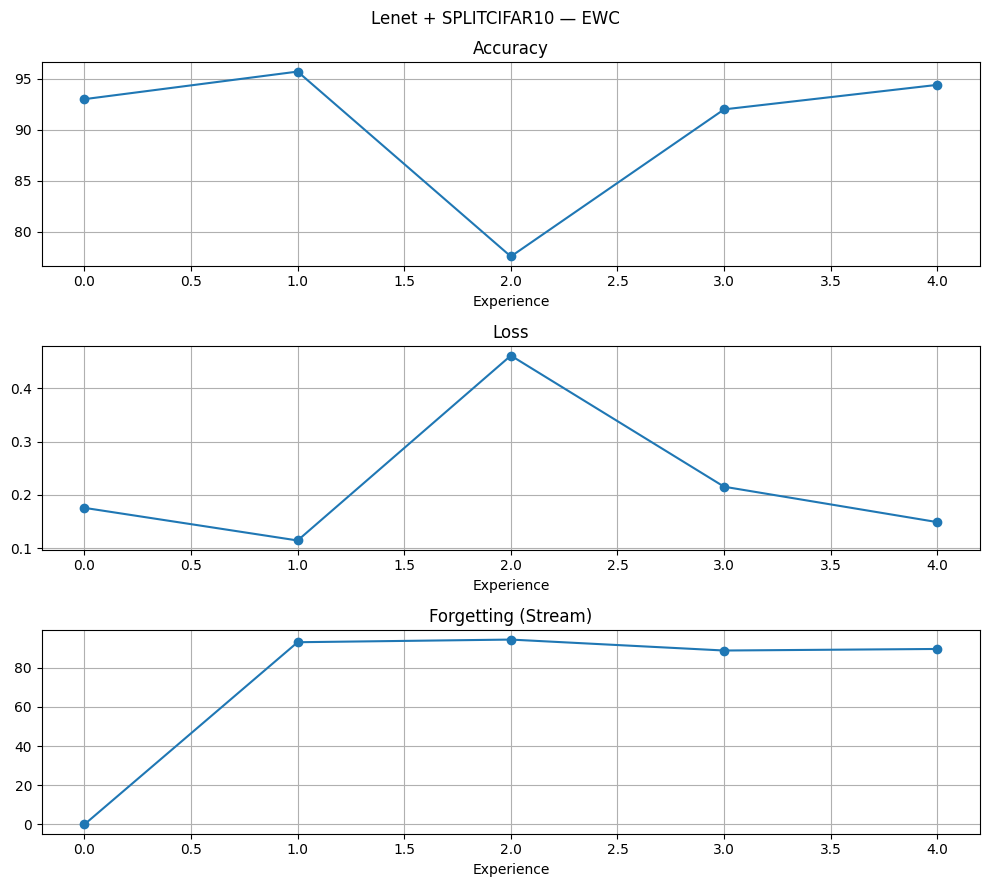

|   Experience |   Accuracy (%) |     Loss |   Stream Forgetting (%) |
|-------------:|---------------:|---------:|------------------------:|
|            0 |           93   | 0.175638 |                  0      |
|            1 |           95.7 | 0.114432 |                 93      |
|            2 |           77.6 | 0.461269 |                 94.35   |
|            3 |           92   | 0.215278 |                 88.7667 |
|            4 |           94.4 | 0.148839 |                 89.5625 |


In [41]:
plot_and_print_metrics("lenet", "splitcifar10", "ewc", epochs=5, lr=0.001)

EWC 10 epochs lr=0.001

Files already downloaded and verified
Files already downloaded and verified

LENET_SPLITCIFAR10 / Strategy: EWC / Epochs: 10 / LR: 0.001
>>> Training on Exp 0
-- >> Start of training phase << --
100%|██████████| 313/313 [00:06<00:00, 50.53it/s]
Epoch 0 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 98.4610
	Loss_Epoch/train_phase/train_stream/Task000 = 0.5459
	Time_Epoch/train_phase/train_stream/Task000 = 6.1954
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.7614
100%|██████████| 313/313 [00:06<00:00, 48.72it/s]
Epoch 1 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 96.7916
	Loss_Epoch/train_phase/train_stream/Task000 = 0.4157
	Time_Epoch/train_phase/train_stream/Task000 = 6.4262
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.8194
100%|██████████| 313/313 [00:06<00:00, 52.07it/s]
Epoch 2 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 98.8012
	Loss_Epoch/train_phase/train_stream/Task000 = 0.3769
	Time_Epoch/train_phase/train_stream/Task000 = 

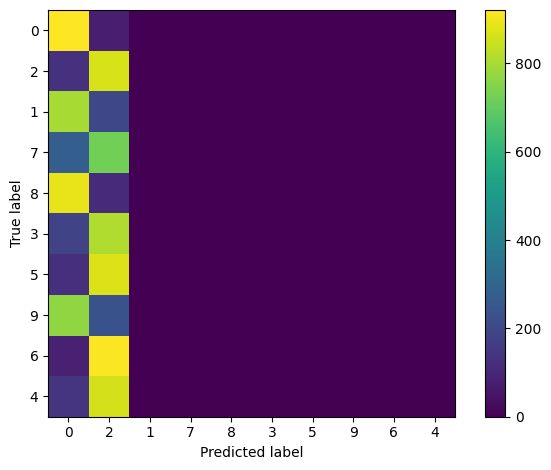

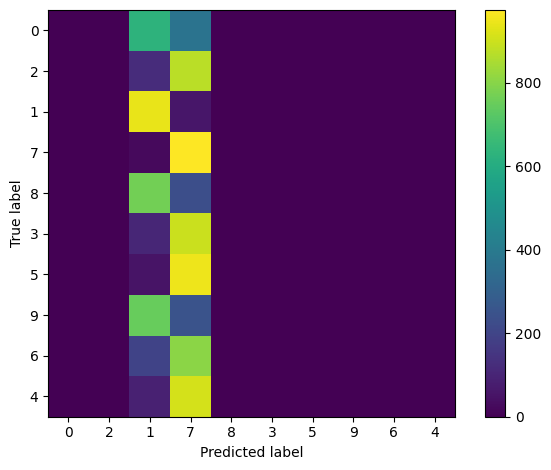

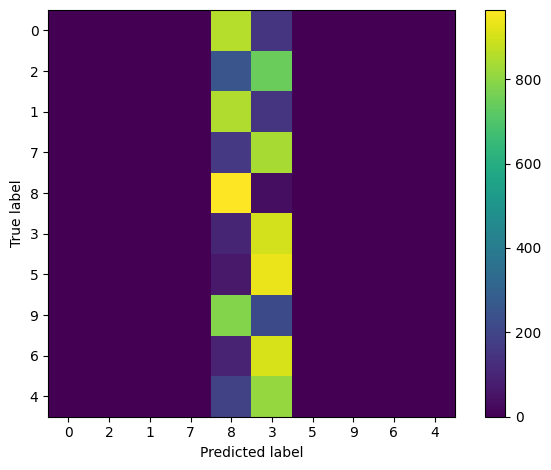

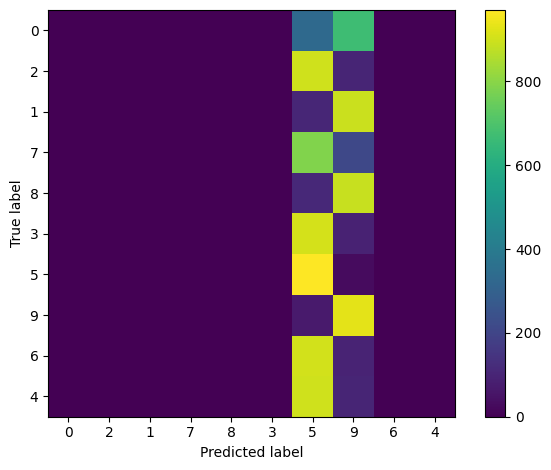

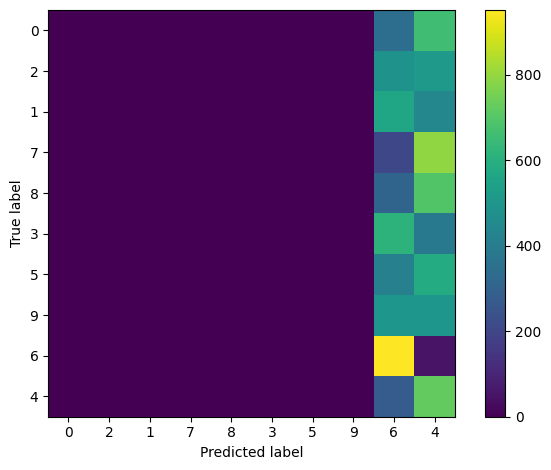

In [42]:
train_and_eval("lenet", "splitcifar10", "ewc", epochs=10, lr=0.001)

Saved plot: /content/drive/MyDrive/Colab Notebooks/Task3/results/lenet_splitcifar10/metrics_ewc_ep10_lr0.001.png


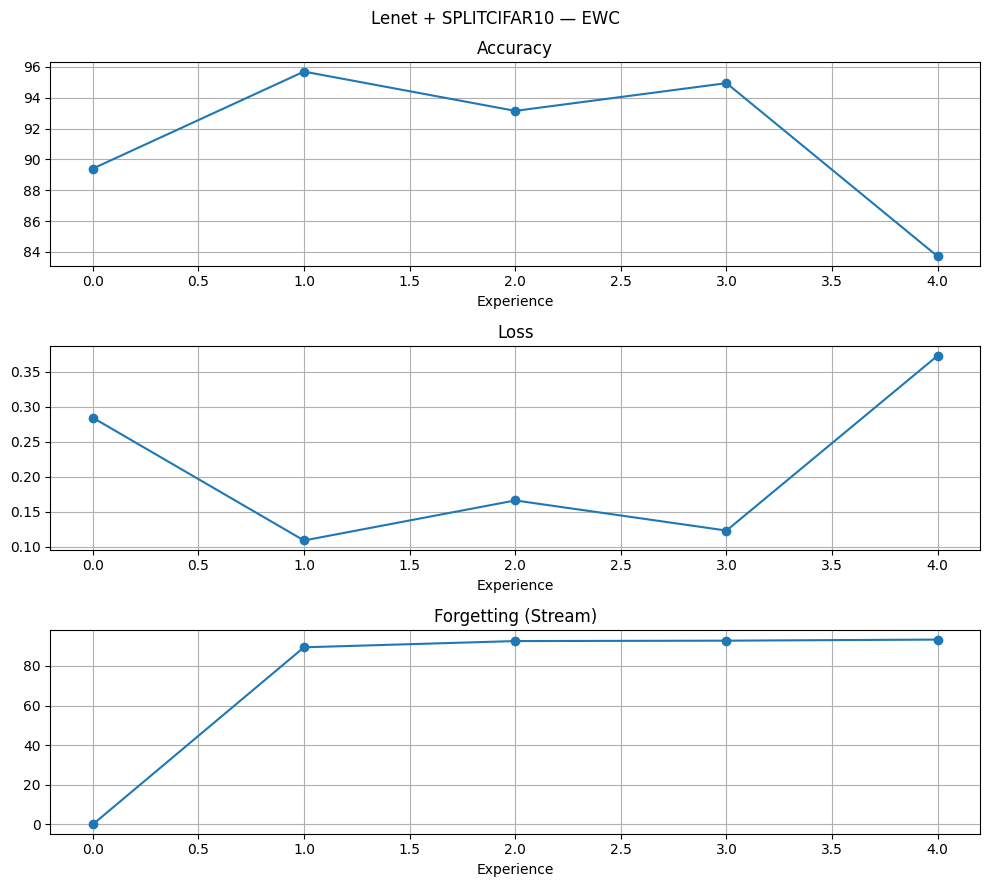

|   Experience |   Accuracy (%) |     Loss |   Stream Forgetting (%) |
|-------------:|---------------:|---------:|------------------------:|
|            0 |          89.4  | 0.284487 |                    0    |
|            1 |          95.7  | 0.109261 |                   89.4  |
|            2 |          93.15 | 0.166383 |                   92.55 |
|            3 |          94.95 | 0.123396 |                   92.75 |
|            4 |          83.7  | 0.373053 |                   93.3  |


In [43]:
plot_and_print_metrics("lenet", "splitcifar10", "ewc", epochs=10, lr=0.001)

## Cumulative

Cumulative 5 epochs

Files already downloaded and verified
Files already downloaded and verified

LENET_SPLITCIFAR10 / Strategy: CUMULATIVE / Epochs: 5 / LR: 0.001
>>> Training on Exp 0
-- >> Start of training phase << --
100%|██████████| 313/313 [00:05<00:00, 53.53it/s]
Epoch 0 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 99.0166
	Loss_Epoch/train_phase/train_stream/Task000 = 0.5406
	Time_Epoch/train_phase/train_stream/Task000 = 5.8477
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.7466
100%|██████████| 313/313 [00:06<00:00, 47.86it/s]
Epoch 1 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 96.6439
	Loss_Epoch/train_phase/train_stream/Task000 = 0.3371
	Time_Epoch/train_phase/train_stream/Task000 = 6.5393
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.8525
100%|██████████| 313/313 [00:06<00:00, 50.89it/s]
Epoch 2 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 98.9989
	Loss_Epoch/train_phase/train_stream/Task000 = 0.2667
	Time_Epoch/train_phase/train_stream/Task

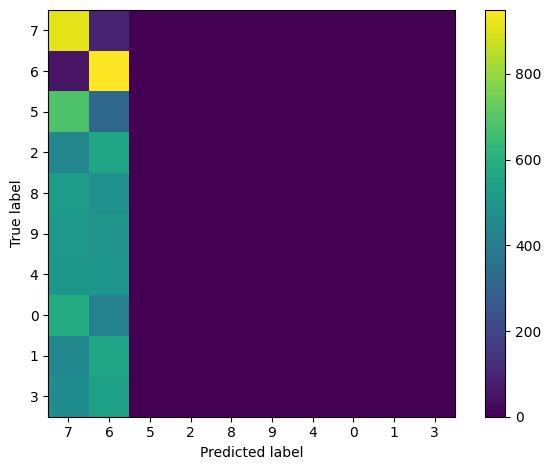

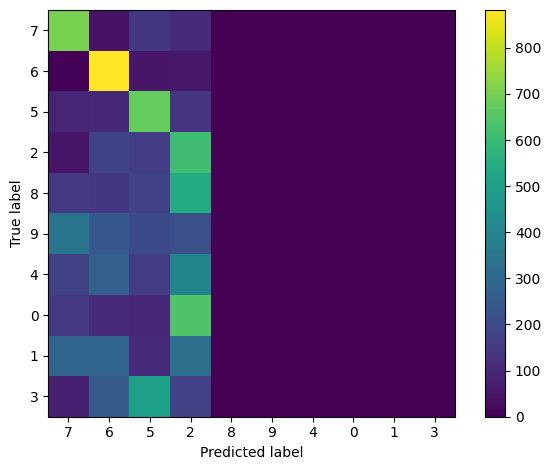

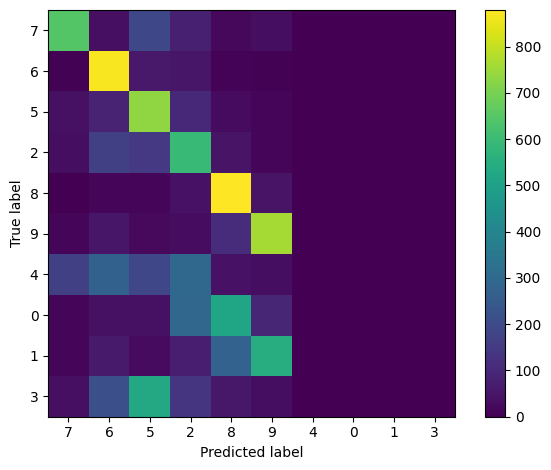

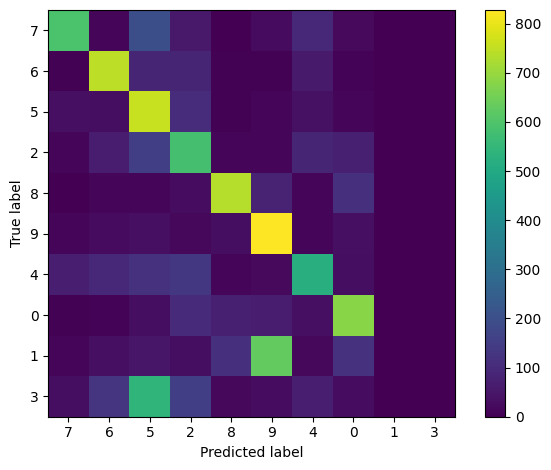

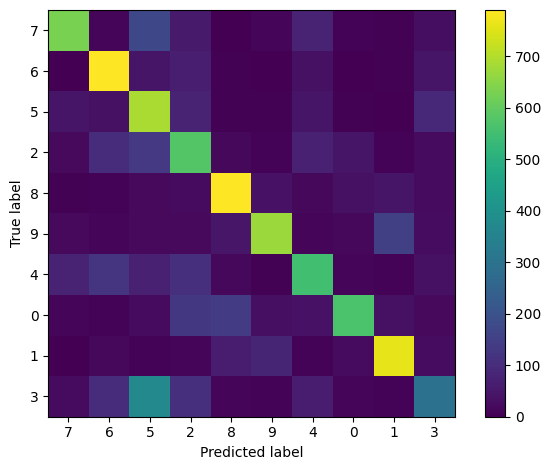

In [44]:
train_and_eval("lenet", "splitcifar10", "cumulative", epochs=5, lr=0.001)

Saved plot: /content/drive/MyDrive/Colab Notebooks/Task3/results/lenet_splitcifar10/metrics_cumulative_ep5_lr0.001.png


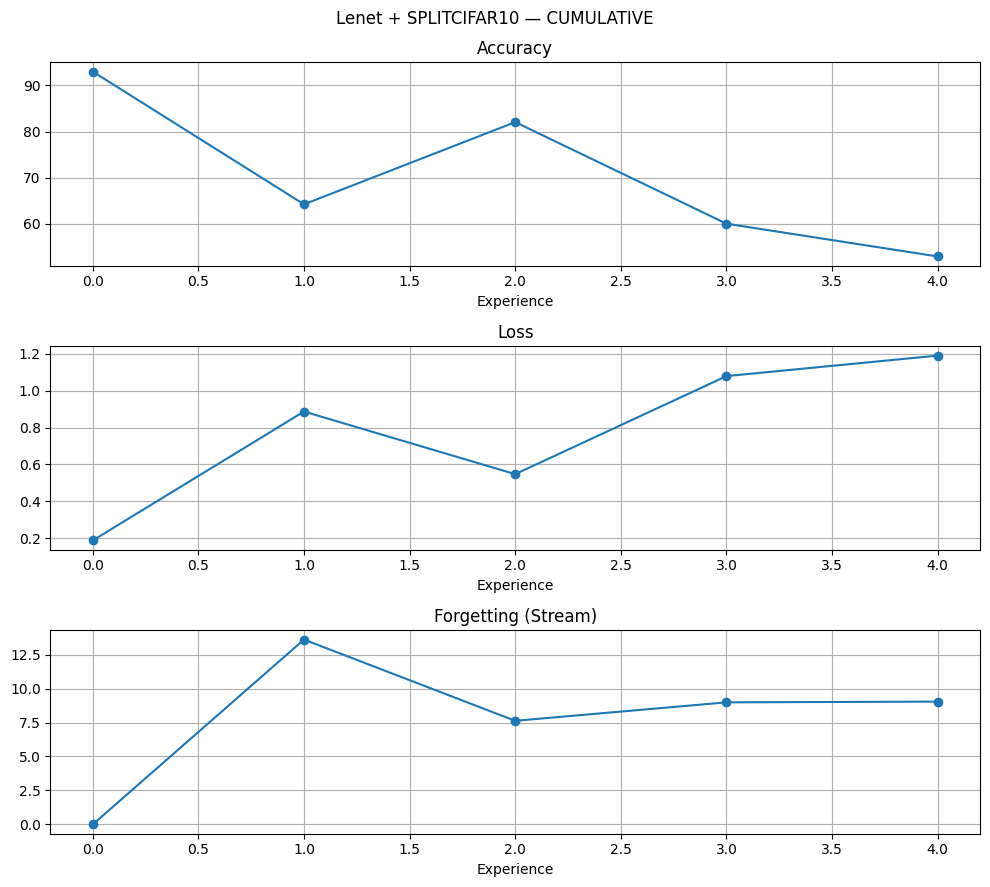

|   Experience |   Accuracy (%) |     Loss |   Stream Forgetting (%) |
|-------------:|---------------:|---------:|------------------------:|
|            0 |          93    | 0.188847 |                 0       |
|            1 |          64.25 | 0.886589 |                13.6     |
|            2 |          82.05 | 0.547698 |                 7.625   |
|            3 |          60.05 | 1.07836  |                 8.98333 |
|            4 |          52.95 | 1.18934  |                 9.0375  |


In [45]:
plot_and_print_metrics("lenet", "splitcifar10", "cumulative", epochs=5, lr=0.001)

Cumulative 7 epochs

Files already downloaded and verified
Files already downloaded and verified

LENET_SPLITCIFAR10 / Strategy: CUMULATIVE / Epochs: 7 / LR: 0.001
>>> Training on Exp 0
-- >> Start of training phase << --
100%|██████████| 313/313 [00:06<00:00, 48.02it/s]
Epoch 0 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 97.4454
	Loss_Epoch/train_phase/train_stream/Task000 = 0.5993
	Time_Epoch/train_phase/train_stream/Task000 = 6.5166
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.7014
100%|██████████| 313/313 [00:06<00:00, 50.74it/s]
Epoch 1 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 98.8819
	Loss_Epoch/train_phase/train_stream/Task000 = 0.4043
	Time_Epoch/train_phase/train_stream/Task000 = 6.1692
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.8248
100%|██████████| 313/313 [00:06<00:00, 49.55it/s]
Epoch 2 ended.
	CPUUsage_Epoch/train_phase/train_stream/Task000 = 97.8333
	Loss_Epoch/train_phase/train_stream/Task000 = 0.3327
	Time_Epoch/train_phase/train_stream/Task

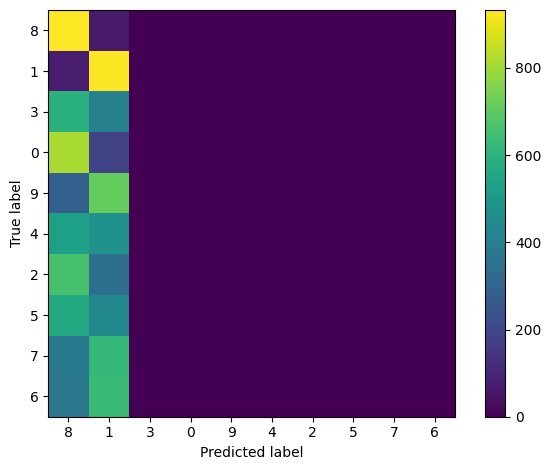

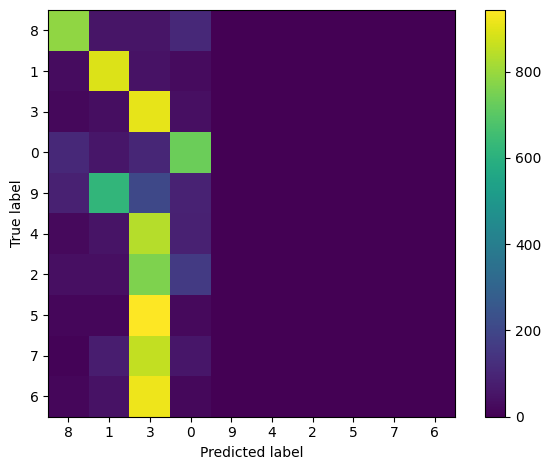

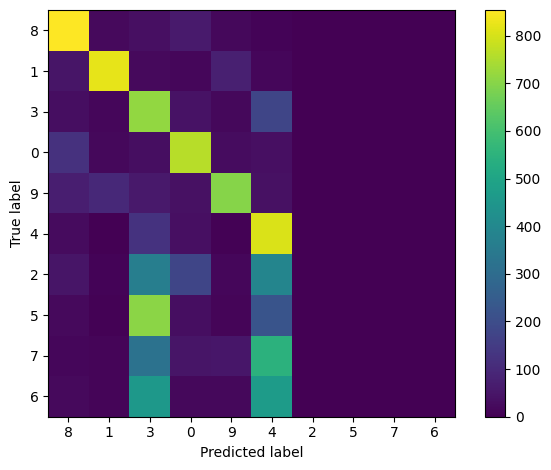

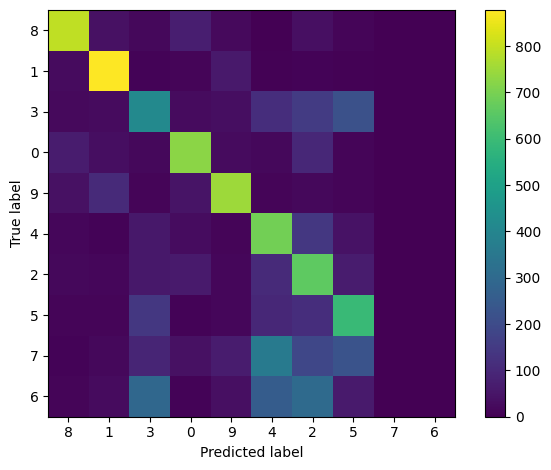

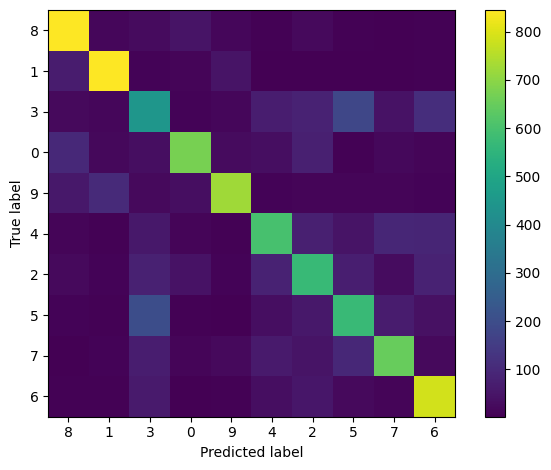

In [46]:
train_and_eval("lenet", "splitcifar10", "cumulative", epochs=7, lr=0.001)

Saved plot: /content/drive/MyDrive/Colab Notebooks/Task3/results/lenet_splitcifar10/metrics_cumulative_ep7_lr0.001.png


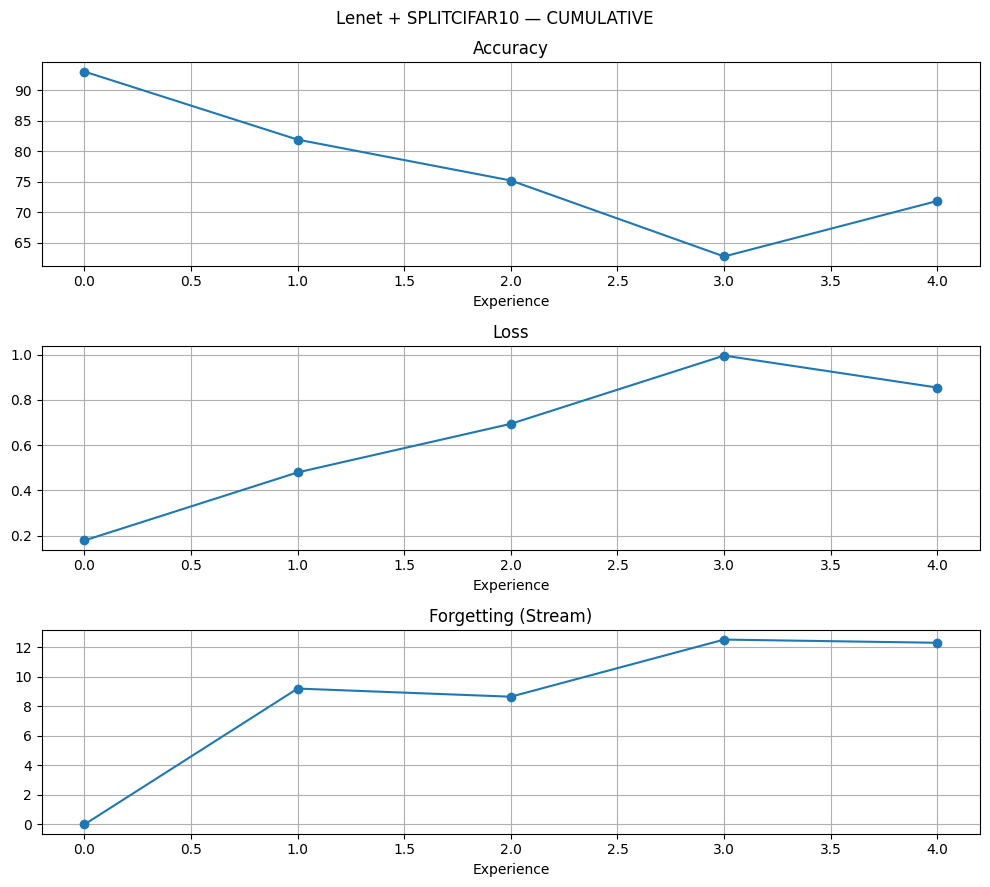

|   Experience |   Accuracy (%) |     Loss |   Stream Forgetting (%) |
|-------------:|---------------:|---------:|------------------------:|
|            0 |          93.05 | 0.178838 |                  0      |
|            1 |          81.9  | 0.47959  |                  9.2    |
|            2 |          75.2  | 0.694286 |                  8.65   |
|            3 |          62.75 | 0.995745 |                 12.5167 |
|            4 |          71.85 | 0.854389 |                 12.3    |


In [47]:
plot_and_print_metrics("lenet", "splitcifar10", "cumulative", epochs=7, lr=0.001)

# Финальный отчёт

In [228]:
def generate_best_summary_with_curves(base_dir, model_tasks, strategies):
    summary = []
    acc_plot_data, loss_plot_data, forget_plot_data = [], [], []

    for model_task in model_tasks:
        row = {"Model + Dataset": model_task}
        task_dir = os.path.join(base_dir, model_task)

        for strat in strategies:
            pattern = os.path.join(task_dir, f"results_{strat}_ep*_lr*.json")
            candidates = glob(pattern)
            best_stream_acc, best_file = -1, None

            for file in candidates:
                try:
                    with open(file) as f:
                        data = json.load(f)
                    stream_accs = [d[k] for d in data for k in d if "Top1_Acc_Stream" in k]
                    if stream_accs:
                        current_stream_acc = stream_accs[-1]
                        if current_stream_acc > best_stream_acc:
                            best_stream_acc = current_stream_acc
                            best_file = file
                except Exception as e:
                    print(f"Error processing {file}: {e}")
                    continue

            if best_file:
                with open(best_file) as f:
                    data = json.load(f)

                ep_match = re.search(r"ep(\d+)", best_file)
                lr_match = re.search(r"lr([\d.]+)", best_file)
                ep = ep_match.group(1) if ep_match else "?"
                lr = lr_match.group(1) if lr_match else "?"

                all_exp_accs = []
                all_losses = []
                all_forgets = []

                exp_accs_for_plot = []
                exp_losses_for_plot = []
                exp_forgets_for_plot = []

                for exp_data in data:
                    acc_values = [v for k,v in exp_data.items()
                                if "Top1_Acc_Exp" in k and "eval_phase" in k and "Exp" in k]
                    loss_values = [v for k,v in exp_data.items()
                                 if "Loss_Exp" in k and "eval_phase" in k and "Exp" in k]
                    forget_values = [v for k,v in exp_data.items()
                                   if "Forgetting" in k and ("Exp" in k or "Stream" in k)]

                    all_exp_accs.extend(acc_values)
                    all_losses.extend(loss_values)
                    all_forgets.extend(forget_values)

                    avg_acc = sum(acc_values)/len(acc_values) if acc_values else None
                    avg_loss = sum(loss_values)/len(loss_values) if loss_values else None
                    avg_forget = sum(forget_values)/len(forget_values) if forget_values else None

                    exp_accs_for_plot.append(avg_acc * 100 if avg_acc is not None else None)
                    exp_losses_for_plot.append(avg_loss if avg_loss is not None else None)
                    exp_forgets_for_plot.append(avg_forget * 100 if avg_forget is not None else None)

                stream_acc = best_stream_acc * 100
                mean_exp_acc = (sum(all_exp_accs)/len(all_exp_accs)) * 100 if all_exp_accs else 0
                mean_loss = sum(all_losses)/len(all_losses) if all_losses else float('nan')
                mean_forget = (sum(all_forgets)/len(all_forgets)) * 100 if all_forgets else float('nan')

                row[strat] = f"{stream_acc:.2f}%/{mean_exp_acc:.2f}% (ep:{ep},lr:{lr})"

                label = f"{model_task.replace('_', ' ').title()} ({strat})"
                acc_plot_data.append((label, exp_accs_for_plot))
                loss_plot_data.append((label, exp_losses_for_plot))
                forget_plot_data.append((label, exp_forgets_for_plot))
            else:
                row[strat] = "-"

        summary.append(row)

    print("\n Финальный отчёт (Stream Accuracy / Mean Exp Accuracy):")
    print(tabulate(summary, headers="keys", tablefmt="github"))

    def plot_metric(title, data, ylabel):
        plt.figure(figsize=(12, 6))
        for label, values in data:
            clean_values = [v for v in values if v is not None]
            if clean_values:
                plt.plot(range(len(clean_values)), clean_values,
                        marker='o', linestyle='-', label=label)
        plt.title(title)
        plt.xlabel("Experience")
        plt.ylabel(ylabel)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    plot_metric("Top1 Accuracy (%) по Experience", acc_plot_data, "Accuracy (%)")
    plot_metric("Loss по Experience", loss_plot_data, "Loss")
    plot_metric("Forgetting (%) по Experience", forget_plot_data, "Forgetting (%)")

In [229]:
def plot_best_curves_for_pair(base_dir, model, dataset, strategies):
    key = f"{model}_{dataset}"
    title_base = f"{model.upper()} + {dataset.upper()}"
    task_dir = os.path.join(base_dir, key)

    acc_data, loss_data, forget_data = [], [], []
    summary_rows = []

    for strat in strategies:
        pattern = os.path.join(task_dir, f"results_{strat}_ep*_lr*.json")
        candidates = glob(pattern)
        best_file = None
        best_stream_acc = -1

        for file in candidates:
            try:
                with open(file) as f:
                    data = json.load(f)
                stream_accs = [d[k] for d in data for k in d if "Top1_Acc_Stream" in k]
                if stream_accs:
                    current_acc = stream_accs[-1]
                    if current_acc > best_stream_acc:
                        best_stream_acc = current_acc
                        best_file = file
            except Exception as e:
                print(f"Ошибка в файле {file}: {e}")
                continue

        if best_file:
            with open(best_file) as f:
                data = json.load(f)

            ep_match = re.search(r"ep(\d+)", best_file)
            lr_match = re.search(r"lr([\d.]+)", best_file)
            ep = ep_match.group(1) if ep_match else "?"
            lr = lr_match.group(1) if lr_match else "?"
            label = f"{strat.upper()} (ep:{ep},lr:{lr})"

            accs, losses, forgets = [], [], []
            all_exp_accs, all_losses, all_forgets = [], [], []

            for d in data:
                exp_acc_vals = [v for k, v in d.items() if "Top1_Acc_Exp" in k and "test_stream" in k]
                acc = sum(exp_acc_vals) / len(exp_acc_vals) if exp_acc_vals else None

                loss_vals = [v for k, v in d.items() if "Loss_Exp" in k and "test_stream" in k]
                loss = sum(loss_vals) / len(loss_vals) if loss_vals else None

                forget_vals = [v for k, v in d.items() if "Forgetting" in k and "test_stream" in k]
                forget = sum(forget_vals) / len(forget_vals) if forget_vals else None

                accs.append(acc * 100 if acc is not None else None)
                losses.append(loss if loss is not None else None)
                forgets.append(forget * 100 if forget is not None else None)

                all_exp_accs.extend(exp_acc_vals)
                all_losses.extend(loss_vals)
                all_forgets.extend(forget_vals)

            acc_data.append((label, accs))
            loss_data.append((label, losses))
            forget_data.append((label, forgets))

            mean_acc = (sum(all_exp_accs)/len(all_exp_accs)) * 100 if all_exp_accs else 0
            mean_loss = sum(all_losses)/len(all_losses) if all_losses else float('nan')
            mean_forget = (sum(all_forgets)/len(all_forgets)) * 100 if all_forgets else float('nan')

            summary_rows.append({
                "Strategy": strat.upper(),
                "Params": f"ep:{ep},lr:{lr}",
                "Stream Acc (%)": f"{best_stream_acc*100:.2f}",
                "Mean Exp Acc (%)": f"{mean_acc:.2f}",
                "Mean Loss": f"{mean_loss:.4f}",
                "Mean Forgetting (%)": f"{mean_forget:.2f}"
            })

    def plot_metric(title, data, ylabel, filename):
        plt.figure(figsize=(10, 5))
        for label, values in data:
            if any(v is not None for v in values):
                plt.plot(range(len(values)), values, marker='o', label=label)
        plt.title(f"{title_base} — {title}")
        plt.xlabel("Experience")
        plt.ylabel(ylabel)
        plt.legend(loc='best')
        plt.grid(True)
        plt.tight_layout()
        os.makedirs(task_dir, exist_ok=True)
        plt.savefig(os.path.join(task_dir, f"{filename}.png"))
        plt.show()

    plot_metric("Top1 Accuracy (%)", acc_data, "Accuracy (%)", "accuracy")
    plot_metric("Loss", loss_data, "Loss", "loss")
    plot_metric("Forgetting (%)", forget_data, "Forgetting (%)", "forgetting")

    print(f"\n Средние метрики для {title_base}:")
    df = pd.DataFrame(summary_rows)
    print(df.to_markdown(index=False, tablefmt="github"))

In [230]:
model_tasks = [
    "lenet_splitcifar10",
    "lenet_pmnist",
    "simplecnn_pmnist"
]
pairs = [
    ("lenet", "splitcifar10"),
    ("lenet", "pmnist"),
    ("simplecnn", "pmnist")
]
strategies = ["naive", "ewc", "cumulative"]

In [231]:
start_path = "/content/drive/MyDrive"
base_dir = start_path+"/Colab Notebooks/Task3/results"

## Общий график (все пары - все стратегии(для каждой стратегии выбран лучший результат подбора эпох и лр))


 Финальный отчёт (Stream Accuracy / Mean Exp Accuracy):
| Model + Dataset    | naive                           | ewc                             | cumulative                      |
|--------------------|---------------------------------|---------------------------------|---------------------------------|
| lenet_splitcifar10 | 19.06%/17.49% (ep:10,lr:0.001.) | 18.89%/18.11% (ep:5,lr:0.001.)  | 67.11%/44.10% (ep:7,lr:0.001.)  |
| lenet_pmnist       | 43.87%/40.95% (ep:10,lr:0.001.) | 44.77%/41.72% (ep:5,lr:0.001.)  | 93.75%/66.03% (ep:5,lr:0.001.)  |
| simplecnn_pmnist   | 46.92%/43.80% (ep:5,lr:0.001.)  | 56.14%/50.61% (ep:5,lr:0.0005.) | 95.91%/67.35% (ep:10,lr:0.001.) |


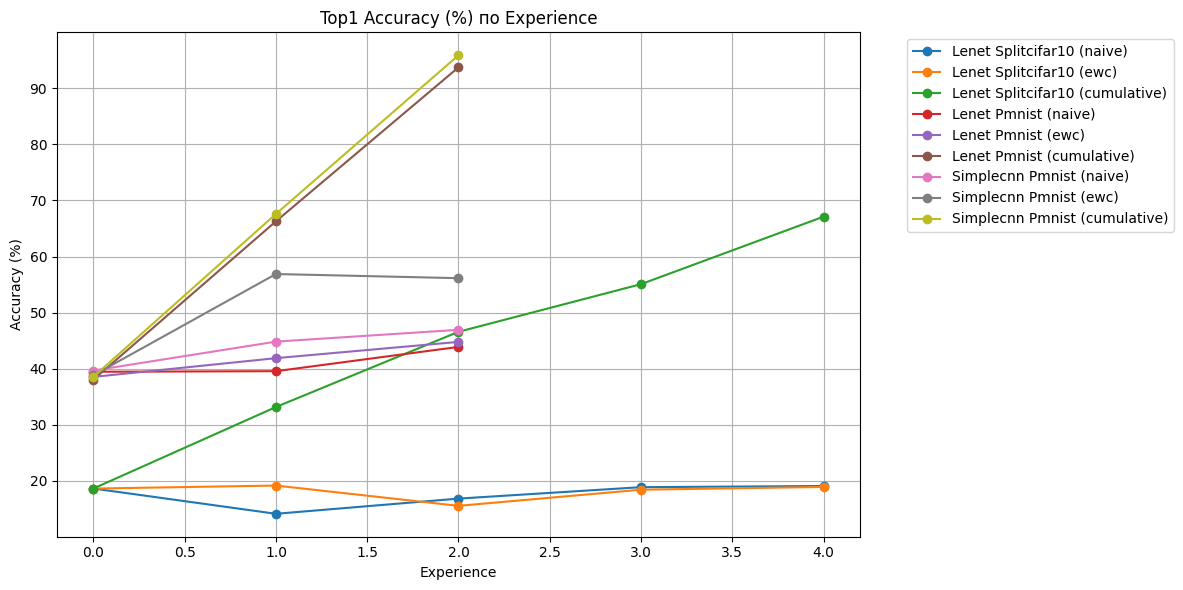

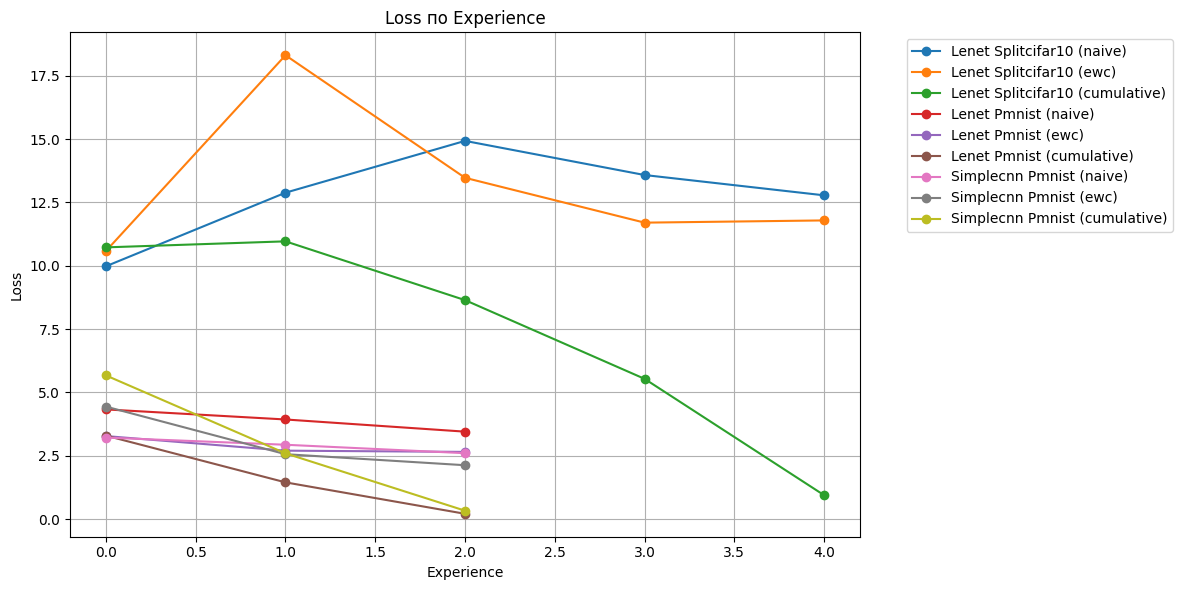

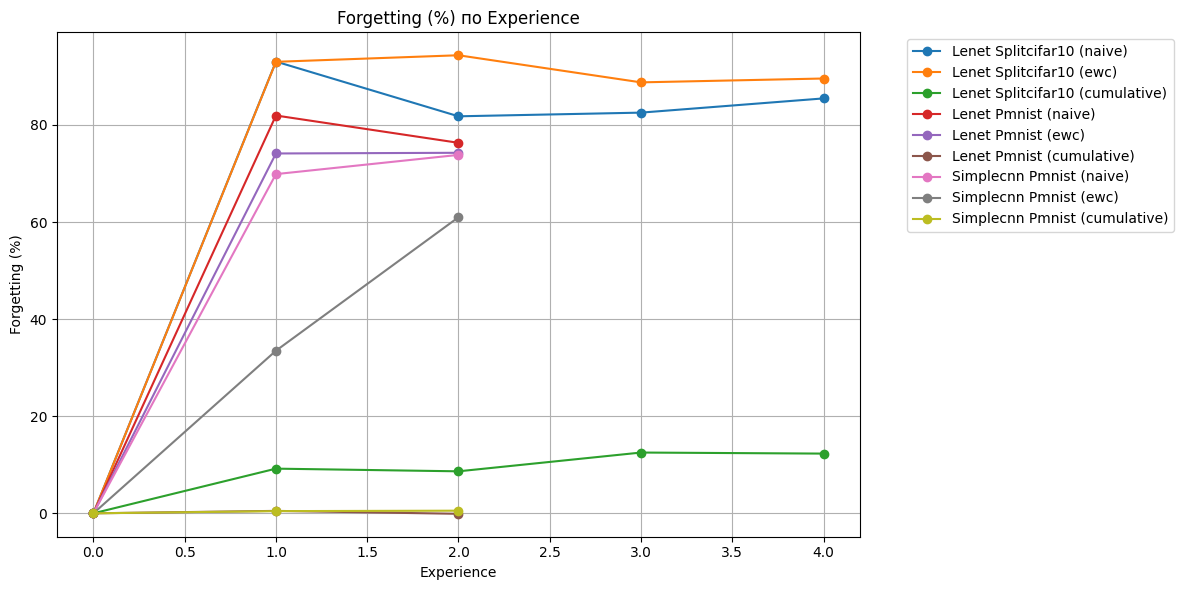

In [232]:
generate_best_summary_with_curves(base_dir, model_tasks, strategies)

## Сравнение стратегий для каждой из пар датасет+модель


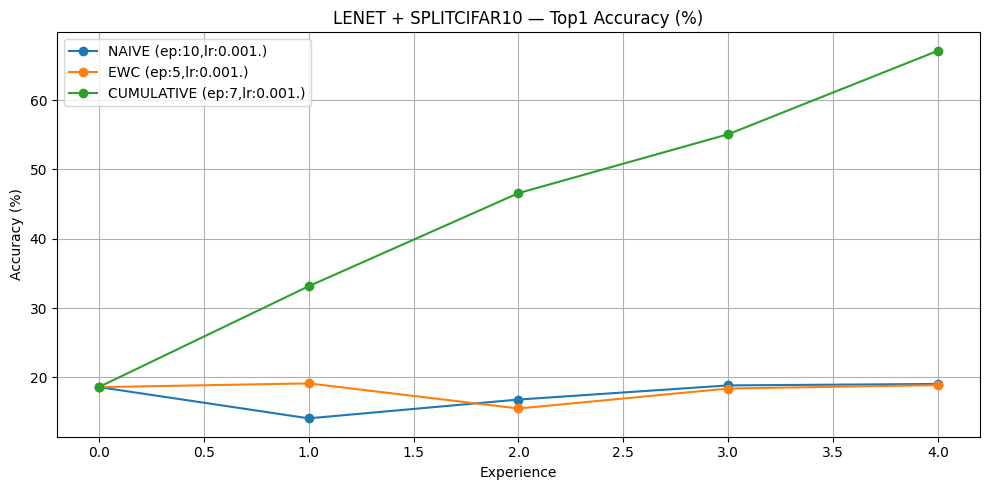

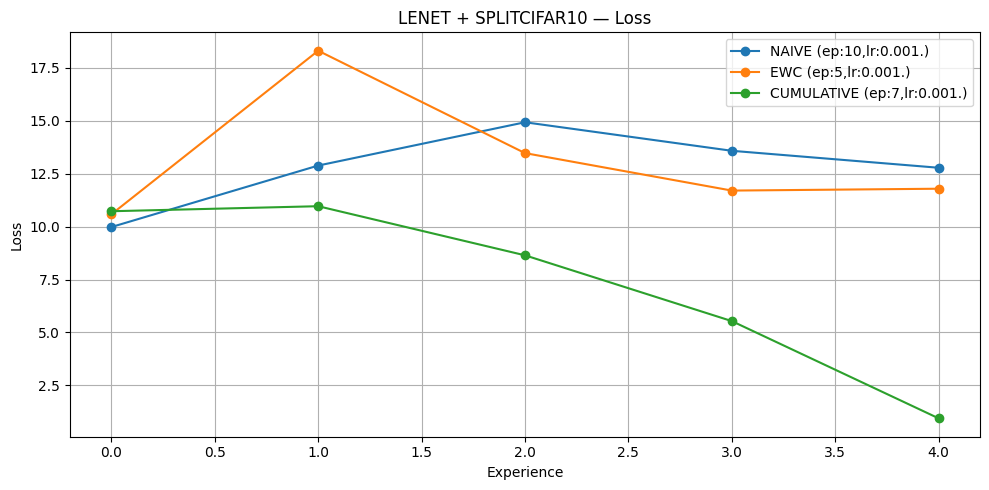

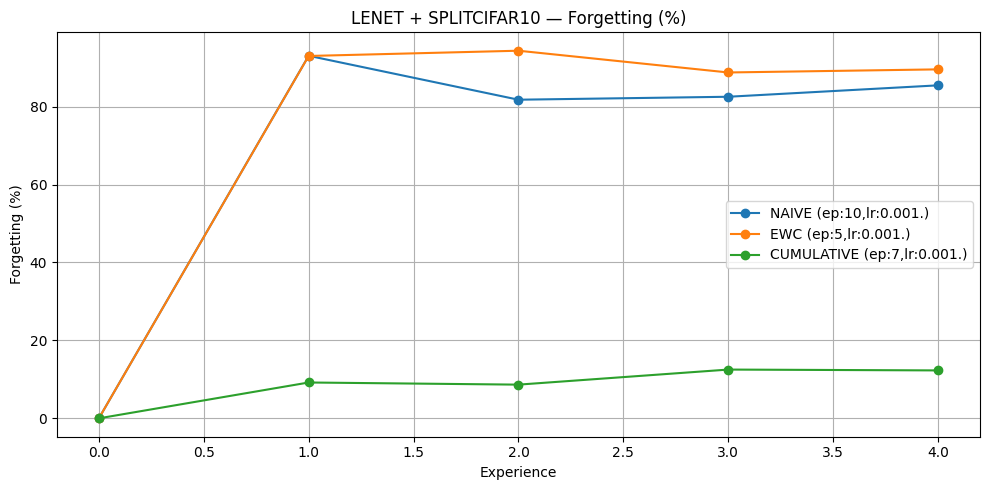


 Средние метрики для LENET + SPLITCIFAR10:
| Strategy   | Params          |   Stream Acc (%) |   Mean Exp Acc (%) |   Mean Loss |   Mean Forgetting (%) |
|------------|-----------------|------------------|--------------------|-------------|-----------------------|
| NAIVE      | ep:10,lr:0.001. |            19.06 |              17.49 |     12.83   |                 79.26 |
| EWC        | ep:5,lr:0.001.  |            18.89 |              18.11 |     13.1702 |                 84.8  |
| CUMULATIVE | ep:7,lr:0.001.  |            67.11 |              44.1  |      7.3621 |                 10.39 |


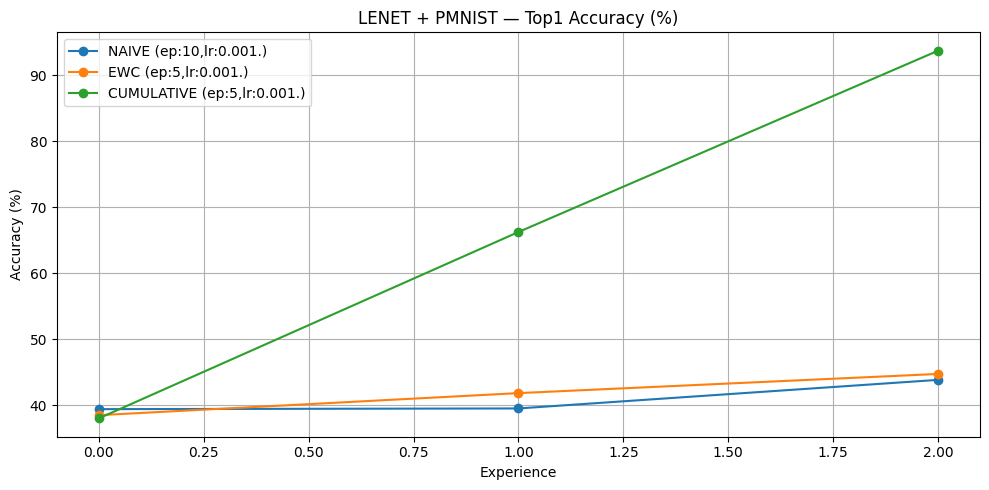

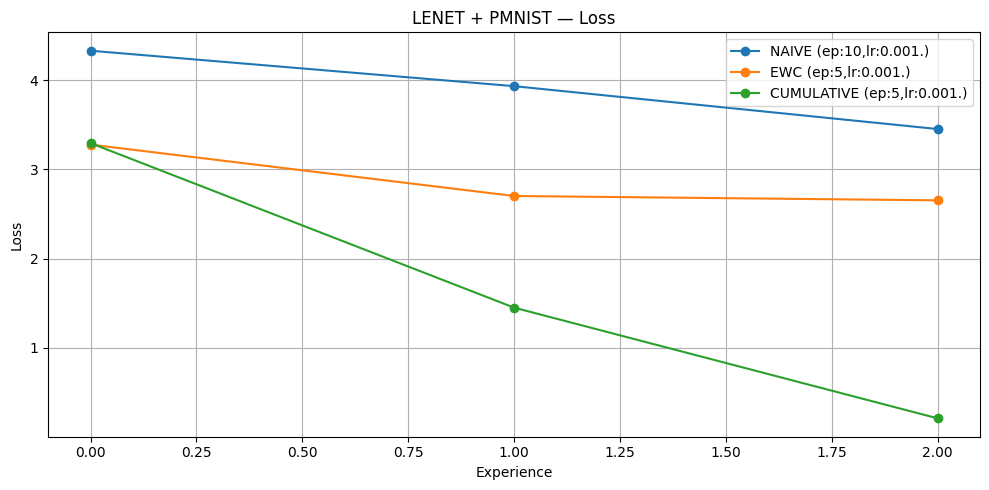

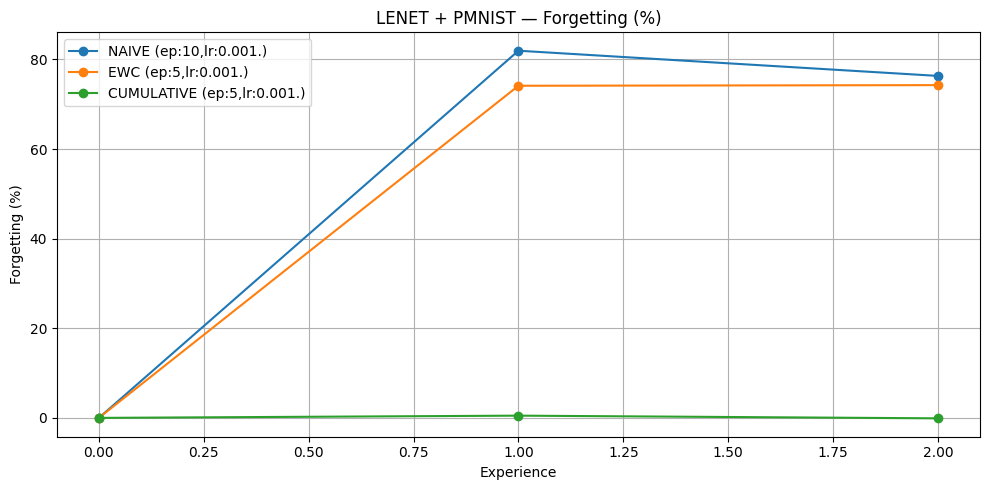


 Средние метрики для LENET + PMNIST:
| Strategy   | Params          |   Stream Acc (%) |   Mean Exp Acc (%) |   Mean Loss |   Mean Forgetting (%) |
|------------|-----------------|------------------|--------------------|-------------|-----------------------|
| NAIVE      | ep:10,lr:0.001. |            43.87 |              40.95 |      3.9045 |                 65.47 |
| EWC        | ep:5,lr:0.001.  |            44.77 |              41.72 |      2.8771 |                 61.84 |
| CUMULATIVE | ep:5,lr:0.001.  |            93.75 |              66.03 |      1.6512 |                  0.12 |


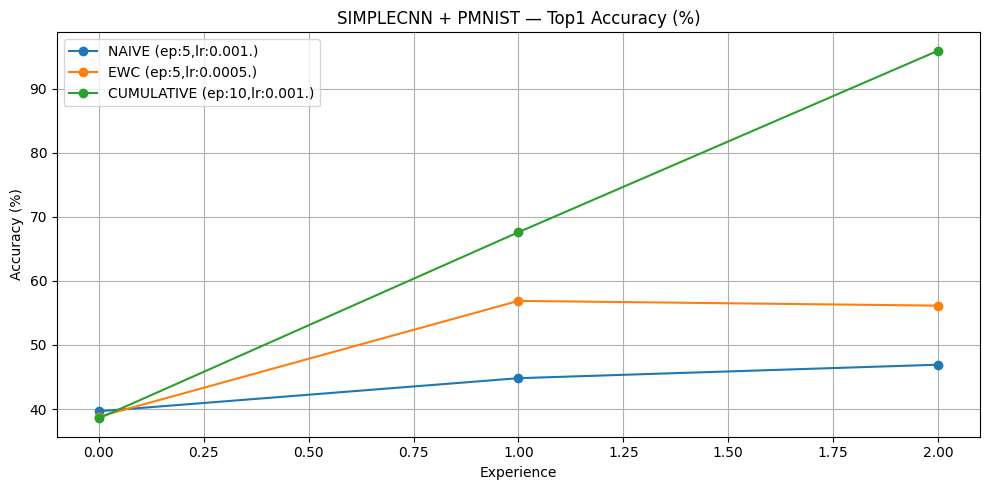

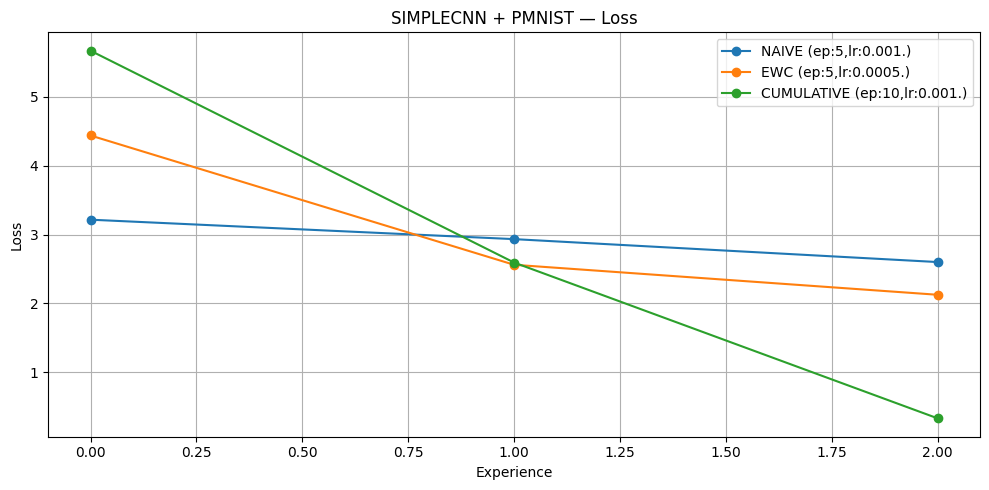

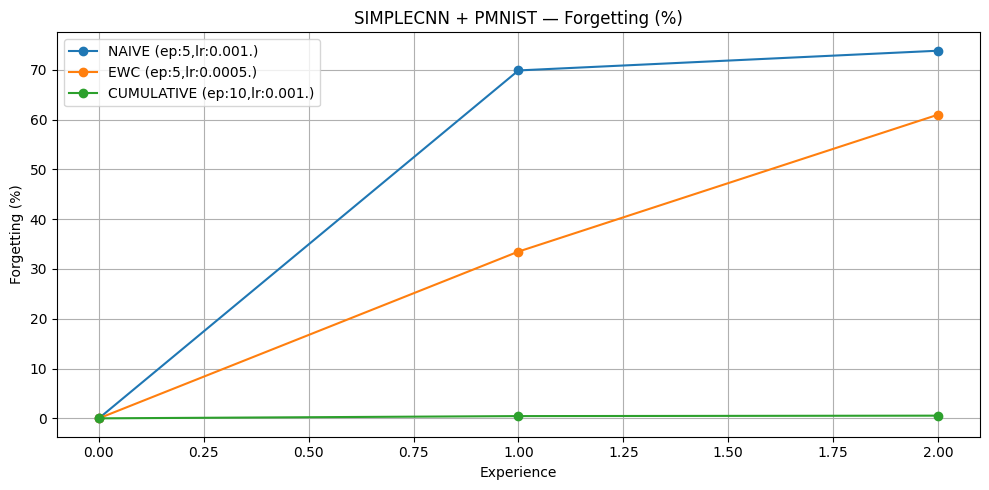


 Средние метрики для SIMPLECNN + PMNIST:
| Strategy   | Params          |   Stream Acc (%) |   Mean Exp Acc (%) |   Mean Loss |   Mean Forgetting (%) |
|------------|-----------------|------------------|--------------------|-------------|-----------------------|
| NAIVE      | ep:5,lr:0.001.  |            46.92 |              43.8  |      2.9179 |                 60.2  |
| EWC        | ep:5,lr:0.0005. |            56.14 |              50.61 |      3.043  |                 41.66 |
| CUMULATIVE | ep:10,lr:0.001. |            95.91 |              67.35 |      2.866  |                  0.42 |


In [233]:
for model, dataset in pairs:
    plot_best_curves_for_pair(base_dir, model, dataset, strategies)

In [234]:
def print_best_results(base_dir):
    best_results = {}

    for root, _, files in os.walk(base_dir):
        for file in files:
            if file.startswith('results_') and file.endswith('.json'):
                filepath = os.path.join(root, file)
                try:
                    with open(filepath, 'r') as f:
                        data = json.load(f)

                    model_dataset = os.path.basename(root)
                    strategy = file.split('_')[1]
                    ep_match = re.search(r'_ep(\d+)', file)
                    lr_match = re.search(r'_lr([\d.]+)', file)
                    epochs = ep_match.group(1) if ep_match else '?'
                    lr = lr_match.group(1) if lr_match else '?'

                    stream_accs = [d[k] for d in data for k in d if "Top1_Acc_Stream" in k]
                    stream_acc = stream_accs[-1] if stream_accs else 0
                    exp_accs = [v for d in data for k,v in d.items() if "Top1_Acc_Exp" in k]
                    mean_exp_acc = sum(exp_accs)/len(exp_accs) if exp_accs else 0
                    losses = [v for d in data for k,v in d.items() if "Loss_Exp" in k]
                    mean_loss = sum(losses)/len(losses) if losses else float('nan')
                    forgets = [v for d in data for k,v in d.items() if "Forgetting" in k]
                    mean_forget = sum(forgets)/len(forgets) if forgets else float('nan')

                    key = (model_dataset, strategy)
                    if key not in best_results or stream_acc > best_results[key]['stream_acc']:
                        best_results[key] = {
                            'file': file,
                            'epochs': epochs,
                            'lr': lr,
                            'stream_acc': stream_acc,
                            'mean_exp_acc': mean_exp_acc,
                            'mean_loss': mean_loss,
                            'mean_forget': mean_forget
                        }

                except Exception as e:
                    print(f" Ошибка при обработке {filepath}: {e}")
                    continue

    grouped = {}
    for (model_dataset, strategy), res in best_results.items():
        grouped.setdefault(model_dataset, []).append({
            "Strategy": strategy.upper(),
            "File": res["file"],
            "Epochs": res["epochs"],
            "LR": res["lr"],
            "StreamAcc (%)": f"{res['stream_acc'] * 100:.2f}",
            "MeanExpAcc (%)": f"{res['mean_exp_acc'] * 100:.2f}",
            "MeanLoss": f"{res['mean_loss']:.4f}",
            "MeanForget (%)": f"{res['mean_forget'] * 100:.2f}"
        })

    for model_dataset, rows in grouped.items():
        print(f"\n Лучшие результаты для {model_dataset}:\n")
        print(tabulate(rows, headers="keys", tablefmt="github"))

In [235]:
print_best_results(base_dir)


 Лучшие результаты для lenet_splitcifar10:

| Strategy   | File                                |   Epochs | LR     |   StreamAcc (%) |   MeanExpAcc (%) |   MeanLoss |   MeanForget (%) |
|------------|-------------------------------------|----------|--------|-----------------|------------------|------------|------------------|
| NAIVE      | results_naive_ep10_lr0.001.json     |       10 | 0.001. |           19.06 |            17.49 |    12.83   |            79.26 |
| EWC        | results_ewc_ep5_lr0.001.json        |        5 | 0.001. |           18.89 |            18.11 |    13.1702 |            84.8  |
| CUMULATIVE | results_cumulative_ep7_lr0.001.json |        7 | 0.001. |           67.11 |            44.1  |     7.3621 |            10.39 |

 Лучшие результаты для lenet_pmnist:

| Strategy   | File                                |   Epochs | LR     |   StreamAcc (%) |   MeanExpAcc (%) |   MeanLoss |   MeanForget (%) |
|------------|-------------------------------------|----------|-

In [202]:
def inspect_all_json_metrics(base_dir):
    print(f"\n Проверка всех JSON-файлов в {base_dir}\n")

    files = sorted(glob(os.path.join(base_dir, "**", "results_*.json"), recursive=True))

    for file_path in files:
        try:
            with open(file_path) as f:
                data = json.load(f)

            rel_dir = os.path.relpath(os.path.dirname(file_path), base_dir)
            filename = os.path.basename(file_path)

            acc_stream = []
            acc_exp = []
            loss_exp = []
            forgets = []

            for d in data:
                for k, v in d.items():
                    if "Top1_Acc_Stream" in k:
                        acc_stream.append(v)
                    elif "Top1_Acc_Exp" in k:
                        acc_exp.append(v)
                    elif "Loss_Exp" in k:
                        loss_exp.append(v)
                    elif "ExperienceForgetting" in k or "StreamForgetting" in k:
                        forgets.append(v)

            print(f"\n Пара: {rel_dir} | Файл: {filename}")
            if acc_stream:
                print(f"   Top1_Acc_Stream: {', '.join(f'{v:.4f}' for v in acc_stream)}")
            if acc_exp:
                print(f"   Top1_Acc_Exp   : {', '.join(f'{v:.4f}' for v in acc_exp)}")
            if loss_exp:
                print(f"   Loss_Exp       : {', '.join(f'{v:.4f}' for v in loss_exp)}")
            if forgets:
                print(f"   Forgetting     : {', '.join(f'{v:.4f}' for v in forgets)}")

        except Exception as e:
            print(f"    Ошибка при чтении {filename}: {e}")

In [203]:
inspect_all_json_metrics(base_dir)


 Проверка всех JSON-файлов в /content/drive/MyDrive/Colab Notebooks/Task3/results


 Пара: lenet_pmnist | Файл: results_cumulative_ep10_lr0.001.json
   Top1_Acc_Stream: 0.3662, 0.6581, 0.9316
   Top1_Acc_Exp   : 0.9521, 0.0775, 0.0691, 0.9437, 0.9379, 0.0926, 0.9392, 0.9332, 0.9225
   Loss_Exp       : 0.1693, 5.7000, 6.4193, 0.2166, 0.2123, 5.3121, 0.2289, 0.2187, 0.2592
   Forgetting     : 0.0000, 0.0084, 0.0084, 0.0088, 0.0129, 0.0047

 Пара: lenet_pmnist | Файл: results_cumulative_ep5_lr0.001.json
   Top1_Acc_Stream: 0.3804, 0.6628, 0.9375
   Top1_Acc_Exp   : 0.9497, 0.0988, 0.0928, 0.9447, 0.9339, 0.1098, 0.9457, 0.9399, 0.9270
   Loss_Exp       : 0.1602, 5.4779, 4.2440, 0.1901, 0.2102, 3.9500, 0.1927, 0.2078, 0.2281
   Forgetting     : 0.0000, 0.0050, 0.0050, -0.0010, 0.0040, -0.0060

 Пара: lenet_pmnist | Файл: results_ewc_ep10_lr0.001.json
   Top1_Acc_Stream: 0.3818, 0.4055, 0.4190
   Top1_Acc_Exp   : 0.9519, 0.1091, 0.0844, 0.1549, 0.9465, 0.1150, 0.0993, 0.2167, 0.9411
   Los

# Выводы

 PermutedMNIST:

	•	n_experiences=3.
	•	Каждое experience — это перестановка пикселей (Domain-Incremental).
		Одни и те же классы(0–9), но разные перестановки пикселей

 SplitCIFAR10:

	•	 n_experiences=5.
	•	Каждое experience — два новых класса из 10 (Class-Incremental).
		Exp0: классы 0 и 1
		Exp1: 2 и 3
		и т.д. по парам - классы не повторяются!

То есть мы исследовали две разные парадигмы CL:

	Domain-Incremental (PMNIST)
	Class-Incremental (SplitCIFAR10)


## Анализ результатов

##  Итоговая таблица лучших результатов

| Model + Dataset      | Strategy   | Stream Acc (%) | Mean Exp Acc (%) | Mean Loss | Forgetting (%) |
|----------------------|------------|----------------|------------------|-----------|----------------|
| LeNet + PMNIST       | Cumulative | **93.75**      | **66.03**        | 1.6512    | **0.12**       |
|                      | EWC        | 44.77          | 41.72            | 2.8771    | 61.84          |
|                      | Naive      | 43.87          | 40.95            | 3.9045    | 65.47          |
| SimpleCNN + PMNIST   | Cumulative | **95.91**      | **67.35**        | 2.8660    | **0.42**       |
|                      | EWC        | 56.14          | 50.61            | 3.0430    | 41.66          |
|                      | Naive      | 46.92          | 43.80            | 2.9179    | 60.20          |
| LeNet + SplitCIFAR10 | Cumulative | **67.11**      | **44.10**        | 7.3621    | **10.39**      |
|                      | EWC        | 18.89          | 18.11            | 13.1702   | 84.80          |
|                      | Naive      | 19.06          | 17.49            | 12.8300   | 79.26          |



###  PermutedMNIST (DI)
- **Cumulative** доминирует: накапливает знания без забывания.
- **EWC** даёт улучшение, но уступает.
- **Naive**  сильно страдает от забывания.

###  SplitCIFAR10 (CI)
- **Cumulative** выигрывает, но хранит все данные — нечестно
- **EWC** лучше, чем Naive, но всё равно забывает.
- **Naive** почти сразу забывает старые классы.

## Стратегии

### Naive
- Обучение только на текущем опыте
- Нет защиты от забывания
- Страдает при Class-Incremental

### EWC (Elastic Weight Consolidation)
- Сохраняет важные параметры с помощью регуляризации
- Частично снижает забывание
- Формула:

$$\text{Loss}_{\text{total}} = \text{Loss}_{\text{current}} + \sum_i \frac{\lambda}{2} F_i (\theta_i - \theta_i^*)^2$$

### Cumulative
- Обучение на всём предыдущем опыте
- Лучшие метрики, но требует хранения всех данных
- «Нечестный» CL

##  Заключение

- **PermutedMNIST**: Cumulative работает лучше всех — нет конфликта между задачами
- **SplitCIFAR10**: Cumulative даёт наилучшие метрики, но требует хранения всех данных
- EWC работает разумно в условиях ограничений, но забывание всё равно присутствует
- Выбор стратегии должен соответствовать типу задачи (Domain-IL vs. Class-IL).